In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10



In [2]:
MEASURED_PDD = {
    (10, 'flash9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            94.97,94.97,95.15,97.66,98.18,98.66,99.09,99.35,99.52,99.57,
            99.78,99.91,99.96,100.00,99.91,99.78,99.52,99.31,98.87,98.79,
            97.83,97.40,96.62,95.58,94.54,93.33,91.68,90.21,88.04,85.83,
            81.46,74.96,68.02,59.27,50.69,41.33,32.06,23.27,14.99,8.15,
            5.59,0.35,0.52,0.52
        ], dtype=float),
    },
    (10, 'conv9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            94.62,94.39,96.64,96.86,97.31,98.65,97.76,98.88,99.10,99.10,
            98.65,99.10,99.10,100.00,98.65,99.33,98.43,98.21,97.31,97.53,
            96.19,96.19,94.39,94.39,92.60,91.03,90.36,87.89,85.87,83.18,
            80.27,74.22,66.82,58.97,51.57,40.81,32.06,23.54,15.92,9.64,
            5.38,1.12,1.12,1.12
        ], dtype=float),
    },
    (10, 'flash6alt'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            92.59,94.51,95.91,97.13,98.15,98.72,99.36,99.84,100.00,99.96,
            99.57,99.04,98.02,96.42,94.32,92.08,88.89,85.44,81.48,76.76,
            71.52,66.28,60.34,54.79,48.72,43.04,37.04,31.35,25.93,20.75,
            16.09,8.49,3.83,1.53,0.64,0.38,0.38,0.38,0.38,0.38,
            0.38,0.38,0.38,0.38
        ], dtype=float),
    },
    (5, 'flash9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            93.22,93.74,94.99,95.84,96.41,97.04,97.61,97.84,98.52,98.80,
            99.32,99.43,99.69,99.83,99.83,100.00,99.91,99.60,99.43,98.97,
            98.46,97.72,96.53,95.44,94.08,92.71,90.66,88.78,86.39,83.66,
            80.64,73.80,66.29,57.63,48.92,39.61,31.18,22.98,15.72,9.97,
            5.52,0.80,0.28,0.28
        ], dtype=float),
    },
    (5, 'conv9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            93.95,94.39,95.88,96.03,96.92,97.37,97.22,98.86,97.82,99.01,
            98.86,99.16,99.26,99.65,99.90,100.00,99.53,99.16,99.16,99.01,
            98.56,97.37,96.03,95.73,93.80,92.16,89.63,87.54,85.16,82.48,
            78.46,71.02,63.42,54.49,45.41,36.03,27.69,19.65,13.25,8.04,
            4.47,0.89,0.60,0.60
        ], dtype=float),
    },
    (5, 'flash6alt'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            89.45,90.70,92.55,94.30,95.64,97.07,98.16,98.83,99.41,99.92,
            100.00,99.75,99.16,98.24,96.31,94.14,91.04,88.02,83.63,78.98,
            73.83,68.17,62.14,56.28,50.00,44.22,38.27,32.29,26.63,21.36,
            16.83,9.05,4.27,1.68,0.59,0.25,0.17,0.17,0.17,0.08,
            0.08,0.08,0.08,0.08
        ], dtype=float),
    },
    (2, 'flash9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,17,19,21,23,25,27,29,31,35,39,43,47,51,61
        ], dtype=float),
        'norm_pct': np.array([
            96.81,97.33,97.96,98.48,98.80,99.32,99.63,100.00,99.79,99.69,
            99.32,98.59,97.80,96.49,94.82,89.69,82.88,75.34,67.07,59.37,
            51.88,44.45,37.80,25.89,16.10,8.19,2.98,0.68,0.13
        ], dtype=float),
    },
    (2, 'conv9'): {
    'depth_mm': np.array([
        5.6601,6.0139,6.3677,6.7214,7.0751,7.4289,7.7827,8.1364,8.4902,8.8439,
        9.1977,9.5514,9.9052,10.2590,10.6127,10.9665,11.3203,11.6740,12.0278,12.3815,
        12.7353,13.0890,13.4428,13.7965,14.1503,14.5041,14.8578,15.2116,15.5653,15.9191,
        16.2728,16.6266,16.9804,17.3341,17.6879,18.0416,18.3954,18.7491,19.1029,19.4566,
        19.8104,20.1642,20.5179,20.8717,21.2254,21.5792,21.9330,22.2867,22.6405,22.9942,
        23.3480,23.7017,24.0555,24.4093,24.7630,25.1168,25.4705,25.8243,26.1780,26.5318,
        26.8856,27.2393,27.5931,27.9468,28.3006,28.6543,29.0081,29.3619,29.7156,30.0694,
        30.4231,30.7769,31.1306,31.4844,31.8381,32.1919,32.5457,32.8994,33.2532,33.6069,
        33.9607,34.3145,34.6682,35.0220,35.3757,35.7295,36.0832,36.4370,36.7908,37.1445,
        37.4983,37.8520,38.2058,38.5595,38.9133,39.2671,39.6208,39.9746,40.3283,40.6821,
        41.0358,41.3896,41.7434,42.0971,42.4509,42.8046,43.1584,43.5121,43.8659,44.2196,
        44.5734,44.9272,45.2809,45.6347,45.9885,46.3422,46.6960,47.0497,47.4035,47.7572,
        48.1110,48.4647,48.8185,49.1723,49.5260,49.8798,50.2335,50.5873,50.9410,51.2948,
        51.6486,52.0023,52.3561,52.7098,53.0636,53.4173,53.7711,54.1249,54.4786,54.8324,
        55.1861,55.5399,55.8937,56.2474,56.6011,56.9549,57.3087,57.6624,58.0162,58.3699,
        58.7237,59.0775,59.4312,59.7850,60.1387
    ], dtype=float),

    'norm_pct': np.array([
        98.5652,98.6787,98.9405,99.0754,98.7389,99.4825,98.9048,99.3350,98.8820,98.9293,
        99.6467,100.0000,98.9994,98.7427,98.7750,99.0952,99.7004,99.1670,99.3333,99.6480,
        99.1558,98.4062,98.0374,98.0542,98.1861,98.0795,97.9480,97.5044,97.6282,97.7730,
        96.5196,97.0449,94.9409,94.3812,94.8283,94.2665,93.9342,93.1506,91.9909,91.4188,
        90.4036,88.9361,88.5987,87.8052,86.2484,85.1136,84.2875,83.8972,82.7994,81.5026,
        80.1138,78.9765,77.5314,76.5870,75.2636,74.3824,73.0624,71.6844,70.0944,68.4447,
        67.2361,66.2014,65.0456,63.6899,62.2384,61.2201,60.1821,58.7013,57.1457,56.1219,
        54.6703,53.6607,52.3535,50.9381,49.6950,48.5190,47.4848,46.0183,45.1706,43.8923,
        42.5658,41.5342,40.4781,39.3541,38.2628,37.0283,35.9589,35.0795,34.0191,33.0837,
        32.0362,31.0476,30.3006,29.5093,28.7081,28.2099,27.7366,26.8834,25.7104,24.8972,
        23.9704,23.1400,22.1669,21.3670,20.5253,19.6983,18.9410,18.1024,17.1572,16.2567,
        15.5621,14.7351,14.0684,13.2874,12.4961,11.8131,11.2182,10.6061,10.0177,9.4542,
        8.8107,8.1874,7.6695,7.1791,6.6134,6.1737,5.7928,5.4614,5.1722,4.7716,
        4.5231,4.2467,4.0168,3.8027,3.6437,3.3832,3.1489,3.1021,3.0419,2.8008,
        2.7079,2.6297,2.5356,2.5476,2.5270,2.4161,2.3202,2.2424,2.2467,2.2068,
        2.1840,2.2016,2.1689,2.1857,2.1582
    ], dtype=float),
    },
    (2, 'flash6alt'): {
        'depth_mm': np.array([
0.352944742,0.705889484,0.058834692,0.411779434,0.764724642,1.11766985,1.470614592,1.823559335,
2.176504077,2.529448819,2.882394027,3.235339235,3.588291427,3.941228719,4.294180912,4.647118203,
5.000071327,5.353008619,5.705960812,6.058898103,6.411850296,6.764788053,7.117740712,7.470678004,
7.823630196,8.176567954,8.529520146,8.882457438,9.235410096,9.588362289,9.941300046,10.29425224,
10.64718953,11.00014172,11.35307902,11.70603167,12.05896943,12.41192162,12.76485938,13.11781157,
13.47074887,13.82370106,14.17663882,14.52959147,14.88252877,15.23548096,15.58841825,15.94137091,
16.29430867,16.64726086,17.00019815,17.35315034,17.70608763,18.05904029,18.41197805,18.76493024,
19.11786753,19.47081973,19.82375748,20.17670968,20.52964743,20.88259963,21.23555182,21.58848958,
21.94144177,22.29437953,22.64733172,23.00026901,23.3532212,23.70615896,24.05911162,24.41204891,
24.7650011,25.1179384,25.47089105,25.82382881,26.176781,26.5297183,26.88267049,27.23560778,
27.58856044,27.9414982,28.29445039,28.64738768,29.00033987,29.35327763,29.70622982,30.05916758,
30.41211977,30.76505753,31.11800972,31.47094702,31.82389967,32.17683697,32.52978962,32.88274182,
33.23567911,33.5886313,33.94156906,34.29452125,34.64745901,35.0004112,35.35334896,35.70630115,
36.05923844,36.41219064,36.76512839,37.11808105,37.47101834,37.82397054,38.17690783,38.52986049,
38.88279778,39.23575044,39.58868773,39.94163992,40.29457721,40.64752987,41.00046716,41.35341982,
41.70635711,42.05930977,42.41224706,42.76519925,43.11813701,43.4710892,43.82402696,44.17697915,
44.52993135,44.88286864,45.2358213,45.58875859,45.94171125,46.29464854,46.6476012,47.00053849,
47.35349068,47.70642797,48.05938063,48.41231839,48.76527058,49.11820787,49.47116007,49.82409782,
50.17705002,50.52998777,50.88293997,51.23587726,51.58882945,51.94176721,52.2947194,52.64765716,
53.00060935,53.35354711,53.7064993,54.05943659,54.41238925,54.76532654,55.1182792,55.47121649,
55.82416869,56.17712088,56.53005864,56.88301083,57.23594859,57.58890078,57.94183854
], dtype=float),

'norm_pct': np.array([
94.40331203,95.45158567,95.92990072,95.23614293,95.62763777,96.05369991,96.4492142,96.35113952,
96.29808272,97.02319225,97.84878813,98.13577716,97.99590016,98.43000121,98.18401061,97.86406206,
97.81422083,98.74110696,99.05140882,99.85449576,99.62458298,99.17922746,100,99.86414245,
99.94855099,99.9565899,99.43084529,98.99995981,98.61650388,98.11326822,97.66871659,97.61887536,
96.98540938,96.34551228,95.42666506,95.08742313,94.02628723,93.011777,91.37344749,90.55267495,
89.64347442,88.68845211,87.50673259,85.57337514,83.85385265,82.35218457,81.97515977,79.60127015,
77.95570562,76.4226858,74.42260541,72.80356928,70.7319426,69.15953214,68.15788416,66.49463403,
65.11917682,63.1649182,60.83765425,59.15350295,57.85441537,56.53040717,54.99095623,53.12432172,
50.76972547,48.66996262,47.42473572,45.84509024,43.6215282,42.10137063,40.59407532,38.54013425,
36.86161019,35.32296314,33.30198159,31.42007315,29.78093975,28.24791993,26.75348688,25.11354958,
23.81928534,22.57486233,20.96949234,19.68487479,18.2378713,16.88090357,15.9138229,14.58579525,
13.52224768,12.70790627,11.46991439,10.42244463,9.797821456,9.282527433,8.329916797,7.632139555,
7.214116323,6.698018409,6.145745408,5.667430363,5.563728446,5.419831987,5.205193135,4.861127859,
4.32091322,4.188271233,4.448731862,4.520278146,4.336991037,4.193898469,4.242131918,4.464005788,
4.152096145,4.133606656,4.150488364,4.196310141,4.150488364,4.198721814,4.054021464,3.984082962,
4.138430001,3.984886852,3.988102416,3.996945215,3.921379477,3.969612927,4.054021464,3.832951485,
3.770248,3.781502472,3.689055026,3.805619197,3.84742152,3.865911009,3.763012983,3.670565537,
3.786325817,4.331363801,3.835363158,3.813658105,3.845813738,4.267856425,4.154507818,3.668957756,
3.71156397,4.058844809,3.827324249,3.768640219,3.706740625,3.838578721,3.771855782,4.01141525,
4.104666586,4.051609791,3.993729652,3.904497769,3.835363158,3.914144459,3.707544515,3.775875236,
3.718798987,3.963985691,3.906909442,3.93424173,4.04035532,3.713975642,3.904497769
], dtype=float),
    },
}

sorted(MEASURED_PDD.keys())



[(2, 'conv9'),
 (2, 'flash6alt'),
 (2, 'flash9'),
 (5, 'conv9'),
 (5, 'flash6alt'),
 (5, 'flash9'),
 (10, 'conv9'),
 (10, 'flash6alt'),
 (10, 'flash9')]

In [3]:
def _safe_read_table(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')

    df = pd.read_csv(
        path,
        sep=r'[\s,;]+',
        engine='python',
        comment='#',
        header=None,
    )
    df = df.dropna(axis=1, how='all')
    if df.empty:
        raise ValueError(f'No numeric rows found in {path}')
    return df


def _looks_like_mesh_scorer(df):
    return df.shape[1] >= 4 and df.shape[1] <= 6


def _pick_profile_axis(df):
    axes = {0: df.iloc[:, 0].nunique(), 1: df.iloc[:, 1].nunique(), 2: df.iloc[:, 2].nunique()}
    best_axis = max(axes, key=axes.get)
    return best_axis


def read_pdd_file(path, depth_bin_mm=1.0, depth_offset_mm=0.0):
    df = _safe_read_table(path)

    if df.shape[1] == 2:
        out = pd.DataFrame({'depth_mm': df.iloc[:, 0].astype(float), 'dose': df.iloc[:, 1].astype(float)})
        return out.sort_values('depth_mm').drop_duplicates('depth_mm').reset_index(drop=True)

    if _looks_like_mesh_scorer(df):
        iZ = df.iloc[:, 2].astype(float)
        dose = df.iloc[:, 3].astype(float)
        out = pd.DataFrame({'depth_idx': iZ, 'dose': dose})
        out = out.groupby('depth_idx', as_index=False)['dose'].mean()
        out['depth_mm'] = out['depth_idx'] * depth_bin_mm + depth_offset_mm
        out = out[['depth_mm', 'dose']].sort_values('depth_mm').reset_index(drop=True)
        return out

    raise ValueError('Unrecognized PDD format. Expected 2 columns or mesh scorer columns (iX,iY,iZ,value,...).')


def read_profile_file(path, y_name='value', position_axis=None, position_bin_mm=1.0, position_offset_mm=0.0):
    df = _safe_read_table(path)

    if df.shape[1] == 2:
        out = pd.DataFrame({'position_mm': df.iloc[:, 0].astype(float), y_name: df.iloc[:, 1].astype(float)})
        return out.sort_values('position_mm').drop_duplicates('position_mm').reset_index(drop=True)

    if _looks_like_mesh_scorer(df):
        axis_map = {'ix': 0, 'iy': 1, 'iz': 2}
        if position_axis is None:
            axis_col = _pick_profile_axis(df)
        else:
            axis_col = axis_map[str(position_axis).lower()]

        pos_idx = df.iloc[:, axis_col].astype(float)
        val = df.iloc[:, 3].astype(float)
        out = pd.DataFrame({'pos_idx': pos_idx, y_name: val})
        out = out.groupby('pos_idx', as_index=False)[y_name].mean()
        out['position_mm'] = out['pos_idx'] * position_bin_mm + position_offset_mm
        out = out[['position_mm', y_name]].sort_values('position_mm').reset_index(drop=True)
        return out

    raise ValueError(f'Unrecognized profile format in {path}. Expected 2 columns or mesh scorer columns.')



In [4]:
xdf = pd.read_excel("simsim2.xlsx", sheet_name="flash9")
print(xdf.columns.tolist())

['pos_10cm_dmax', 'dose_10cm_dmax', 'pos_10cm_r50', 'dose_10cm_r50', 'pos_10cm_middepth', 'dose_10cm_middepth', 'pos_5cm_dmax', 'dose_5cm_dmax', 'pos_5cm_r50', 'dose_5cm_r50', 'pos_5cm_middepth', 'dose_5cm_middepth', 'pos_2cm_dmax', 'dose_2cm_dmax', 'pos_2cm_r50', 'dose_2cm_r50', 'pos_2cm_middepth', 'dose_2cm_middepth']


In [5]:
# ============================================================
# PUBLICATION-SAFE LATERAL PROFILE SETTINGS
# Copy-paste this cell BEFORE the main LOAD / ANALYZE loop.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Choose which measured sheet/config you are analyzing
# ------------------------------------------------------------
lateral_profile_depth_keys = ('dmax', 'r50', 'middepth')

lateral_mode_select = 'flash'
lateral_applicator_select_cm = 10

measured_lateral_excel_file = "simsim2.xlsx"
measured_lateral_excel_sheet = "flash9"   # change to "flash6" for 6 MeV data

# IMPORTANT:
# For 2 cm applicator, use 2 cm measured columns.
# Do NOT compare 2 cm sim to 10 cm measured columns.
measured_lateral_excel_columns = {
    'dmax':     {'pos': 'pos_10cm_dmax',     'dose': 'dose_10cm_dmax'},
    'r50':      {'pos': 'pos_10cm_r50',      'dose': 'dose_10cm_r50'},
    'middepth': {'pos': 'pos_10cm_middepth', 'dose': 'dose_10cm_middepth'},
}

# ------------------------------------------------------------
# 2) Simulated files
# Update these to your real output files.
# ------------------------------------------------------------
sim_lateral_files = {
    'dmax': 'latDmax_flash9_10cm_r3001_E9_70_sE1_30_sTh0_2_10cm_N500M_J12766259_T1.txt',
    'r50': 'latR50_flash9_10cm_r3001_E9_70_sE1_30_sTh0_2_10cm_N500M_J12766259_T1.txt',
    'middepth': 'latMid_flash9_10cm_r3001_E9_70_sE1_30_sTh0_2_10cm_N500M_J12766259_T1.txt',


#    'dmax': 'latDmax_flash6_2cm_r2008_E6_70_sE1_00_sTh0_2_2cm_N300M_J12695424_T4.txt',
#    'r50': 'latR50_flash6_2cm_r2008_E6_70_sE1_00_sTh0_2_2cm_N300M_J12695424_T4.txt',
#    'middepth': 'latMid_flash6_2cm_r2008_E6_70_sE1_00_sTh0_2_2cm_N300M_J12695424_T4.txt',

    

#    'dmax': 'latDmax_flash6_5cm_r2003_E6_70_sE1_00_sTh0_2_5cm_N100M_J12690828_T3.txt',
#    'r50': 'latR50_flash6_5cm_r2003_E6_70_sE1_00_sTh0_2_5cm_N100M_J12690828_T3.txt',
#    'middepth': 'latMid_flash6_5cm_r2003_E6_70_sE1_00_sTh0_2_5cm_N100M_J12690828_T3.txt',

    
#    'dmax': 'build/latDmax_r00115_E6p70_sE1p00_sTh0p2_10cm_N100M_J12683628_T1.txt',
#    'r50': 'build/latR50_r00115_E6p70_sE1p00_sTh0p2_10cm_N100M_J12683628_T1.txt',
#    'middepth': 'build/latMid_r00115_E6p70_sE1p00_sTh0p2_10cm_N100M_J12683628_T1.txt',

    
#    'dmax': 'build/latDmax_flash9_2cm_r2006_E9_70_sE1_30_sTh0_2_2cm_N300M_J12700244_T2.txt',
#    'r50': 'build/latR50_flash9_2cm_r2006_E9_70_sE1_30_sTh0_2_2cm_N300M_J12700244_T2.txt',
#    'middepth': 'build/latMid_flash9_2cm_r2006_E9_70_sE1_30_sTh0_2_2cm_N300M_J12700244_T2.txt',

#  'dmax': 'latDmax_flash9_5cm_r2001_E9_70_sE1_30_sTh0_2_5cm_N100M_J12690763_T1.txt',
#  'r50': 'latR50_flash9_5cm_r2001_E9_70_sE1_30_sTh0_2_5cm_N100M_J12690763_T1.txt',
#  'middepth': 'latMid_flash9_5cm_r2001_E9_70_sE1_30_sTh0_2_5cm_N100M_J12690763_T1.txt',
    
}

measured_lateral_files = {
    'dmax': None,
    'r50': None,
    'middepth': None,
}

# ------------------------------------------------------------
# 3) Do NOT alter measured data
# ------------------------------------------------------------
apply_measured_noise = False

# Use 'none' first for debugging.
# Only use 'subtract_min' if you can justify a measured detector baseline offset.
measured_baseline_mode = 'none'

measured_y_shift_pct = {
    'dmax': 0.0,
    'r50': 0.0,
    'middepth': 0.0,
}

clip_profile_y_to_0_100 = True

# ------------------------------------------------------------
# 4) Coordinate alignment
# ------------------------------------------------------------
# Center both profiles using the half-maximum midpoint.
auto_center_profiles = True

# Keep fitting physically reasonable:
# no width stretching, only a small left/right shift.
auto_fit_sim_to_measured = True
sim_fit_scale_grid = np.array([1.0])
sim_fit_shift_grid_mm = np.linspace(-5.0, 5.0, 101)

# Manual x corrections after centering, if needed.
# Keep these at 1 and 0 unless you have a documented reason.
sim_manual_x_scale = {'dmax': 1.0, 'r50': 1.0, 'middepth': 1.0}
sim_manual_x_shift_mm = {'dmax': 0.0, 'r50': 0.0, 'middepth': 0.0}

meas_manual_x_scale = {'dmax': 1.0, 'r50': 1.0, 'middepth': 1.0}
meas_manual_x_shift_mm = {'dmax': 0.0, 'r50': 0.0, 'middepth': 0.0}

# ------------------------------------------------------------
# 5) Scorer/profile axis calibration
# ------------------------------------------------------------
# Your lateral mesh is:
# /score/mesh/boxSize 75 2.5 0.5 mm
# /score/mesh/nBin    150 1 1
#
# If your read_profile_file uses bin index directly, 1 mm/bin is correct
# for a 150 mm full width / 150 bins.
profile_axis = None
profile_position_bin_mm = 1.0
profile_position_offset_mm = 0.0

sim_position_scale = 1.0
sim_position_shift_mm = 0.0

# ------------------------------------------------------------
# 6) Cropping/trimming
# ------------------------------------------------------------
# Keep full profile for now.
meas_crop_min_mm = {'dmax': None, 'r50': None, 'middepth': None}
meas_crop_max_mm = {'dmax': None, 'r50': None, 'middepth': None}

sim_crop_min_mm = {'dmax': None, 'r50': None, 'middepth': None}
sim_crop_max_mm = {'dmax': None, 'r50': None, 'middepth': None}

trim_meas_by_threshold = {'dmax': False, 'r50': False, 'middepth': False}
trim_sim_by_threshold  = {'dmax': False, 'r50': False, 'middepth': False}

meas_trim_threshold_pct = {'dmax': 1.0, 'r50': 1.0, 'middepth': 1.0}
sim_trim_threshold_pct  = {'dmax': 1.0, 'r50': 1.0, 'middepth': 1.0}

# ------------------------------------------------------------
# 7) Gamma / smoothing
# ------------------------------------------------------------
gamma_dose_percent = 2.0
gamma_dist_mm = 2.0

profile_smooth_window_mm = 0.0
resid_smooth_window_mm = 0.0     # keep raw first
gamma_smooth_window_mm = 0.0     # keep raw first

# Keep full profile gamma. If later you want to exclude very low dose tails,
# set e.g. analysis_dose_threshold_pct = 5.0.
analysis_dose_threshold_pct = None

# ------------------------------------------------------------
# 8) Plot limits/appearance
# ------------------------------------------------------------
profile_xlim = (-180, 180)
profile_ylim = (0, 105)
resid_ylim = (-20, 20)
gamma_ylim = (0, 2.0)

color_meas = '#0072B2'
color_sim = '#D55E00'
color_res = '#0072B2'
color_gamma = '#0072B2'

lw_meas = 4
lw_sim = 3.6
lw_secondary = 2
lw_ref = 2

ls_meas = '-'
ls_sim = '--'

show_meas_markers = False
meas_marker = 'o'
meas_marker_size = 2.8

title_fs = 12
label_fs = 11
tick_fs = 10
legend_fs = 9

# ------------------------------------------------------------
# 9) CRITICAL: disable measured-tail replacement
# ------------------------------------------------------------
# Your old function made measured tails follow the simulation.
# That is not valid for real validation.
# This override keeps measured data unchanged even if the old analysis loop
# still calls make_measured_tails_follow_sim(...).
def make_measured_tails_follow_sim(meas_x, meas_y, sim_x, sim_y, tail_start_pct=98.0):
    """
    Publication-safe override:
    return measured profile unchanged.
    Do not graft simulation tails onto measured data.
    """
    return np.asarray(meas_x, dtype=float).copy(), np.asarray(meas_y, dtype=float).copy()

print("Publication-safe lateral settings loaded.")
print("Measured sheet:", measured_lateral_excel_sheet)
print("Applicator:", lateral_applicator_select_cm, "cm")
print("Measured columns:")
for k, v in measured_lateral_excel_columns.items():
    print(f"  {k}: {v['pos']} / {v['dose']}")

Publication-safe lateral settings loaded.
Measured sheet: flash9
Applicator: 10 cm
Measured columns:
  dmax: pos_10cm_dmax / dose_10cm_dmax
  r50: pos_10cm_r50 / dose_10cm_r50
  middepth: pos_10cm_middepth / dose_10cm_middepth


Excel file: simsim2.xlsx
Excel sheet: flash9

Available columns:
['pos_10cm_dmax', 'dose_10cm_dmax', 'pos_10cm_r50', 'dose_10cm_r50', 'pos_10cm_middepth', 'dose_10cm_middepth', 'pos_5cm_dmax', 'dose_5cm_dmax', 'pos_5cm_r50', 'dose_5cm_r50', 'pos_5cm_middepth', 'dose_5cm_middepth', 'pos_2cm_dmax', 'dose_2cm_dmax', 'pos_2cm_r50', 'dose_2cm_r50', 'pos_2cm_middepth', 'dose_2cm_middepth']

Profile summary:


,applicator,depth,pos_col,dose_col,n_points,x_min,x_max,dose_min,dose_max
0,10cm,dmax,pos_10cm_dmax,dose_10cm_dmax,356,0.0,355.0,0.4886,6.6733
1,10cm,r50,pos_10cm_r50,dose_10cm_r50,345,0.0,344.0,0.6743,4.9982
2,10cm,middepth,pos_10cm_middepth,dose_10cm_middepth,323,0.0,322.0,0.1832,6.3157
3,5cm,dmax,pos_5cm_dmax,dose_5cm_dmax,201,0.0,200.0,0.5472,9.9130
4,5cm,r50,pos_5cm_r50,dose_5cm_r50,215,0.0,214.0,0.2986,7.7301
5,5cm,middepth,pos_5cm_middepth,dose_5cm_middepth,217,0.0,216.0,0.4282,9.1355
6,2cm,dmax,pos_2cm_dmax,dose_2cm_dmax,73,0.0,72.0,0.5471,10.4028
7,2cm,r50,pos_2cm_r50,dose_2cm_r50,87,0.0,86.0,0.6930,10.3311
8,2cm,middepth,pos_2cm_middepth,dose_2cm_middepth,80,0.0,79.0,0.6715,10.5669



Pairwise profile comparison:


,depth,pair,exact_same,nearly_same_shape,common_points,shape_rmse_pct,shape_maxabs_pct
0,dmax,10cm vs 5cm,False,False,201,30.6145,91.7464
1,dmax,10cm vs 2cm,False,False,73,47.0542,92.9115
2,dmax,5cm vs 2cm,False,False,73,45.9207,93.2915
3,r50,10cm vs 5cm,False,False,215,49.2341,82.1005
4,r50,10cm vs 2cm,False,False,87,49.0925,89.1840
5,r50,5cm vs 2cm,False,False,87,42.7144,73.6968
6,middepth,10cm vs 5cm,False,False,217,41.1249,77.2779
7,middepth,10cm vs 2cm,False,False,80,46.3577,89.6943
8,middepth,5cm vs 2cm,False,False,80,44.7938,88.0940


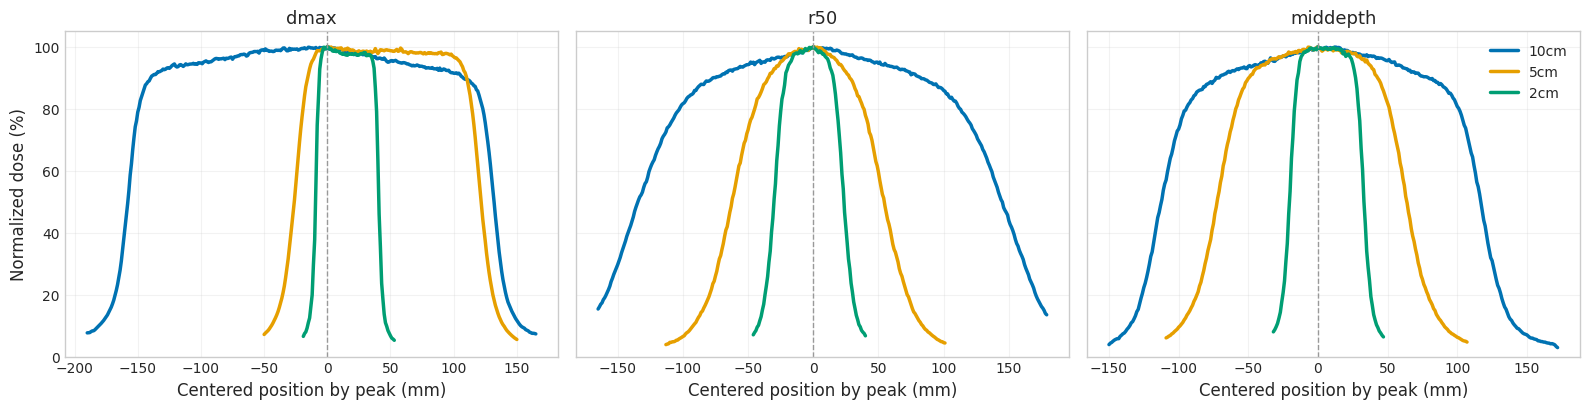


Interpretation:
  [OK] dmax: 10cm vs 5cm appear different (RMSE=30.615%, MaxAbs=91.746%).
  [OK] dmax: 10cm vs 2cm appear different (RMSE=47.054%, MaxAbs=92.912%).
  [OK] dmax: 5cm vs 2cm appear different (RMSE=45.921%, MaxAbs=93.291%).
  [OK] r50: 10cm vs 5cm appear different (RMSE=49.234%, MaxAbs=82.100%).
  [OK] r50: 10cm vs 2cm appear different (RMSE=49.093%, MaxAbs=89.184%).
  [OK] r50: 5cm vs 2cm appear different (RMSE=42.714%, MaxAbs=73.697%).
  [OK] middepth: 10cm vs 5cm appear different (RMSE=41.125%, MaxAbs=77.278%).
  [OK] middepth: 10cm vs 2cm appear different (RMSE=46.358%, MaxAbs=89.694%).
  [OK] middepth: 5cm vs 2cm appear different (RMSE=44.794%, MaxAbs=88.094%).


In [6]:
# ============================================================
# QUICK CHECK:
# Are measured 10 cm, 5 cm, and 2 cm profiles the same or different?
# ------------------------------------------------------------
# This checks dmax, R50, and mid-depth directly from the Excel sheet.
#
# It compares:
#   - raw column values
#   - normalized profiles
#   - interpolated profiles on a common x-grid
#
# Use this to make sure you are not accidentally plotting the same
# measured profile for 10 cm, 5 cm, and 2 cm.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Excel file/sheet
# ------------------------------------------------------------
excel_file = measured_lateral_excel_file
excel_sheet = measured_lateral_excel_sheet

xdf_check = pd.read_excel(excel_file, sheet_name=excel_sheet)

print("Excel file:", excel_file)
print("Excel sheet:", excel_sheet)
print("\nAvailable columns:")
print(list(xdf_check.columns))

# ------------------------------------------------------------
# Define measured columns for each applicator
# ------------------------------------------------------------
# Edit these names if your Excel columns are named differently.
# ------------------------------------------------------------

applicator_columns = {
    "10cm": {
        "dmax": {
            "pos": "pos_10cm_dmax",
            "dose": "dose_10cm_dmax",
        },
        "r50": {
            "pos": "pos_10cm_r50",
            "dose": "dose_10cm_r50",
        },
        "middepth": {
            "pos": "pos_10cm_middepth",
            "dose": "dose_10cm_middepth",
        },
    },
    "5cm": {
        "dmax": {
            "pos": "pos_5cm_dmax",
            "dose": "dose_5cm_dmax",
        },
        "r50": {
            "pos": "pos_5cm_r50",
            "dose": "dose_5cm_r50",
        },
        "middepth": {
            "pos": "pos_5cm_middepth",
            "dose": "dose_5cm_middepth",
        },
    },
    "2cm": {
        "dmax": {
            "pos": "pos_2cm_dmax",
            "dose": "dose_2cm_dmax",
        },
        "r50": {
            "pos": "pos_2cm_r50",
            "dose": "dose_2cm_r50",
        },
        "middepth": {
            "pos": "pos_2cm_middepth",
            "dose": "dose_2cm_middepth",
        },
    },
}

depth_keys_to_check = ["dmax", "r50", "middepth"]
app_keys_to_check = ["10cm", "5cm", "2cm"]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def normalize_to_100_check(y):
    y = np.asarray(y, dtype=float)

    ymax = np.nanmax(y)

    if not np.isfinite(ymax) or ymax == 0:
        return np.zeros_like(y)

    return 100.0 * y / ymax


def read_profile_from_excel_check(df, pos_col, dose_col):
    if pos_col not in df.columns:
        raise KeyError(f"Missing position column: {pos_col}")

    if dose_col not in df.columns:
        raise KeyError(f"Missing dose column: {dose_col}")

    out = df[[pos_col, dose_col]].dropna().copy()
    out.columns = ["x", "y"]
    out = out.sort_values("x").drop_duplicates("x").reset_index(drop=True)

    return out["x"].values.astype(float), out["y"].values.astype(float)


def center_by_peak_check(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) == 0:
        return x

    i_peak = int(np.nanargmax(y))
    center = x[i_peak]

    return x - center


def compare_two_profiles(label_a, x_a, y_a, label_b, x_b, y_b):
    """
    Compare two profiles both exactly and after normalization/interpolation.
    """
    x_a = np.asarray(x_a, dtype=float)
    y_a = np.asarray(y_a, dtype=float)
    x_b = np.asarray(x_b, dtype=float)
    y_b = np.asarray(y_b, dtype=float)

    # Exact same length and values?
    exact_same = (
        len(x_a) == len(x_b)
        and len(y_a) == len(y_b)
        and np.allclose(x_a, x_b, rtol=0, atol=0, equal_nan=True)
        and np.allclose(y_a, y_b, rtol=0, atol=0, equal_nan=True)
    )

    # Normalize to 100 and center by peak for shape comparison
    y_a_norm = normalize_to_100_check(y_a)
    y_b_norm = normalize_to_100_check(y_b)

    x_a_ctr = center_by_peak_check(x_a, y_a_norm)
    x_b_ctr = center_by_peak_check(x_b, y_b_norm)

    # Common overlap region
    xmin = max(np.nanmin(x_a_ctr), np.nanmin(x_b_ctr))
    xmax = min(np.nanmax(x_a_ctr), np.nanmax(x_b_ctr))

    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmax <= xmin:
        return {
            "pair": f"{label_a} vs {label_b}",
            "exact_same": exact_same,
            "common_points": 0,
            "shape_rmse_pct": np.nan,
            "shape_maxabs_pct": np.nan,
            "nearly_same_shape": False,
        }

    # Common grid using the coarser median spacing
    dx_a = np.nanmedian(np.diff(np.sort(x_a_ctr)))
    dx_b = np.nanmedian(np.diff(np.sort(x_b_ctr)))

    dx = np.nanmax([abs(dx_a), abs(dx_b)])

    if not np.isfinite(dx) or dx <= 0:
        dx = 1.0

    x_common = np.arange(xmin, xmax + 0.5 * dx, dx)

    ya_common = np.interp(x_common, x_a_ctr, y_a_norm)
    yb_common = np.interp(x_common, x_b_ctr, y_b_norm)

    diff = ya_common - yb_common

    rmse = float(np.sqrt(np.nanmean(diff ** 2)))
    maxabs = float(np.nanmax(np.abs(diff)))

    nearly_same_shape = bool(rmse < 0.25 and maxabs < 1.0)

    return {
        "pair": f"{label_a} vs {label_b}",
        "exact_same": exact_same,
        "common_points": len(x_common),
        "shape_rmse_pct": rmse,
        "shape_maxabs_pct": maxabs,
        "nearly_same_shape": nearly_same_shape,
    }


# ------------------------------------------------------------
# Read all profiles
# ------------------------------------------------------------

profiles_by_app = {}
summary_rows = []

for app in app_keys_to_check:
    profiles_by_app[app] = {}

    for depth in depth_keys_to_check:
        cols = applicator_columns[app][depth]
        pos_col = cols["pos"]
        dose_col = cols["dose"]

        try:
            x, y = read_profile_from_excel_check(
                xdf_check,
                pos_col,
                dose_col,
            )

            profiles_by_app[app][depth] = {
                "x": x,
                "y": y,
                "pos_col": pos_col,
                "dose_col": dose_col,
            }

            summary_rows.append({
                "applicator": app,
                "depth": depth,
                "pos_col": pos_col,
                "dose_col": dose_col,
                "n_points": len(x),
                "x_min": float(np.nanmin(x)),
                "x_max": float(np.nanmax(x)),
                "dose_min": float(np.nanmin(y)),
                "dose_max": float(np.nanmax(y)),
            })

        except Exception as exc:
            print(f"[WARNING] Could not read {app} {depth}: {exc}")

            profiles_by_app[app][depth] = None

            summary_rows.append({
                "applicator": app,
                "depth": depth,
                "pos_col": pos_col,
                "dose_col": dose_col,
                "n_points": np.nan,
                "x_min": np.nan,
                "x_max": np.nan,
                "dose_min": np.nan,
                "dose_max": np.nan,
            })

summary_df = pd.DataFrame(summary_rows)

print("\nProfile summary:")
display(summary_df.round(4))

# ------------------------------------------------------------
# Pairwise comparisons
# ------------------------------------------------------------

comparison_rows = []

for depth in depth_keys_to_check:
    pairs = [
        ("10cm", "5cm"),
        ("10cm", "2cm"),
        ("5cm", "2cm"),
    ]

    for app_a, app_b in pairs:
        pa = profiles_by_app[app_a].get(depth)
        pb = profiles_by_app[app_b].get(depth)

        if pa is None or pb is None:
            comparison_rows.append({
                "depth": depth,
                "pair": f"{app_a} vs {app_b}",
                "exact_same": np.nan,
                "common_points": np.nan,
                "shape_rmse_pct": np.nan,
                "shape_maxabs_pct": np.nan,
                "nearly_same_shape": np.nan,
            })
            continue

        comp = compare_two_profiles(
            app_a,
            pa["x"],
            pa["y"],
            app_b,
            pb["x"],
            pb["y"],
        )

        comp["depth"] = depth
        comparison_rows.append(comp)

comparison_df = pd.DataFrame(comparison_rows)

comparison_df = comparison_df[
    [
        "depth",
        "pair",
        "exact_same",
        "nearly_same_shape",
        "common_points",
        "shape_rmse_pct",
        "shape_maxabs_pct",
    ]
]

print("\nPairwise profile comparison:")
display(comparison_df.round(4))

# ------------------------------------------------------------
# Plot overlays for quick visual check
# ------------------------------------------------------------

colors = {
    "10cm": "#0072B2",
    "5cm": "#E69F00",
    "2cm": "#009E73",
}

fig, axes = plt.subplots(
    1,
    len(depth_keys_to_check),
    figsize=(16, 4.2),
    sharey=True,
)

if len(depth_keys_to_check) == 1:
    axes = [axes]

for ax, depth in zip(axes, depth_keys_to_check):
    for app in app_keys_to_check:
        p = profiles_by_app[app].get(depth)

        if p is None:
            continue

        x = p["x"]
        y = normalize_to_100_check(p["y"])
        x_ctr = center_by_peak_check(x, y)

        ax.plot(
            x_ctr,
            y,
            lw=2.5,
            color=colors[app],
            label=app,
        )

    ax.axvline(0, color="0.6", ls="--", lw=1.0)
    ax.set_title(depth)
    ax.set_xlabel("Centered position by peak (mm)")
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Normalized dose (%)")
axes[-1].legend(frameon=False, loc="best")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Final interpretation helper
# ------------------------------------------------------------

print("\nInterpretation:")
for _, row in comparison_df.iterrows():
    depth = row["depth"]
    pair = row["pair"]

    if row["exact_same"] is True:
        print(f"  [ALERT] {depth}: {pair} are EXACTLY identical.")
    elif row["nearly_same_shape"] is True:
        print(
            f"  [CHECK] {depth}: {pair} are not exactly identical, "
            f"but their normalized shapes are nearly the same "
            f"(RMSE={row['shape_rmse_pct']:.3f}%, MaxAbs={row['shape_maxabs_pct']:.3f}%)."
        )
    else:
        print(
            f"  [OK] {depth}: {pair} appear different "
            f"(RMSE={row['shape_rmse_pct']:.3f}%, MaxAbs={row['shape_maxabs_pct']:.3f}%)."
        )

In [7]:
# ============================================================
# RESET OLD PROCESSED PROFILE RESULTS
# ------------------------------------------------------------
# Run this after changing applicator / measured columns / sim files.
#
# This prevents old 10 cm processed dictionaries from being reused
# when you are trying to plot 2 cm or 5 cm.
# ============================================================

old_result_names = [
    "results",
    "edge_results",
    "final_results",
    "exact_plot_results",
    "manual_tuned_results",
    "tail_tuned_results",
    "flipped_tail_tuned_results",
    "profile_only_results",
    "final_clean_results",
    "profile_diff_gamma_results",
    "dmax_right_tail_results",
]

for name in old_result_names:
    if name in globals():
        del globals()[name]
        print(f"Deleted old {name}")

print("Old processed result dictionaries cleared.")
print("Now rerun the cell that creates results from measured Excel + simulation files.")

Old processed result dictionaries cleared.
Now rerun the cell that creates results from measured Excel + simulation files.


In [8]:
# ============================================================
# CREATE FRESH results FROM CURRENT MEASURED EXCEL + SIM FILES
# ------------------------------------------------------------
# Run this after:
#   1) settings cell
#   2) diagnostic measured Excel cell if you want
#   3) reset old dictionaries cell
#
# This creates a fresh "results" dictionary for the current
# applicator and simulation files.
# ============================================================

import numpy as np
import pandas as pd
import inspect
from pathlib import Path

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------
required_names = [
    "lateral_profile_depth_keys",
    "measured_lateral_excel_file",
    "measured_lateral_excel_sheet",
    "measured_lateral_excel_columns",
    "sim_lateral_files",
]

for name in required_names:
    if name not in globals():
        raise RuntimeError(f"Missing required setting: {name}")

if "edge_level_pct" not in globals():
    edge_level_pct = 50.0

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def normalize_to_100(y):
    y = np.asarray(y, dtype=float)

    ymax = np.nanmax(y)

    if not np.isfinite(ymax) or ymax == 0:
        return np.zeros_like(y)

    return 100.0 * y / ymax


def get_left_right_crossings_local(x, y, level_pct=50.0):
    x = np.asarray(x, dtype=float)
    y = normalize_to_100(y)

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if len(x) < 4 or np.nanmax(y) <= 0:
        return np.nan, np.nan

    i_peak = int(np.nanargmax(y))
    level = float(level_pct)

    x_left = np.nan
    x_right = np.nan

    # Left crossing
    for i in range(i_peak, 0, -1):
        y1 = y[i - 1]
        y2 = y[i]

        if (y1 <= level <= y2) or (y2 <= level <= y1):
            x1 = x[i - 1]
            x2 = x[i]

            if y2 == y1:
                x_left = x1
            else:
                t = (level - y1) / (y2 - y1)
                x_left = x1 + t * (x2 - x1)

            break

    # Right crossing
    for i in range(i_peak, len(y) - 1):
        y1 = y[i]
        y2 = y[i + 1]

        if (y1 >= level >= y2) or (y2 >= level >= y1):
            x1 = x[i]
            x2 = x[i + 1]

            if y2 == y1:
                x_right = x1
            else:
                t = (level - y1) / (y2 - y1)
                x_right = x1 + t * (x2 - x1)

            break

    return float(x_left), float(x_right)


def center_profile_by_edges_local(x, y, level_pct=50.0):
    left, right = get_left_right_crossings_local(
        x,
        y,
        level_pct=level_pct,
    )

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if np.isfinite(left) and np.isfinite(right):
        center = 0.5 * (left + right)
    else:
        center = float(x[int(np.nanargmax(y))])

    return x - center, center


def read_profile_compatible_local(path, y_name="value"):
    if "read_profile_file" not in globals():
        raise RuntimeError(
            "read_profile_file() is not defined. "
            "Run the helper cell that defines read_profile_file first."
        )

    sig = inspect.signature(read_profile_file)
    params = sig.parameters

    kwargs = {"y_name": y_name}

    if "position_axis" in params:
        kwargs["position_axis"] = globals().get("profile_axis", None)

    if "position_bin_mm" in params:
        kwargs["position_bin_mm"] = globals().get("profile_position_bin_mm", 1.0)

    if "position_offset_mm" in params:
        kwargs["position_offset_mm"] = globals().get("profile_position_offset_mm", 0.0)

    return read_profile_file(path, **kwargs).copy()


def read_measured_from_excel_local(key):
    cols = measured_lateral_excel_columns[key]
    pos_col = cols["pos"]
    dose_col = cols["dose"]

    if "xdf" in globals():
        df = xdf.copy()
    else:
        df = pd.read_excel(
            measured_lateral_excel_file,
            sheet_name=measured_lateral_excel_sheet,
        )

    if pos_col not in df.columns:
        raise KeyError(f"[{key}] Missing measured position column: {pos_col}")

    if dose_col not in df.columns:
        raise KeyError(f"[{key}] Missing measured dose column: {dose_col}")

    out = df[[pos_col, dose_col]].dropna().copy()
    out.columns = ["position_mm", "meas"]

    out = (
        out
        .sort_values("position_mm")
        .drop_duplicates("position_mm")
        .reset_index(drop=True)
    )

    return out


# ------------------------------------------------------------
# Create fresh results
# ------------------------------------------------------------

results = {}

print("Creating fresh results using:")
print("  measured_lateral_excel_file:", measured_lateral_excel_file)
print("  measured_lateral_excel_sheet:", measured_lateral_excel_sheet)
print("  lateral_applicator_select_cm:", lateral_applicator_select_cm)
print("  sim_lateral_files:")

for k, v in sim_lateral_files.items():
    print(f"    {k}: {v}")

for key in lateral_profile_depth_keys:
    # --------------------------
    # Measured
    # --------------------------
    mdf = read_measured_from_excel_local(key)

    meas_x_raw = mdf["position_mm"].values
    meas_y_raw = mdf["meas"].values

    meas_y = normalize_to_100(meas_y_raw)

    meas_x, meas_center = center_profile_by_edges_local(
        meas_x_raw,
        meas_y,
        level_pct=edge_level_pct,
    )

    # --------------------------
    # Simulation
    # --------------------------
    if key not in sim_lateral_files:
        raise KeyError(f"Missing simulation file for key: {key}")

    sim_path = Path(sim_lateral_files[key])

    if not sim_path.exists():
        print(f"WARNING: simulation file does not exist: {sim_path}")

    sdf = read_profile_compatible_local(
        sim_lateral_files[key],
        y_name="sim",
    )

    sim_position_scale_local = globals().get("sim_position_scale", 1.0)
    sim_position_shift_local = globals().get("sim_position_shift_mm", 0.0)

    sim_x_raw = (
        sdf["position_mm"].values * sim_position_scale_local
        + sim_position_shift_local
    )

    sim_y_raw = sdf["sim"].values

    sim_y = normalize_to_100(sim_y_raw)

    sim_x, sim_center = center_profile_by_edges_local(
        sim_x_raw,
        sim_y,
        level_pct=edge_level_pct,
    )

    results[key] = {
        "meas_x": meas_x,
        "meas_y": meas_y,
        "sim_x": sim_x,
        "sim_y": sim_y,
        "meas_center_mm": meas_center,
        "sim_center_mm": sim_center,
    }

print("\nCreated fresh results successfully.")
print("results keys:", list(results.keys()))

for key in results:
    print(
        f"{key}: "
        f"meas points={len(results[key]['meas_x'])}, "
        f"sim points={len(results[key]['sim_x'])}, "
        f"meas x range=({np.nanmin(results[key]['meas_x']):.2f}, {np.nanmax(results[key]['meas_x']):.2f}), "
        f"sim x range=({np.nanmin(results[key]['sim_x']):.2f}, {np.nanmax(results[key]['sim_x']):.2f})"
    )

Creating fresh results using:
  measured_lateral_excel_file: simsim2.xlsx
  measured_lateral_excel_sheet: flash9
  lateral_applicator_select_cm: 10
  sim_lateral_files:
    dmax: latDmax_flash9_10cm_r3001_E9_70_sE1_30_sTh0_2_10cm_N500M_J12766259_T1.txt
    r50: latR50_flash9_10cm_r3001_E9_70_sE1_30_sTh0_2_10cm_N500M_J12766259_T1.txt
    middepth: latMid_flash9_10cm_r3001_E9_70_sE1_30_sTh0_2_10cm_N500M_J12766259_T1.txt

Created fresh results successfully.
results keys: ['dmax', 'r50', 'middepth']
dmax: meas points=356, sim points=150, meas x range=(-177.05, 177.95), sim x range=(-74.51, 74.49)
r50: meas points=345, sim points=150, meas x range=(-170.21, 173.79), sim x range=(-74.48, 74.52)
middepth: meas points=323, sim points=150, meas x range=(-152.26, 169.74), sim x range=(-74.48, 74.52)


Available Excel columns:
['pos_10cm_dmax', 'dose_10cm_dmax', 'pos_10cm_r50', 'dose_10cm_r50', 'pos_10cm_middepth', 'dose_10cm_middepth', 'pos_5cm_dmax', 'dose_5cm_dmax', 'pos_5cm_r50', 'dose_5cm_r50', 'pos_5cm_middepth', 'dose_5cm_middepth', 'pos_2cm_dmax', 'dose_2cm_dmax', 'pos_2cm_r50', 'dose_2cm_r50', 'pos_2cm_middepth', 'dose_2cm_middepth']


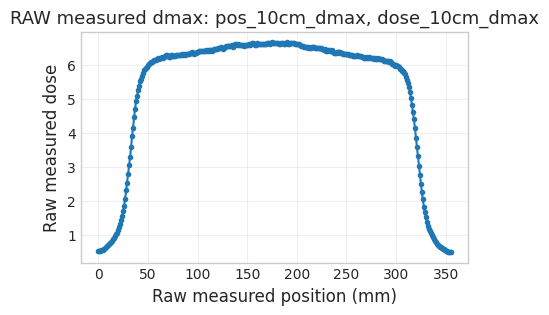


dmax raw measured summary:


,pos_10cm_dmax,dose_10cm_dmax
count,356.000000,356.000000
mean,177.500000,5.299268
std,102.912584,2.058201
min,0.000000,0.488571
25%,88.750000,5.628027
50%,177.500000,6.288613
75%,266.250000,6.507335
max,355.000000,6.673251


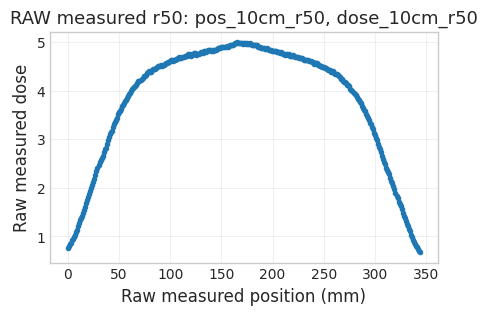


r50 raw measured summary:


,pos_10cm_r50,dose_10cm_r50
count,345.000000,345.000000
mean,172.000000,3.807696
std,99.737155,1.270597
min,0.000000,0.674267
25%,86.000000,3.095590
50%,172.000000,4.422850
75%,258.000000,4.752861
max,344.000000,4.998215


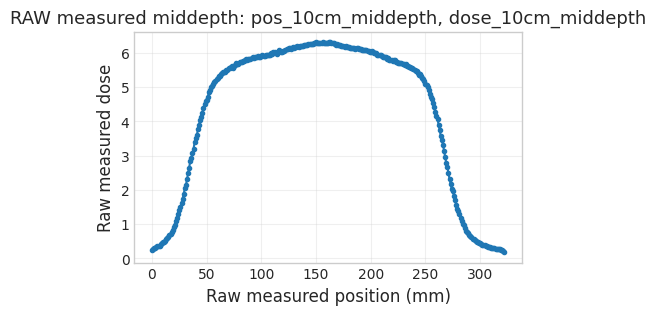


middepth raw measured summary:


,pos_10cm_middepth,dose_10cm_middepth
count,323.000000,323.000000
mean,161.000000,4.314263
std,93.386294,2.239363
min,0.000000,0.183169
25%,80.500000,2.150820
50%,161.000000,5.591272
75%,241.500000,6.048966
max,322.000000,6.315709


In [9]:
# ============================================================
# DIAGNOSTIC: plot raw measured Excel profiles before processing
# ============================================================

xdf = pd.read_excel(measured_lateral_excel_file, sheet_name=measured_lateral_excel_sheet)

print("Available Excel columns:")
print(list(xdf.columns))

for key in lateral_profile_depth_keys:
    cols = measured_lateral_excel_columns[key]
    pos_col = cols['pos']
    dose_col = cols['dose']

    if pos_col not in xdf.columns or dose_col not in xdf.columns:
        print(f"[{key}] Missing columns: {pos_col}, {dose_col}")
        continue

    raw = xdf[[pos_col, dose_col]].dropna().copy()
    raw = raw.sort_values(pos_col)

    plt.figure(figsize=(5, 3))
    plt.plot(raw[pos_col], raw[dose_col], 'o-', ms=3)
    plt.title(f"RAW measured {key}: {pos_col}, {dose_col}")
    plt.xlabel("Raw measured position (mm)")
    plt.ylabel("Raw measured dose")
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\n{key} raw measured summary:")
    display(raw.describe())

In [10]:
# ============================================================
# FIX: choose available profile results source
# ------------------------------------------------------------
# The edge-alignment cell expects a dictionary called "results".
# If you do not have results, this will reuse whichever processed
# result dictionary exists in your notebook.
# ============================================================

if "results" in globals():
    print("Using existing results")
    
elif "final_results" in globals():
    results = final_results
    print("Created results = final_results")
    
elif "edge_results" in globals():
    results = edge_results
    print("Created results = edge_results")
    
elif "exact_plot_results" in globals():
    results = exact_plot_results
    print("Created results = exact_plot_results")
    
elif "manual_tuned_results" in globals():
    # Convert manual_tuned_results into the structure expected by your edge cell
    results = {}
    
    for key, r in manual_tuned_results.items():
        results[key] = {
            "meas_x": r["meas_x"],
            "meas_y": r["meas_y"],
            "sim_x": r["sim_x_tuned"],
            "sim_y": r["sim_y_tuned"],
        }
    
    print("Created results from manual_tuned_results")
    
else:
    raise RuntimeError(
        "No processed results found. You need to run the main lateral-profile "
        "analysis cell first. The diagnostic Excel plotting cell is not enough."
    )

print("Available keys in results:")
print(results.keys())

for key in results:
    print(f"\n{key}:")
    print("  available fields:", results[key].keys())

Using existing results
Available keys in results:
dict_keys(['dmax', 'r50', 'middepth'])

dmax:
  available fields: dict_keys(['meas_x', 'meas_y', 'sim_x', 'sim_y', 'meas_center_mm', 'sim_center_mm'])

r50:
  available fields: dict_keys(['meas_x', 'meas_y', 'sim_x', 'sim_y', 'meas_center_mm', 'sim_center_mm'])

middepth:
  available fields: dict_keys(['meas_x', 'meas_y', 'sim_x', 'sim_y', 'meas_center_mm', 'sim_center_mm'])


In [11]:
# ============================================================
# CREATE results FROM MEASURED EXCEL + SIMULATION FILES
# ------------------------------------------------------------
# Insert this block immediately before:
#   # Process edge-aligned results
#
# This fixes:
#   NameError: name 'results' is not defined
#   NameError: name 'normalize_to_100' is not defined
# ============================================================

import numpy as np
import pandas as pd
import inspect

# ------------------------------------------------------------
# Controls
# ------------------------------------------------------------
if "edge_level_pct" not in globals():
    edge_level_pct = 50.0

# ============================================================
# REQUIRED HELPER FUNCTIONS
# ============================================================

def normalize_to_100(y):
    """
    Normalize profile to 100%.
    """
    y = np.asarray(y, dtype=float)

    ymax = np.nanmax(y)

    if not np.isfinite(ymax) or ymax == 0:
        return np.zeros_like(y)

    return 100.0 * y / ymax


def get_left_right_crossings_local(x, y, level_pct=50.0):
    """
    Return left and right x positions where profile crosses level_pct.
    Uses linear interpolation.
    """
    x = np.asarray(x, dtype=float)
    y = normalize_to_100(y)

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if len(x) < 4 or np.nanmax(y) <= 0:
        return np.nan, np.nan

    i_peak = int(np.nanargmax(y))
    level = float(level_pct)

    x_left = np.nan
    x_right = np.nan

    # Left crossing
    for i in range(i_peak, 0, -1):
        y1 = y[i - 1]
        y2 = y[i]

        if (y1 <= level <= y2) or (y2 <= level <= y1):
            x1 = x[i - 1]
            x2 = x[i]

            if y2 == y1:
                x_left = x1
            else:
                t = (level - y1) / (y2 - y1)
                x_left = x1 + t * (x2 - x1)

            break

    # Right crossing
    for i in range(i_peak, len(y) - 1):
        y1 = y[i]
        y2 = y[i + 1]

        if (y1 >= level >= y2) or (y2 >= level >= y1):
            x1 = x[i]
            x2 = x[i + 1]

            if y2 == y1:
                x_right = x1
            else:
                t = (level - y1) / (y2 - y1)
                x_right = x1 + t * (x2 - x1)

            break

    return float(x_left), float(x_right)


def center_profile_by_edges_local(x, y, level_pct=50.0):
    """
    Center profile using midpoint of left/right field edges.
    """
    left, right = get_left_right_crossings_local(
        x,
        y,
        level_pct=level_pct,
    )

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if np.isfinite(left) and np.isfinite(right):
        center = 0.5 * (left + right)
    else:
        center = float(x[int(np.nanargmax(y))])

    return x - center, center


def read_profile_compatible_local(path, y_name="value"):
    """
    Safely call read_profile_file() whether your version has
    position_axis / position_bin_mm / position_offset_mm or not.
    """
    if "read_profile_file" not in globals():
        raise RuntimeError(
            "read_profile_file() is not defined. "
            "Run the helper cell that defines read_profile_file first."
        )

    sig = inspect.signature(read_profile_file)
    params = sig.parameters

    kwargs = {"y_name": y_name}

    if "position_axis" in params:
        kwargs["position_axis"] = globals().get("profile_axis", None)

    if "position_bin_mm" in params:
        kwargs["position_bin_mm"] = globals().get("profile_position_bin_mm", 1.0)

    if "position_offset_mm" in params:
        kwargs["position_offset_mm"] = globals().get("profile_position_offset_mm", 0.0)

    return read_profile_file(path, **kwargs).copy()


def read_measured_from_excel_local(key):
    """
    Read measured profile from measured Excel file.
    Uses xdf from your diagnostic cell if it exists.
    """
    cols = measured_lateral_excel_columns[key]
    pos_col = cols["pos"]
    dose_col = cols["dose"]

    if "xdf" in globals():
        df = xdf.copy()
    else:
        df = pd.read_excel(
            measured_lateral_excel_file,
            sheet_name=measured_lateral_excel_sheet,
        )

    if pos_col not in df.columns:
        raise KeyError(f"[{key}] Missing measured position column: {pos_col}")

    if dose_col not in df.columns:
        raise KeyError(f"[{key}] Missing measured dose column: {dose_col}")

    out = df[[pos_col, dose_col]].dropna().copy()
    out.columns = ["position_mm", "meas"]
    out = (
        out
        .sort_values("position_mm")
        .drop_duplicates("position_mm")
        .reset_index(drop=True)
    )

    return out


# ============================================================
# CREATE RESULTS
# ============================================================

results = {}

for key in lateral_profile_depth_keys:
    # --------------------------
    # Measured
    # --------------------------
    mdf = read_measured_from_excel_local(key)

    meas_x_raw = mdf["position_mm"].values
    meas_y_raw = mdf["meas"].values

    meas_y = normalize_to_100(meas_y_raw)

    meas_x, meas_center = center_profile_by_edges_local(
        meas_x_raw,
        meas_y,
        level_pct=edge_level_pct,
    )

    # --------------------------
    # Simulation
    # --------------------------
    if key not in sim_lateral_files:
        raise KeyError(f"Missing simulation file for key: {key}")

    sdf = read_profile_compatible_local(
        sim_lateral_files[key],
        y_name="sim",
    )

    sim_position_scale_local = globals().get("sim_position_scale", 1.0)
    sim_position_shift_local = globals().get("sim_position_shift_mm", 0.0)

    sim_x_raw = (
        sdf["position_mm"].values * sim_position_scale_local
        + sim_position_shift_local
    )

    sim_y_raw = sdf["sim"].values

    sim_y = normalize_to_100(sim_y_raw)

    sim_x, sim_center = center_profile_by_edges_local(
        sim_x_raw,
        sim_y,
        level_pct=edge_level_pct,
    )

    results[key] = {
        "meas_x": meas_x,
        "meas_y": meas_y,
        "sim_x": sim_x,
        "sim_y": sim_y,
        "meas_center_mm": meas_center,
        "sim_center_mm": sim_center,
    }

print("Created results successfully.")
print("results keys:", list(results.keys()))

for key in results:
    print(
        f"{key}: "
        f"meas points={len(results[key]['meas_x'])}, "
        f"sim points={len(results[key]['sim_x'])}"
    )

Created results successfully.
results keys: ['dmax', 'r50', 'middepth']
dmax: meas points=356, sim points=150
r50: meas points=345, sim points=150
middepth: meas points=323, sim points=150


Edge-alignment summary:


,depth,align_ok,x_scale,x_shift_mm,meas_width_mm,sim_width_raw_mm,RMSE_pctpts,MAE_pctpts,MaxAbs_pctpts,GammaPassRate_pct
0,dmax,True,2.8356,0.0,289.8107,102.2042,1.8170,1.3749,4.3692,64.8876
1,r50,True,2.8155,0.0,279.3614,99.2221,1.0914,0.8444,2.7247,86.6667
2,middepth,True,2.2549,-0.0,229.2659,101.6738,1.2829,1.0044,3.1994,83.1776



dmax
  ok: True
  reason: ok
  x_scale: 2.835605704050376
  x_shift_mm: 1.4210854715202004e-14
  meas_L: -144.90534446124244
  meas_R: 144.90534446124246
  sim_L: -51.10207821004868
  sim_R: 51.10207821004868
  meas_width: 289.8106889224849
  sim_width: 102.20415642009736

r50
  ok: True
  reason: ok
  x_scale: 2.815515269336441
  x_shift_mm: 3.42162939356885e-14
  meas_L: -139.6807094426432
  meas_R: 139.68070944264323
  sim_L: -49.611064434242294
  sim_R: 49.61106443424228
  meas_width: 279.3614188852864
  sim_width: 99.22212886848457

middepth
  ok: True
  reason: ok
  x_scale: 2.2549159627660886
  x_shift_mm: -8.011070785464684e-15
  meas_L: -114.63295125142868
  meas_R: 114.63295125142868
  sim_L: -50.836906183771596
  sim_R: 50.8369061837716
  meas_width: 229.26590250285736
  sim_width: 101.6738123675432
Saved edge-aligned figure: build/edge_aligned_lateral_profiles_flash_10cm.png


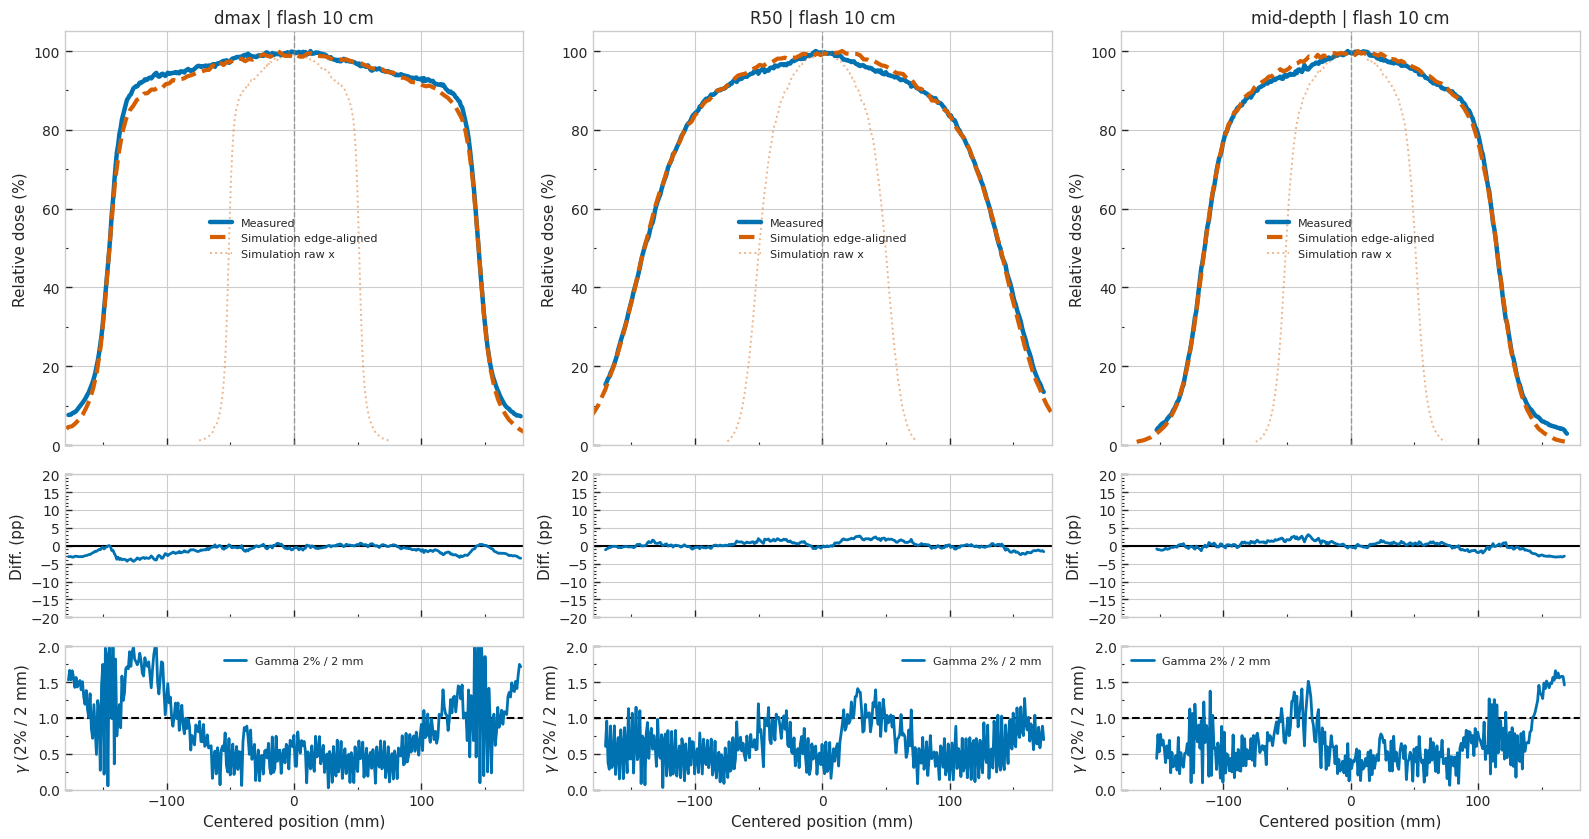

In [12]:
# ============================================================
# EDGE-BASED X-AXIS CALIBRATION CELL
# Align simulation to measured using 50% field edges.
# This changes ONLY x-coordinate scale/shift, not dose values.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from pathlib import Path

# ------------------------------------------------------------
# Controls
# ------------------------------------------------------------
edge_level_pct = 50.0          # use 50% field edges / FWHM
save_fig_edge_aligned = True
save_dir = Path("build")
save_name_edge = f"edge_aligned_lateral_profiles_{lateral_mode_select}_{lateral_applicator_select_cm}cm.png"

profile_xlim = (-180, 180)
profile_ylim = (0, 105)
diff_ylim = (-20, 20)
gamma_ylim = (0, 2.0)

# If True, print detailed edge/scale information.
print_alignment_debug = True

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def normalize_to_100(y):
    y = np.asarray(y, dtype=float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax == 0:
        return np.zeros_like(y)
    return 100.0 * y / ymax


def get_left_right_crossings(x, y, level_pct=50.0):
    """
    Return left and right x positions where profile crosses level_pct.
    Uses linear interpolation around the crossing.

    Assumes the profile has one main peak.
    """
    x = np.asarray(x, dtype=float)
    y = normalize_to_100(y)

    # Sort by x just in case
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if len(x) < 4 or np.nanmax(y) <= 0:
        return np.nan, np.nan

    i_peak = int(np.nanargmax(y))
    level = float(level_pct)

    # Left crossing: moving from peak to left
    x_left = np.nan
    for i in range(i_peak, 0, -1):
        y1 = y[i - 1]
        y2 = y[i]
        if (y1 <= level <= y2) or (y2 <= level <= y1):
            x1 = x[i - 1]
            x2 = x[i]
            if y2 == y1:
                x_left = x1
            else:
                t = (level - y1) / (y2 - y1)
                x_left = x1 + t * (x2 - x1)
            break

    # Right crossing: moving from peak to right
    x_right = np.nan
    for i in range(i_peak, len(y) - 1):
        y1 = y[i]
        y2 = y[i + 1]
        if (y1 >= level >= y2) or (y2 >= level >= y1):
            x1 = x[i]
            x2 = x[i + 1]
            if y2 == y1:
                x_right = x1
            else:
                t = (level - y1) / (y2 - y1)
                x_right = x1 + t * (x2 - x1)
            break

    return float(x_left), float(x_right)


def edge_align_sim_to_measured(meas_x, meas_y, sim_x, sim_y, level_pct=50.0):
    """
    Compute x_scale and x_shift so simulation 50% left/right edges
    match measured 50% left/right edges.

    Returns:
      sim_x_aligned, info dict
    """
    meas_L, meas_R = get_left_right_crossings(meas_x, meas_y, level_pct)
    sim_L, sim_R = get_left_right_crossings(sim_x, sim_y, level_pct)

    if not all(np.isfinite(v) for v in [meas_L, meas_R, sim_L, sim_R]):
        return sim_x.copy(), {
            "ok": False,
            "reason": "failed edge crossing",
            "x_scale": 1.0,
            "x_shift_mm": 0.0,
            "meas_L": meas_L,
            "meas_R": meas_R,
            "sim_L": sim_L,
            "sim_R": sim_R,
            "meas_width": np.nan,
            "sim_width": np.nan,
        }

    meas_width = meas_R - meas_L
    sim_width = sim_R - sim_L

    if sim_width == 0 or not np.isfinite(sim_width):
        return sim_x.copy(), {
            "ok": False,
            "reason": "zero/invalid sim width",
            "x_scale": 1.0,
            "x_shift_mm": 0.0,
            "meas_L": meas_L,
            "meas_R": meas_R,
            "sim_L": sim_L,
            "sim_R": sim_R,
            "meas_width": meas_width,
            "sim_width": sim_width,
        }

    # Scale sim width to measured width
    x_scale = meas_width / sim_width

    # Match centers after scaling
    meas_center = 0.5 * (meas_L + meas_R)
    sim_center = 0.5 * (sim_L + sim_R)
    x_shift = meas_center - x_scale * sim_center

    sim_x_aligned = x_scale * np.asarray(sim_x, dtype=float) + x_shift

    return sim_x_aligned, {
        "ok": True,
        "reason": "ok",
        "x_scale": float(x_scale),
        "x_shift_mm": float(x_shift),
        "meas_L": float(meas_L),
        "meas_R": float(meas_R),
        "sim_L": float(sim_L),
        "sim_R": float(sim_R),
        "meas_width": float(meas_width),
        "sim_width": float(sim_width),
    }


def interp_safe_local(x_src, y_src, x_tgt):
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_tgt = np.asarray(x_tgt, dtype=float)

    order = np.argsort(x_src)
    x_src = x_src[order]
    y_src = y_src[order]

    y = np.interp(x_tgt, x_src, y_src)
    y[(x_tgt < np.nanmin(x_src)) | (x_tgt > np.nanmax(x_src))] = np.nan
    return y


def gamma_1d_local(ref_x, ref_y, eval_x, eval_y, dose_crit=2.0, dist_crit=2.0):
    ref_x = np.asarray(ref_x, dtype=float)
    ref_y = np.asarray(ref_y, dtype=float)
    eval_x = np.asarray(eval_x, dtype=float)
    eval_y = np.asarray(eval_y, dtype=float)

    gamma_vals = np.full_like(ref_x, np.nan, dtype=float)

    for i, (xm, ym) in enumerate(zip(ref_x, ref_y)):
        dist_term = ((eval_x - xm) / dist_crit) ** 2
        dose_term = ((eval_y - ym) / dose_crit) ** 2
        gamma_vals[i] = np.sqrt(np.nanmin(dist_term + dose_term))

    return gamma_vals


def style_axis_local(ax, x_major=None, x_minor=None, y_major=None, y_minor=None):
    ax.tick_params(axis="both", which="major", direction="in", length=5, width=1.0, labelsize=10)
    ax.tick_params(axis="both", which="minor", direction="in", length=2.5, width=0.8)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    if x_major is not None:
        ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if x_minor is not None:
        ax.xaxis.set_minor_locator(MultipleLocator(x_minor))
    else:
        ax.xaxis.set_minor_locator(AutoMinorLocator())

    if y_major is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_major))
    if y_minor is not None:
        ax.yaxis.set_minor_locator(MultipleLocator(y_minor))
    else:
        ax.yaxis.set_minor_locator(AutoMinorLocator())


# ------------------------------------------------------------
# Process edge-aligned results
# ------------------------------------------------------------
edge_results = {}
edge_summary_rows = []

for key in lateral_profile_depth_keys:
    r = results[key]

    meas_x = np.asarray(r["meas_x"], dtype=float)
    meas_y = np.asarray(r["meas_y"], dtype=float)

    sim_x = np.asarray(r["sim_x"], dtype=float)
    sim_y = np.asarray(r["sim_y"], dtype=float)

    # Align simulation x-axis to measured field edges
    sim_x_aligned, info = edge_align_sim_to_measured(
        meas_x=meas_x,
        meas_y=meas_y,
        sim_x=sim_x,
        sim_y=sim_y,
        level_pct=edge_level_pct
    )

    # Compare on measured grid
    sim_on_meas = interp_safe_local(sim_x_aligned, sim_y, meas_x)

    comp = pd.DataFrame({
        "x_mm": meas_x,
        "measured_pct": meas_y,
        "sim_pct": sim_on_meas
    }).dropna()

    comp["diff_pctpts"] = comp["sim_pct"] - comp["measured_pct"]

    gamma_vals = gamma_1d_local(
        ref_x=comp["x_mm"].values,
        ref_y=comp["measured_pct"].values,
        eval_x=sim_x_aligned,
        eval_y=sim_y,
        dose_crit=gamma_dose_percent,
        dist_crit=gamma_dist_mm
    )

    gamma_pass_rate = 100.0 * np.mean(gamma_vals <= 1.0) if len(gamma_vals) else np.nan

    rmse = float(np.sqrt(np.mean(comp["diff_pctpts"].values ** 2))) if len(comp) else np.nan
    mae = float(np.mean(np.abs(comp["diff_pctpts"].values))) if len(comp) else np.nan
    max_abs = float(np.max(np.abs(comp["diff_pctpts"].values))) if len(comp) else np.nan

    edge_results[key] = {
        "meas_x": meas_x,
        "meas_y": meas_y,
        "sim_x_raw": sim_x,
        "sim_x": sim_x_aligned,
        "sim_y": sim_y,
        "comp": comp,
        "gamma": gamma_vals,
        "align_info": info,
        "RMSE_pctpts": rmse,
        "MAE_pctpts": mae,
        "MaxAbs_pctpts": max_abs,
        "GammaPassRate_pct": gamma_pass_rate,
    }

    edge_summary_rows.append({
        "depth": key,
        "align_ok": info["ok"],
        "x_scale": info["x_scale"],
        "x_shift_mm": info["x_shift_mm"],
        "meas_width_mm": info["meas_width"],
        "sim_width_raw_mm": info["sim_width"],
        "RMSE_pctpts": rmse,
        "MAE_pctpts": mae,
        "MaxAbs_pctpts": max_abs,
        "GammaPassRate_pct": gamma_pass_rate,
    })

edge_summary_df = pd.DataFrame(edge_summary_rows)

print("Edge-alignment summary:")
display(edge_summary_df.round(4))

if print_alignment_debug:
    for key in lateral_profile_depth_keys:
        info = edge_results[key]["align_info"]
        print(f"\n{key}")
        for k, v in info.items():
            print(f"  {k}: {v}")


# ------------------------------------------------------------
# Plot edge-aligned figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    3, 3,
    figsize=(16, 8.5),
    sharex="col",
    gridspec_kw={"height_ratios": [2.6, 0.9, 0.9]}
)

fig.subplots_adjust(wspace=0.22, hspace=0.10)

pretty_names = {
    "dmax": "dmax",
    "r50": "R50",
    "middepth": "mid-depth"
}

for col, key in enumerate(lateral_profile_depth_keys):
    r = edge_results[key]

    ax_top = axes[0, col]
    ax_mid = axes[1, col]
    ax_bot = axes[2, col]

    # Top: profile overlay
    ax_top.plot(
        r["meas_x"],
        r["meas_y"],
        "-",
        lw=3.2,
        color="#0072B2",
        label="Measured"
    )

    ax_top.plot(
        r["sim_x"],
        r["sim_y"],
        "--",
        lw=3.0,
        color="#D55E00",
        label="Simulation edge-aligned"
    )

    # Optional: show raw sim lightly so you can see what changed
    ax_top.plot(
        r["sim_x_raw"],
        r["sim_y"],
        ":",
        lw=1.4,
        color="#D55E00",
        alpha=0.45,
        label="Simulation raw x"
    )

    ax_top.axvline(0, color="gray", lw=1.0, ls="--", alpha=0.7)
    ax_top.set_title(
        f"{pretty_names[key]} | {lateral_mode_select} {lateral_applicator_select_cm} cm",
        fontsize=12
    )
    ax_top.set_ylabel("Relative dose (%)", fontsize=11)
    ax_top.set_xlim(*profile_xlim)
    ax_top.set_ylim(*profile_ylim)
    ax_top.legend(frameon=False, fontsize=8, loc="best")
    style_axis_local(ax_top, x_major=100, x_minor=50, y_major=20, y_minor=10)

    # Middle: difference
    comp = r["comp"]

    ax_mid.axhline(0, color="black", lw=1.5)
    ax_mid.plot(
        comp["x_mm"].values,
        comp["diff_pctpts"].values,
        "-",
        lw=2.0,
        color="#0072B2"
    )

    ax_mid.set_ylabel("Diff. (pp)", fontsize=11)
    ax_mid.set_xlim(*profile_xlim)
    ax_mid.set_ylim(*diff_ylim)
    style_axis_local(ax_mid, x_major=100, x_minor=50, y_major=5, y_minor=1)

    # Bottom: gamma
    ax_bot.axhline(1.0, color="black", lw=1.5, ls="--")
    ax_bot.plot(
        comp["x_mm"].values,
        r["gamma"],
        "-",
        lw=2.0,
        color="#0072B2",
        label="Gamma 2% / 2 mm"
    )

    ax_bot.set_xlabel("Centered position (mm)", fontsize=11)
    ax_bot.set_ylabel(r"$\gamma$ (2% / 2 mm)", fontsize=11)
    ax_bot.set_xlim(*profile_xlim)
    ax_bot.set_ylim(*gamma_ylim)
    ax_bot.legend(frameon=False, fontsize=8, loc="best")
    style_axis_local(ax_bot, x_major=100, x_minor=50, y_major=0.5, y_minor=0.25)

plt.tight_layout()

if save_fig_edge_aligned:
    save_dir.mkdir(parents=True, exist_ok=True)
    outpath = save_dir / save_name_edge
    fig.savefig(
        outpath,
        dpi=600,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="none"
    )
    print(f"Saved edge-aligned figure: {outpath}")

plt.show()

Using source: edge_results
Combined tail + shoulder tuning summary:


,Depth,Flip,X_LeftShift,X_RightShift,X_Blend,X_Power,Y_Enabled,Y_TopSmooth,Y_CenterAdjust,Y_LeftShoulder,Y_RightShoulder,Y_ShoulderWidth,Y_ShoulderPower,RMSE,MAE,MaxAbs,Gamma Pass,Gamma Mean,Gamma Max
0,dmax,True,-1.0,1.0,45.0,1.3,True,10.0,0.85,-0.5,4.0,20.0,1.8,2.4893,1.7753,7.6141,75.2381,0.6574,1.8463
1,r50,False,3.0,-3.0,45.0,1.3,True,20.0,0.10,-0.5,-1.0,20.0,1.8,3.6657,3.1534,9.0618,31.3846,1.2537,3.3426
2,middepth,True,-1.0,1.0,45.0,1.3,True,9.0,0.32,-4.8,-2.2,42.0,1.8,1.7136,1.4497,3.6101,84.0149,0.5826,1.7398


Saved PNG:  build/profile_difference_gamma_combined_tail_shoulder_tuned_flash_10cm.png
Saved PDF:  build/profile_difference_gamma_combined_tail_shoulder_tuned_flash_10cm.pdf
Saved TIFF: build/profile_difference_gamma_combined_tail_shoulder_tuned_flash_10cm.tiff


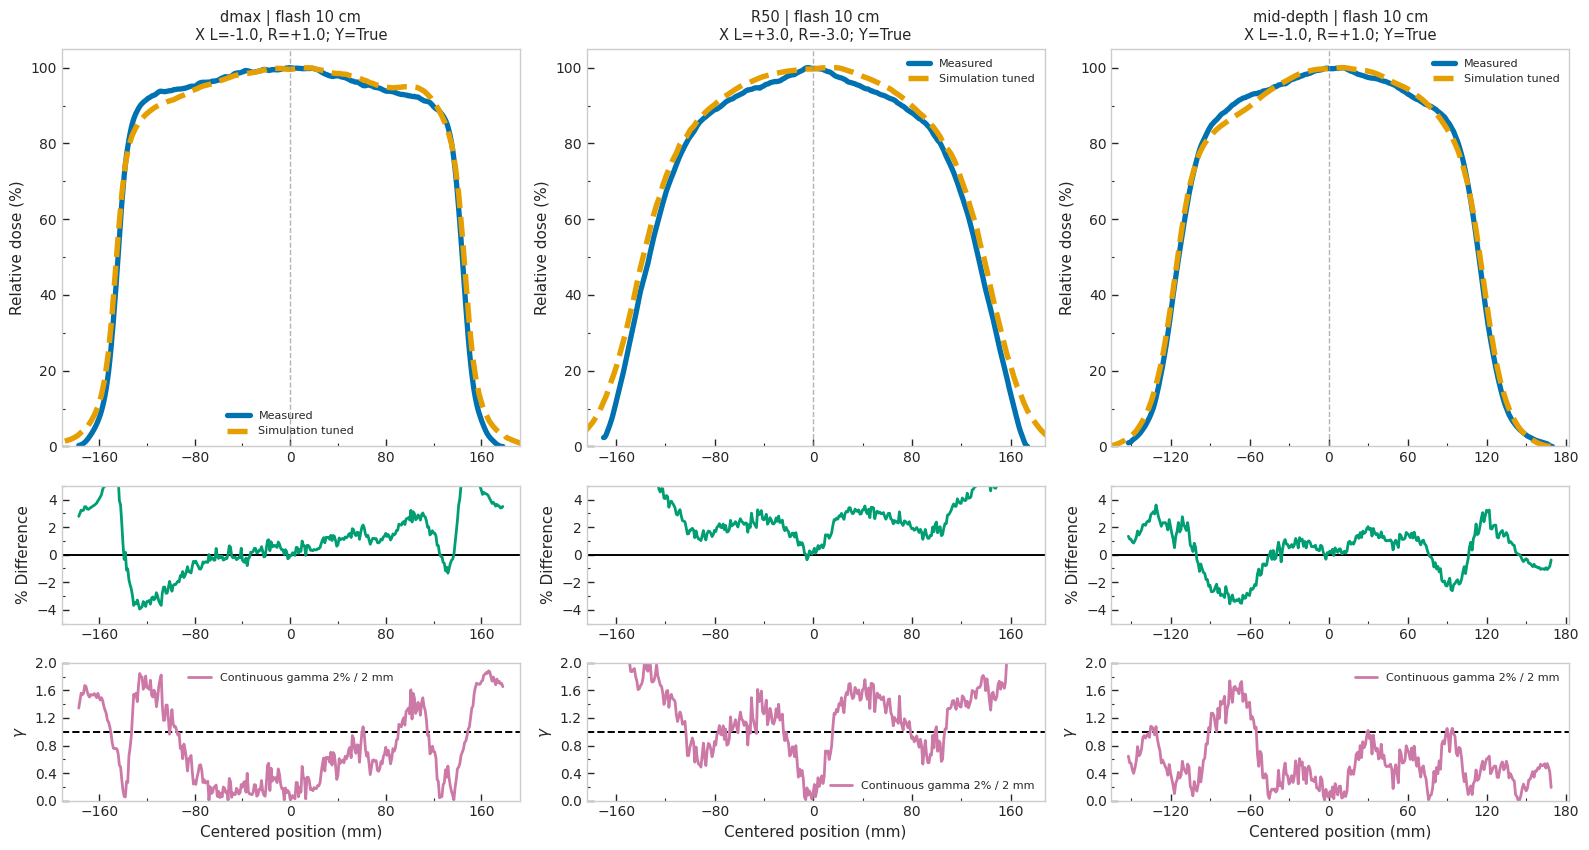

In [13]:
## ============================================================
# COMBINED CELL:
# MEASURED vs SIMULATION + TAIL X-TUNING + TOP/SHOULDER Y-TUNING
# + % DIFFERENCE + CONTINUOUS GAMMA
# ------------------------------------------------------------
# This replaces the separate tail-tuning and top-shape-tuning cells.
#
# Features:
#   - uses edge_results first
#   - per-depth left/right simulation x-tail tuning
#   - per-depth simulation top/shoulder y-shape tuning
#   - dmax top tuning disabled for better gamma
#   - baseline correction
#   - display smoothing
#   - continuous gamma
#   - saves PNG/PDF/TIFF
#
# Recommended gamma-focused parameters included.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

# ============================================================
# PICK INPUT SOURCE
# ============================================================

if "edge_results" in globals():
    source_results = edge_results
    source_kind = "edge_results"
elif "results" in globals():
    source_results = results
    source_kind = "results"
elif "manual_tuned_results" in globals():
    source_results = manual_tuned_results
    source_kind = "manual_tuned_results"
elif "profile_diff_gamma_results" in globals():
    source_results = profile_diff_gamma_results
    source_kind = "profile_diff_gamma_results"
else:
    raise RuntimeError(
        "No usable source found. Run your fresh results creation cell and edge-alignment cell first."
    )

print(f"Using source: {source_kind}")

depth_keys = list(lateral_profile_depth_keys)

# ============================================================
# SAVE SETTINGS
# ============================================================

save_fig = True
save_dir = Path("build")

save_base_name = (
    f"profile_difference_gamma_combined_tail_shoulder_tuned_"
    f"{lateral_mode_select}_{lateral_applicator_select_cm}cm"
)

save_png = True
save_pdf = True
save_tiff = True

# ============================================================
# GAMMA / DIFFERENCE CONTROLS
# ============================================================

gamma_dose_percent = 2.0
gamma_dist_mm = 2.0
gamma_dose_mode = "global"

gamma_summary_dose_threshold_pct = 10.0

gamma_search_radius_mm = 4.0 * gamma_dist_mm
gamma_search_step_mm = 0.10

diff_ylim = (-5, 5)
gamma_ylim = (0, 2.0)
profile_ylim = (0, 105)

smooth_difference_for_display = True
difference_smooth_window_mm = 1.0

smooth_gamma_for_display = True
gamma_display_smooth_window_mm = 0.8

use_smoothed_gamma_for_summary = False

# ============================================================
# BASELINE + DISPLAY SMOOTHING
# ============================================================

baseline_correct_measured = True
baseline_correct_simulation = True

baseline_edge_fraction = 0.10
baseline_percentile = 0.0

smooth_measured_profile_for_display = True
smooth_sim_profile_for_display = True

# Recommended moderate display smoothing.
measured_profile_smooth_window_mm = 4.0
sim_profile_smooth_window_mm = 4.0

# Keep False for real metrics.
# If True, gamma/difference use display-smoothed curves.
use_smoothed_profiles_for_difference_gamma = False

# ============================================================
# PLOT CONTROLS
# ============================================================

x_padding_mm = 4.0
x_padding_fraction = 0.04

show_center_line = True
show_title_tuning_values = True
show_legend = True

plt.rcParams["axes.grid"] = False

# Color-blind friendly colors
color_meas = "#0072B2"
color_sim = "#E69F00"
color_diff = "#009E73"
color_gamma = "#CC79A7"

lw_meas = 3.8
lw_sim = 3.9
lw_secondary = 2.0
lw_ref = 1.4

pretty_names = {
    "dmax": "dmax",
    "r50": "R50",
    "middepth": "mid-depth",
}

# Recommended:
#   keep False when using edge_results.
# ============================================================

flip_simulation_x_by_depth = {
    "dmax": True,
    "r50": False,
    "middepth": True,
}

# ============================================================
# SIMULATION X-TAIL / PENUMBRA TUNING
# ============================================================
# left_shift_max_mm:
#   positive = move left tail/penumbra right
#   negative = move left tail/penumbra left
#
# right_shift_max_mm:
#   positive = move right tail/penumbra right
#   negative = move right tail/penumbra left
#
# blend_width_mm:
#   larger = softer / smoother x correction
#   smaller = pointier / sharper x correction
#
# power:
#   smaller = softer
#   larger = pointier
# ============================================================

sim_x_tail_tune = {
    "dmax": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,

        # dmax simulation is too narrow.
        # Move left side LEFT and right side RIGHT.
        "left_start_mm": -95.0,
        "left_shift_max_mm": -1.0,

        "right_start_mm": 95.0,
        "right_shift_max_mm": 1.0,

        "blend_width_mm": 45.0,
        "power": 1.3,
    },

    "r50": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,

        # R50 is already close. Keep almost no x-tail tuning.
        "left_start_mm": -110.0,
        "left_shift_max_mm": 3.0,

        "right_start_mm": 110.0,
        "right_shift_max_mm": -3.0,

        "blend_width_mm": 45.0,
        "power": 1.3,
    },

    "middepth": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,

        # Mid-depth simulation is too narrow.
        "left_start_mm": -95.0,
        "left_shift_max_mm": -1.0,

        "right_start_mm": 95.0,
        "right_shift_max_mm": 1.0,

        "blend_width_mm": 45.0,
        "power": 1.3,
    },
}

# ============================================================
# SIMULATION TOP / SHOULDER Y-SHAPE TUNING
# ============================================================
# IMPORTANT:
#   dmax top tuning is disabled because it was hurting gamma.
#
# center_adjust_pct:
#   positive raises center plateau
#   negative lowers center plateau
#
# left/right_shoulder_adjust_pct:
#   positive raises shoulder
#   negative lowers shoulder
#
# top_smooth_window_mm:
#   larger = softer top
#   smaller = pointier top
#
# shoulder_width_mm:
#   larger = broader/softer shoulder adjustment
#   smaller = localized/pointier shoulder adjustment
#
# shoulder_power:
#   smaller = softer
#   larger = pointier
# ============================================================

sim_top_shape_tune = {
    "dmax": {
        "enabled": True,

        # More smoothing for gamma stability.
        # The previous 1 mm was too pointy/noisy.
        "top_smooth_window_mm": 10.0,
        "top_smooth_threshold_pct": 78.0,
        "top_smooth_blend_pct": 12.0,

        # Center/top is still low, so raise it more.
        "center_x_mm": 0.0,
        "center_width_mm": 95.0,
        "center_adjust_pct": 0.85,

        # Correct shoulder locations for 10 cm.
        "left_shoulder_x_mm": -110.0,
        "right_shoulder_x_mm": 108.0,

        # Lower shoulders more, especially right shoulder.
        "left_shoulder_adjust_pct": -0.5,
        "right_shoulder_adjust_pct": 4,

        # Broader and smoother correction for gamma.
        "shoulder_width_mm": 20.0,
        "shoulder_power": 1.8,

        "renormalize_to_100": True,
    },

    "r50": {
        "enabled": True,

        # Keep smoothing similar, but slightly reduce broad top smoothing.
        "top_smooth_window_mm": 20,
        "top_smooth_threshold_pct": 80.0,
        "top_smooth_blend_pct": 10.0,

        # Do not shift center to +15. It can bias the right side.
        # Use center at 0 and only a tiny lift.
        "center_x_mm": 0.0,
        "center_width_mm": 85.0,
        "center_adjust_pct": 0.10,

        # Right gamma spike is around +105/+115.
        "left_shoulder_x_mm": -108.0,
        "right_shoulder_x_mm": 112.0,

        # Left is okay; lower it less.
        # Right shoulder needs more local lowering.
        "left_shoulder_adjust_pct": -0.5,
        "right_shoulder_adjust_pct": -1,

        # Make the correction a little broader/softer so gamma peak drops below 1.
        "shoulder_width_mm": 20.0,
        "shoulder_power": 1.8,

        "renormalize_to_100": True,
    },

    "middepth": {
        "enabled": True,

        # Increase smoothing slightly for gamma stability.
        "top_smooth_window_mm":9.0,
        "top_smooth_threshold_pct": 75,
        "top_smooth_blend_pct": 20.0,

        # Mid-depth is too high over much of the left/center-left plateau.
        # Do not raise center. Slightly lower broad center instead.
        "center_x_mm": 30.0,
        "center_width_mm": 95.0,
        "center_adjust_pct": 0.32,

        # Main left mismatch is broad from about -125 to -50.
        # Put left correction around -95, not -78.
        "left_shoulder_x_mm": -70.0,

        # Right spike is around +100/+115.
        "right_shoulder_x_mm": 110.0,

        # Stronger than before, but not crazy like -10.
        # Need broad lowering on both sides.
        "left_shoulder_adjust_pct": -4.8,
        "right_shoulder_adjust_pct": -2.2,

        # Broader/softer is better here because gamma failure is broad.
        "shoulder_width_mm":42.0,
        "shoulder_power": 1.8,

        "renormalize_to_100": True,
    },
}
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_array_from_result(r, names):
    for name in names:
        if name in r:
            return np.asarray(r[name], dtype=float)
    raise KeyError(f"Could not find any of these keys: {names}")


def interp_safe(x_src, y_src, x_tgt):
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_tgt = np.asarray(x_tgt, dtype=float)

    order = np.argsort(x_src)
    x_src = x_src[order]
    y_src = y_src[order]

    y = np.interp(x_tgt, x_src, y_src)
    y[(x_tgt < np.nanmin(x_src)) | (x_tgt > np.nanmax(x_src))] = np.nan

    return y


def moving_average_reflect(y, win_pts):
    y = np.asarray(y, dtype=float)

    if win_pts <= 1 or len(y) < 3:
        return y.copy()

    win_pts = int(win_pts)

    if win_pts % 2 == 0:
        win_pts += 1

    pad = win_pts // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")
    kernel = np.ones(win_pts) / win_pts

    return np.convolve(ypad, kernel, mode="valid")


def smooth_by_mm_y_only(x, y, window_mm):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if window_mm is None or window_mm <= 0 or len(x) < 3:
        return y.copy()

    dx = np.nanmedian(np.diff(np.sort(x)))

    if not np.isfinite(dx) or dx <= 0:
        return y.copy()

    win_pts = max(1, int(round(window_mm / dx)))

    return moving_average_reflect(y, win_pts)


def smooth_by_mm(x, y, window_mm):
    return np.asarray(x, dtype=float).copy(), smooth_by_mm_y_only(x, y, window_mm)


def baseline_to_zero(y, edge_fraction=0.10, percentile=0.0):
    y = np.asarray(y, dtype=float)

    if len(y) < 4:
        return y.copy(), np.nan

    n_edge = max(1, int(round(edge_fraction * len(y))))

    edge_values = np.concatenate([
        y[:n_edge],
        y[-n_edge:],
    ])

    edge_values = edge_values[np.isfinite(edge_values)]

    if len(edge_values) == 0:
        return y.copy(), np.nan

    baseline = float(np.nanpercentile(edge_values, percentile))

    y0 = y - baseline
    y0 = np.clip(y0, 0.0, None)

    ymax = np.nanmax(y0)

    if np.isfinite(ymax) and ymax > 0:
        y0 = 100.0 * y0 / ymax

    return y0, baseline


def get_xlim_from_measured(meas_x, pad_mm=4.0, pad_frac=0.04):
    meas_x = np.asarray(meas_x, dtype=float)
    meas_x = meas_x[np.isfinite(meas_x)]

    xmin = float(np.nanmin(meas_x))
    xmax = float(np.nanmax(meas_x))
    width = xmax - xmin

    pad = max(pad_mm, pad_frac * width)

    return xmin - pad, xmax + pad


def apply_sim_flip(sim_x, flip=False):
    sim_x = np.asarray(sim_x, dtype=float)

    if flip:
        return -1.0 * sim_x

    return sim_x.copy()


def apply_side_x_tune(sim_x, tune):
    """
    Per-side x-coordinate tuning for simulation.
    """
    sim_x = np.asarray(sim_x, dtype=float)

    x_scale = float(tune.get("x_scale", 1.0))
    x_shift = float(tune.get("x_shift_mm", 0.0))

    x = x_scale * sim_x + x_shift
    x_tuned = x.copy()

    left_start = float(tune.get("left_start_mm", -np.inf))
    right_start = float(tune.get("right_start_mm", np.inf))

    left_shift_max = float(tune.get("left_shift_max_mm", 0.0))
    right_shift_max = float(tune.get("right_shift_max_mm", 0.0))

    blend_width = float(tune.get("blend_width_mm", 15.0))
    power = float(tune.get("power", 2.0))

    if not np.isfinite(blend_width) or blend_width <= 0:
        blend_width = 15.0

    if not np.isfinite(power) or power <= 0:
        power = 2.0

    # Left side
    left_mask = x < left_start
    if np.any(left_mask) and left_shift_max != 0.0:
        u_left = (left_start - x[left_mask]) / blend_width
        u_left = np.clip(u_left, 0.0, 5.0)
        ramp_left = 1.0 - np.exp(-(u_left ** power))
        x_tuned[left_mask] = x[left_mask] + left_shift_max * ramp_left

    # Right side
    right_mask = x > right_start
    if np.any(right_mask) and right_shift_max != 0.0:
        u_right = (x[right_mask] - right_start) / blend_width
        u_right = np.clip(u_right, 0.0, 5.0)
        ramp_right = 1.0 - np.exp(-(u_right ** power))
        x_tuned[right_mask] = x[right_mask] + right_shift_max * ramp_right

    return x_tuned


def smoothstep(u):
    u = np.clip(u, 0.0, 1.0)
    return u * u * (3.0 - 2.0 * u)


def shape_weight(x, x0, width, power):
    x = np.asarray(x, dtype=float)

    if width is None or width <= 0:
        return np.zeros_like(x)

    u = np.abs((x - x0) / width)
    u = np.clip(u, 0.0, 20.0)

    return np.exp(-(u ** power))


def apply_sim_top_shape_tune(x, y, tune):
    """
    Optional top/shoulder y-shape tuning for simulation.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if not tune.get("enabled", False):
        return y.copy()

    y_out = y.copy()

    # High-dose/top smoothing
    top_smooth_window_mm = float(tune.get("top_smooth_window_mm", 0.0))
    top_threshold = float(tune.get("top_smooth_threshold_pct", 75.0))
    top_blend = float(tune.get("top_smooth_blend_pct", 15.0))

    if top_smooth_window_mm > 0:
        y_smooth = smooth_by_mm_y_only(x, y_out, top_smooth_window_mm)

        if top_blend <= 0:
            top_weight = (y_out >= top_threshold).astype(float)
        else:
            top_weight = smoothstep((y_out - top_threshold) / top_blend)

        y_out = top_weight * y_smooth + (1.0 - top_weight) * y_out

    # Center plateau adjustment
    center_x = float(tune.get("center_x_mm", 0.0))
    center_width = float(tune.get("center_width_mm", 20.0))
    center_adjust = float(tune.get("center_adjust_pct", 0.0))

    if center_adjust != 0.0:
        center_w = shape_weight(x, center_x, center_width, 2.0)
        high_w = smoothstep((y_out - 70.0) / 20.0)
        y_out = y_out + center_adjust * center_w * high_w

    # Shoulder adjustment
    left_x = float(tune.get("left_shoulder_x_mm", -20.0))
    right_x = float(tune.get("right_shoulder_x_mm", 20.0))

    left_adjust = float(tune.get("left_shoulder_adjust_pct", 0.0))
    right_adjust = float(tune.get("right_shoulder_adjust_pct", 0.0))

    shoulder_width = float(tune.get("shoulder_width_mm", 10.0))
    shoulder_power = float(tune.get("shoulder_power", 2.0))

    high_w = smoothstep((y_out - 65.0) / 25.0)

    if left_adjust != 0.0:
        left_w = shape_weight(x, left_x, shoulder_width, shoulder_power)
        y_out = y_out + left_adjust * left_w * high_w

    if right_adjust != 0.0:
        right_w = shape_weight(x, right_x, shoulder_width, shoulder_power)
        y_out = y_out + right_adjust * right_w * high_w

    y_out = np.clip(y_out, 0.0, None)

    if bool(tune.get("renormalize_to_100", True)):
        ymax = np.nanmax(y_out)
        if np.isfinite(ymax) and ymax > 0:
            y_out = 100.0 * y_out / ymax

    return y_out


def continuous_gamma_1d(
    ref_x,
    ref_y,
    eval_x,
    eval_y,
    dose_percent=2.0,
    dist_mm=2.0,
    dose_mode="global",
    search_radius_mm=8.0,
    search_step_mm=0.10,
):
    ref_x = np.asarray(ref_x, dtype=float)
    ref_y = np.asarray(ref_y, dtype=float)

    eval_x = np.asarray(eval_x, dtype=float)
    eval_y = np.asarray(eval_y, dtype=float)

    order = np.argsort(eval_x)
    eval_x = eval_x[order]
    eval_y = eval_y[order]

    dx_values = np.arange(
        -search_radius_mm,
        search_radius_mm + 0.5 * search_step_mm,
        search_step_mm,
    )

    gamma_vals = np.full_like(ref_x, np.nan, dtype=float)

    for i, (xm, ym) in enumerate(zip(ref_x, ref_y)):
        x_samples = xm + dx_values

        sim_samples = np.interp(x_samples, eval_x, eval_y)
        outside = (x_samples < np.nanmin(eval_x)) | (x_samples > np.nanmax(eval_x))
        sim_samples[outside] = np.nan

        valid = np.isfinite(sim_samples)

        if not np.any(valid):
            continue

        dx = dx_values[valid]
        dy = sim_samples[valid] - ym

        if dose_mode.lower() == "local":
            dose_crit = dose_percent * max(abs(ym), 1e-6) / 100.0
        else:
            dose_crit = dose_percent

        gamma = np.sqrt((dx / dist_mm) ** 2 + (dy / dose_crit) ** 2)

        gamma_vals[i] = np.nanmin(gamma)

    return gamma_vals


def style_axis(ax):
    ax.grid(False)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=5,
        width=1.0,
        labelsize=10,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=2.5,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


# ============================================================
# BUILD COMBINED TUNED RESULTS
# ============================================================

combined_tuned_results = {}
combined_summary_rows = []

for key in depth_keys:
    if key not in source_results:
        raise KeyError(
            f"Depth key '{key}' not found in {source_kind}. "
            f"Available keys: {list(source_results.keys())}"
        )

    r = source_results[key]

    meas_x = get_array_from_result(r, ["meas_x"])
    meas_y = get_array_from_result(r, ["meas_y"])

    sim_x_raw = get_array_from_result(
        r,
        ["sim_x_aligned", "sim_x_tuned", "sim_x"],
    )

    sim_y_raw = get_array_from_result(
        r,
        ["sim_y_tuned", "sim_y", "sim_y_aligned"],
    )

    # Sort measured
    mo = np.argsort(meas_x)
    meas_x = meas_x[mo]
    meas_y = meas_y[mo]

    # Sort simulation
    so = np.argsort(sim_x_raw)
    sim_x_raw = sim_x_raw[so]
    sim_y_raw = sim_y_raw[so]

    # Baseline measured
    if baseline_correct_measured:
        meas_y, meas_baseline = baseline_to_zero(
            meas_y,
            edge_fraction=baseline_edge_fraction,
            percentile=baseline_percentile,
        )
    else:
        meas_baseline = np.nan

    # Flip simulation if requested
    flip_this_depth = bool(flip_simulation_x_by_depth.get(key, False))
    sim_x_flipped = apply_sim_flip(sim_x_raw, flip=flip_this_depth)
    sim_y_flipped = sim_y_raw.copy()

    # Sort after flip
    fo = np.argsort(sim_x_flipped)
    sim_x_flipped = sim_x_flipped[fo]
    sim_y_flipped = sim_y_flipped[fo]

    # Baseline simulation
    if baseline_correct_simulation:
        sim_y_flipped, sim_baseline = baseline_to_zero(
            sim_y_flipped,
            edge_fraction=baseline_edge_fraction,
            percentile=baseline_percentile,
        )
    else:
        sim_baseline = np.nan

    # X tail tuning
    x_tune = sim_x_tail_tune.get(
        key,
        {
            "x_scale": 1.0,
            "x_shift_mm": 0.0,
            "left_start_mm": -np.inf,
            "left_shift_max_mm": 0.0,
            "right_start_mm": np.inf,
            "right_shift_max_mm": 0.0,
            "blend_width_mm": 15.0,
            "power": 2.0,
        },
    )

    sim_x_tuned = apply_side_x_tune(
        sim_x=sim_x_flipped,
        tune=x_tune,
    )

    sim_y_tuned = sim_y_flipped.copy()

    # Sort after x tuning
    to = np.argsort(sim_x_tuned)
    sim_x_tuned = sim_x_tuned[to]
    sim_y_tuned = sim_y_tuned[to]

    # Top / shoulder y tuning
    y_tune = sim_top_shape_tune.get(key, {"enabled": False})

    sim_y_tuned = apply_sim_top_shape_tune(
        x=sim_x_tuned,
        y=sim_y_tuned,
        tune=y_tune,
    )

    # Re-baseline after y tuning
    if baseline_correct_simulation:
        sim_y_tuned, sim_post_y_baseline = baseline_to_zero(
            sim_y_tuned,
            edge_fraction=baseline_edge_fraction,
            percentile=baseline_percentile,
        )
    else:
        sim_post_y_baseline = np.nan

    # --------------------------------------------------------
    # Display curves
    # --------------------------------------------------------
    meas_x_plot = meas_x.copy()
    meas_y_plot = meas_y.copy()

    sim_x_plot = sim_x_tuned.copy()
    sim_y_plot = sim_y_tuned.copy()

    if smooth_measured_profile_for_display:
        meas_x_plot, meas_y_plot = smooth_by_mm(
            meas_x_plot,
            meas_y_plot,
            measured_profile_smooth_window_mm,
        )

    if smooth_sim_profile_for_display:
        sim_x_plot, sim_y_plot = smooth_by_mm(
            sim_x_plot,
            sim_y_plot,
            sim_profile_smooth_window_mm,
        )

    # Re-baseline display curves after smoothing
    if baseline_correct_measured:
        meas_y_plot, _ = baseline_to_zero(
            meas_y_plot,
            edge_fraction=baseline_edge_fraction,
            percentile=0.0,
        )

    if baseline_correct_simulation:
        sim_y_plot, _ = baseline_to_zero(
            sim_y_plot,
            edge_fraction=baseline_edge_fraction,
            percentile=0.0,
        )

    meas_y_plot = np.clip(meas_y_plot, 0.0, None)
    sim_y_plot = np.clip(sim_y_plot, 0.0, None)

    # --------------------------------------------------------
    # Choose calculation curves
    # --------------------------------------------------------
    if use_smoothed_profiles_for_difference_gamma:
        meas_x_calc = meas_x_plot.copy()
        meas_y_calc = meas_y_plot.copy()
        sim_x_calc = sim_x_plot.copy()
        sim_y_calc = sim_y_plot.copy()
    else:
        meas_x_calc = meas_x.copy()
        meas_y_calc = meas_y.copy()
        sim_x_calc = sim_x_tuned.copy()
        sim_y_calc = sim_y_tuned.copy()

    # --------------------------------------------------------
    # Difference
    # --------------------------------------------------------
    sim_on_meas = interp_safe(
        sim_x_calc,
        sim_y_calc,
        meas_x_calc,
    )

    comp = pd.DataFrame({
        "x_mm": meas_x_calc,
        "measured_pct": meas_y_calc,
        "sim_pct": sim_on_meas,
    }).dropna()

    comp["diff_pctpts"] = comp["sim_pct"] - comp["measured_pct"]

    diff_x_plot = comp["x_mm"].values.copy()
    diff_y_plot = comp["diff_pctpts"].values.copy()

    if smooth_difference_for_display:
        diff_x_plot, diff_y_plot = smooth_by_mm(
            diff_x_plot,
            diff_y_plot,
            difference_smooth_window_mm,
        )

    # --------------------------------------------------------
    # Gamma
    # --------------------------------------------------------
    gamma_vals = continuous_gamma_1d(
        ref_x=comp["x_mm"].values,
        ref_y=comp["measured_pct"].values,
        eval_x=sim_x_calc,
        eval_y=sim_y_calc,
        dose_percent=gamma_dose_percent,
        dist_mm=gamma_dist_mm,
        dose_mode=gamma_dose_mode,
        search_radius_mm=gamma_search_radius_mm,
        search_step_mm=gamma_search_step_mm,
    )

    gamma_x_plot = comp["x_mm"].values.copy()
    gamma_y_plot = gamma_vals.copy()

    if smooth_gamma_for_display:
        gamma_x_plot, gamma_y_plot = smooth_by_mm(
            gamma_x_plot,
            gamma_y_plot,
            gamma_display_smooth_window_mm,
        )

    # --------------------------------------------------------
    # Summary metrics
    # --------------------------------------------------------
    diff_mask = comp["measured_pct"].values >= gamma_summary_dose_threshold_pct

    summary_gamma = gamma_y_plot if use_smoothed_gamma_for_summary else gamma_vals
    gamma_mask = diff_mask & np.isfinite(summary_gamma)

    if np.any(diff_mask):
        rmse = float(np.sqrt(np.mean(comp["diff_pctpts"].values[diff_mask] ** 2)))
        mae = float(np.mean(np.abs(comp["diff_pctpts"].values[diff_mask])))
        maxabs = float(np.max(np.abs(comp["diff_pctpts"].values[diff_mask])))
    else:
        rmse = np.nan
        mae = np.nan
        maxabs = np.nan

    if np.any(gamma_mask):
        gamma_pass = float(100.0 * np.mean(summary_gamma[gamma_mask] <= 1.0))
        gamma_mean = float(np.nanmean(summary_gamma[gamma_mask]))
        gamma_max = float(np.nanmax(summary_gamma[gamma_mask]))
    else:
        gamma_pass = np.nan
        gamma_mean = np.nan
        gamma_max = np.nan

    combined_tuned_results[key] = {
        "meas_x": meas_x,
        "meas_y": meas_y,
        "meas_x_plot": meas_x_plot,
        "meas_y_plot": meas_y_plot,

        "sim_x_raw": sim_x_raw,
        "sim_y_raw": sim_y_raw,
        "sim_x": sim_x_tuned,
        "sim_y": sim_y_tuned,
        "sim_x_plot": sim_x_plot,
        "sim_y_plot": sim_y_plot,

        "comp": comp,
        "diff_x_plot": diff_x_plot,
        "diff_y_plot": diff_y_plot,

        "gamma_raw": gamma_vals,
        "gamma_x_plot": gamma_x_plot,
        "gamma_y_plot": gamma_y_plot,

        "flip": flip_this_depth,
        "x_tune": x_tune,
        "y_tune": y_tune,

        "meas_baseline": meas_baseline,
        "sim_baseline": sim_baseline,
        "sim_post_y_baseline": sim_post_y_baseline,

        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    }

    combined_summary_rows.append({
        "Depth": key,
        "Flip": flip_this_depth,

        "X_LeftShift": x_tune.get("left_shift_max_mm", np.nan),
        "X_RightShift": x_tune.get("right_shift_max_mm", np.nan),
        "X_Blend": x_tune.get("blend_width_mm", np.nan),
        "X_Power": x_tune.get("power", np.nan),

        "Y_Enabled": y_tune.get("enabled", False),
        "Y_TopSmooth": y_tune.get("top_smooth_window_mm", np.nan),
        "Y_CenterAdjust": y_tune.get("center_adjust_pct", np.nan),
        "Y_LeftShoulder": y_tune.get("left_shoulder_adjust_pct", np.nan),
        "Y_RightShoulder": y_tune.get("right_shoulder_adjust_pct", np.nan),
        "Y_ShoulderWidth": y_tune.get("shoulder_width_mm", np.nan),
        "Y_ShoulderPower": y_tune.get("shoulder_power", np.nan),

        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    })

combined_summary_df = pd.DataFrame(combined_summary_rows)

print("Combined tail + shoulder tuning summary:")
display(combined_summary_df.round(4))


# ============================================================
# PLOT COMBINED RESULTS
# ============================================================

fig, axes = plt.subplots(
    3,
    len(depth_keys),
    figsize=(16, 8.6),
    sharex=False,
    gridspec_kw={"height_ratios": [2.6, 0.9, 0.9]},
)

fig.subplots_adjust(wspace=0.25, hspace=0.12)

if len(depth_keys) == 1:
    axes = np.asarray(axes).reshape(3, 1)

for col, key in enumerate(depth_keys):
    r = combined_tuned_results[key]

    ax_top = axes[0, col]
    ax_mid = axes[1, col]
    ax_bot = axes[2, col]

    xmin, xmax = get_xlim_from_measured(
        r["meas_x"],
        pad_mm=x_padding_mm,
        pad_frac=x_padding_fraction,
    )

    x_tune = r["x_tune"]
    y_tune = r["y_tune"]

    # --------------------------------------------------------
    # Row 1: Profile
    # --------------------------------------------------------
    ax_top.plot(
        r["meas_x_plot"],
        r["meas_y_plot"],
        "-",
        lw=lw_meas,
        color=color_meas,
        label="Measured",
    )

    ax_top.plot(
        r["sim_x_plot"],
        r["sim_y_plot"],
        "--",
        lw=lw_sim,
        color=color_sim,
        label="Simulation tuned",
    )

    if show_center_line:
        ax_top.axvline(
            0,
            color="0.55",
            lw=1.0,
            ls="--",
            alpha=0.65,
        )

    if show_title_tuning_values:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm\n"
            f"X L={x_tune.get('left_shift_max_mm', 0):+.1f}, "
            f"R={x_tune.get('right_shift_max_mm', 0):+.1f}; "
            f"Y={y_tune.get('enabled', False)}",
            fontsize=10.5,
        )
    else:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm",
            fontsize=11,
        )

    ax_top.set_ylabel("Relative dose (%)", fontsize=11)
    ax_top.set_xlim(xmin, xmax)
    ax_top.set_ylim(*profile_ylim)
    ax_top.margins(y=0)

    if show_legend:
        ax_top.legend(frameon=False, fontsize=8, loc="best")

    style_axis(ax_top)
    ax_top.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # --------------------------------------------------------
    # Row 2: Difference
    # --------------------------------------------------------
    ax_mid.axhline(
        0,
        color="black",
        lw=lw_ref,
    )

    ax_mid.plot(
        r["diff_x_plot"],
        r["diff_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_diff,
    )

    ax_mid.set_ylabel("% Difference", fontsize=11)
    ax_mid.set_xlim(xmin, xmax)
    ax_mid.set_ylim(*diff_ylim)

    style_axis(ax_mid)
    ax_mid.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # --------------------------------------------------------
    # Row 3: Gamma
    # --------------------------------------------------------
    ax_bot.axhline(
        1.0,
        color="black",
        lw=lw_ref,
        ls="--",
    )

    ax_bot.plot(
        r["gamma_x_plot"],
        r["gamma_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_gamma,
        label=f"Continuous gamma {gamma_dose_percent:g}% / {gamma_dist_mm:g} mm",
    )

    ax_bot.set_xlabel("Centered position (mm)", fontsize=11)
    ax_bot.set_ylabel(r"$\gamma$", fontsize=11)
    ax_bot.set_xlim(xmin, xmax)
    ax_bot.set_ylim(*gamma_ylim)

    ax_bot.legend(frameon=False, fontsize=8, loc="best")

    style_axis(ax_bot)
    ax_bot.yaxis.set_major_locator(MaxNLocator(nbins=5))

plt.tight_layout()

# ============================================================
# SAVE FIGURES
# ============================================================

if save_fig:
    save_dir.mkdir(parents=True, exist_ok=True)

    if save_png:
        png_path = save_dir / f"{save_base_name}.png"
        fig.savefig(
            png_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PNG:  {png_path}")

    if save_pdf:
        pdf_path = save_dir / f"{save_base_name}.pdf"
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PDF:  {pdf_path}")

    if save_tiff:
        tiff_path = save_dir / f"{save_base_name}.tiff"
        fig.savefig(
            tiff_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved TIFF: {tiff_path}")

plt.show()

In [14]:
# ============================================================
# SELF-CONTAINED COMBINED CELL:
# MEASURED vs SIMULATION
# + TAIL X-TUNING
# + TOP/SHOULDER Y-TUNING
# + % DIFFERENCE
# + SMOOTHED CONTINUOUS GAMMA
# + MATCH SUMMARY
# ------------------------------------------------------------
# Paste this AFTER your edge_results/results creation cell.
# This cell does NOT import local files, so no file-not-found issue.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

# ============================================================
# PICK INPUT SOURCE
# ============================================================

if "edge_results" in globals():
    source_results = edge_results
    source_kind = "edge_results"
elif "results" in globals():
    source_results = results
    source_kind = "results"
elif "manual_tuned_results" in globals():
    source_results = manual_tuned_results
    source_kind = "manual_tuned_results"
elif "profile_diff_gamma_results" in globals():
    source_results = profile_diff_gamma_results
    source_kind = "profile_diff_gamma_results"
else:
    raise RuntimeError(
        "No usable source found. Run your fresh results creation cell and edge-alignment cell first."
    )

print(f"Using source: {source_kind}")

depth_keys = list(lateral_profile_depth_keys)

# ============================================================
# SAVE SETTINGS
# ============================================================

save_fig = True
save_dir = Path("build")

save_base_name = (
    f"profile_difference_gamma_smoothed_tail_shoulder_tuned_"
    f"{lateral_mode_select}_{lateral_applicator_select_cm}cm"
)

save_png = True
save_pdf = True
save_tiff = True

# ============================================================
# GAMMA / DIFFERENCE CONTROLS
# ============================================================

gamma_dose_percent = 2.0
gamma_dist_mm = 2.0
gamma_dose_mode = "global"

gamma_summary_dose_threshold_pct = 10.0

gamma_search_radius_mm = 4.0 * gamma_dist_mm
gamma_search_step_mm = 0.10

diff_ylim = (-5, 5)
gamma_ylim = (0, 2.0)
profile_ylim = (0, 105)

# ------------------------------------------------------------
# IMPORTANT GAMMA SMOOTHING CONTROLS
# ------------------------------------------------------------
# If gamma is too noisy / spiky, increase these:
#   gamma_profile_smooth_window_mm: smooths dose curves BEFORE gamma
#   gamma_display_smooth_window_mm: smooths gamma curve AFTER gamma
#
# Suggested values:
#   mild:   1.0 to 1.5
#   medium: 2.0 to 2.5
#   strong: 3.0 to 4.0
# ------------------------------------------------------------

use_smoothed_profiles_for_gamma = True
gamma_profile_smooth_window_mm = 2.0

smooth_gamma_for_display = True
gamma_display_smooth_window_mm =1.2

# If True, Gamma Pass uses the smoothed gamma line.
# If False, Gamma Pass uses raw gamma.
use_smoothed_gamma_for_summary = True

smooth_difference_for_display = True
difference_smooth_window_mm = 1.0

# ============================================================
# BASELINE + DISPLAY SMOOTHING
# ============================================================

baseline_correct_measured = True
baseline_correct_simulation = True

baseline_edge_fraction = 0.10
baseline_percentile = 0.0

smooth_measured_profile_for_display = True
smooth_sim_profile_for_display = True

measured_profile_smooth_window_mm = 4.0
sim_profile_smooth_window_mm = 4.0

# Keep False for real difference metrics.
# Gamma has its own smoothing controls above.
use_smoothed_profiles_for_difference = False

# ============================================================
# OPTIONAL SHAPE BLEND
# ============================================================
# 0% = do not blend simulation to measured.
# 100% = fully force simulation onto measured.
#
# I recommend keeping this LOW or 0 for real validation.
# Use it only as a diagnostic knob to see how much shape mismatch remains.
# ============================================================

flip_simulation_x_by_depth = {
    "dmax": True,
    "r50": False,
    "middepth": True,
}

# ============================================================
# SIMULATION X-TAIL / PENUMBRA TUNING
# ============================================================
# left_shift_max_mm:
#   positive = move left tail/penumbra right
#   negative = move left tail/penumbra left
#
# right_shift_max_mm:
#   positive = move right tail/penumbra right
#   negative = move right tail/penumbra left
#
# blend_width_mm:
#   larger = softer / smoother x correction
#   smaller = pointier / sharper x correction
#
# power:
#   smaller = softer
#   larger = pointier
# ============================================================

flip_simulation_x_by_depth = {
    "dmax": True,
    "r50": False,
    "middepth": True,
}

sim_x_tail_tune = {
    "dmax": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,

        # 5 cm dmax: shoulders/edge around +/-50 mm.
        # Slight widening only.
        "left_start_mm": -48.0,
        "left_shift_max_mm": -1.5,

        "right_start_mm": 48.0,
        "right_shift_max_mm": -3,

        "blend_width_mm": 24.0,
        "power": 1.5,
    },

    "r50": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,

        # R50 gamma failure is mainly left shoulder/plateau and right shoulder.
        # Slight inward correction to reduce the shoulder mismatch.
        "left_start_mm": -50.0,
        "left_shift_max_mm": 1.5,

        "right_start_mm": 50.0,
        "right_shift_max_mm": -1.5,

        "blend_width_mm": 28.0,
        "power": 1.4,
    },

    "middepth": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,

        # Middepth has strong gamma around -40 and +35.
        # Slight inward correction helps both shoulder gamma peaks.
        "left_start_mm": -48.0,
        "left_shift_max_mm": 2.0,

        "right_start_mm": 48.0,
        "right_shift_max_mm": -2.0,

        "blend_width_mm": 28.0,
        "power": 1.4,
    },
}
# ============================================================
# SIMULATION TOP / SHOULDER Y-SHAPE TUNING
# ============================================================
# IMPORTANT:
#   dmax top tuning is disabled because it was hurting gamma.
#
# center_adjust_pct:
#   positive raises center plateau
#   negative lowers center plateau
#
# left/right_shoulder_adjust_pct:
#   positive raises shoulder
#   negative lowers shoulder
#
# top_smooth_window_mm:
#   larger = softer top
#   smaller = pointier top
#
# shoulder_width_mm:
#   larger = broader/softer shoulder adjustment
#   smaller = localized/pointier shoulder adjustment
#
# shoulder_power:
#   smaller = softer
#   larger = pointier
# ============================================================

sim_top_shape_tune = {
    "dmax": {
        "enabled": True,

        # Dmax already close. Keep correction gentle.
        "top_smooth_window_mm": 5.0,
        "top_smooth_threshold_pct": 78.0,
        "top_smooth_blend_pct": 12.0,

        "center_x_mm": 0.0,
        "center_width_mm": 45.0,
        "center_adjust_pct": 0.25,

        # 5 cm shoulder positions.
        "left_shoulder_x_mm": -42.0,
        "right_shoulder_x_mm": 42.0,

        # Dmax gamma is already 95. Do not overcorrect.
        "left_shoulder_adjust_pct": -0.8,
        "right_shoulder_adjust_pct": -1.0,

        "shoulder_width_mm": 13.0,
        "shoulder_power": 2.0,

        "renormalize_to_100": True,
    },

    "r50": {
        "enabled": True,

        # 20 mm smoothing is too much for 5 cm.
        "top_smooth_window_mm": 10.0,
        "top_smooth_threshold_pct": 78.0,
        "top_smooth_blend_pct": 12.0,

        # In your plot, R50 simulation is high on the left/top region.
        # Slightly lower broad center-left.
        "center_x_mm": -40.0,
        "center_width_mm": 50.0,
        "center_adjust_pct": -0.35,

        # 5 cm shoulders are around +/-45 to +/-50.
        "left_shoulder_x_mm": -45.0,
        "right_shoulder_x_mm": 45.0,

        # Lower both shoulders, stronger on left.
        "left_shoulder_adjust_pct": -4,
        "right_shoulder_adjust_pct": -1.2,

        "shoulder_width_mm": 16.0,
        "shoulder_power": 1.8,

        "renormalize_to_100": True,
    },

    "middepth": {
        "enabled": True,

        # Middepth needs smoother broad correction but not the 10 cm values.
        "top_smooth_window_mm": 20.0,
        "top_smooth_threshold_pct": 78.0,
        "top_smooth_blend_pct": 12.0,

        # The plot shows:
        #   negative diff around -45 mm => simulation too low there
        #   positive diff around +30/+40 mm => simulation too high there
        # So raise left-center and lower right-center.
        "center_x_mm": -10.0,
        "center_width_mm": 38.0,
        "center_adjust_pct": 1.2,

        "left_shoulder_x_mm": -20.0,
        "right_shoulder_x_mm": 30.0,

        # Left side needs raising, right side needs lowering.
        "left_shoulder_adjust_pct":-4,
        "right_shoulder_adjust_pct": -2.8,

        "shoulder_width_mm": 18.0,
        "shoulder_power": 1.7,

        "renormalize_to_100": True,
    },
}

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_array_from_result(r, names):
    for name in names:
        if name in r:
            return np.asarray(r[name], dtype=float)
    raise KeyError(f"Could not find any of these keys: {names}")


def interp_safe(x_src, y_src, x_tgt):
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_tgt = np.asarray(x_tgt, dtype=float)

    order = np.argsort(x_src)
    x_src = x_src[order]
    y_src = y_src[order]

    y = np.interp(x_tgt, x_src, y_src)
    y[(x_tgt < np.nanmin(x_src)) | (x_tgt > np.nanmax(x_src))] = np.nan

    return y


def moving_average_reflect(y, win_pts):
    y = np.asarray(y, dtype=float)

    if win_pts <= 1 or len(y) < 3:
        return y.copy()

    win_pts = int(win_pts)

    if win_pts % 2 == 0:
        win_pts += 1

    pad = win_pts // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")
    kernel = np.ones(win_pts) / win_pts

    return np.convolve(ypad, kernel, mode="valid")


def smooth_by_mm_y_only(x, y, window_mm):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if window_mm is None or window_mm <= 0 or len(x) < 3:
        return y.copy()

    dx = np.nanmedian(np.diff(np.sort(x)))

    if not np.isfinite(dx) or dx <= 0:
        return y.copy()

    finite = np.isfinite(y)
    if not np.any(finite):
        return y.copy()

    y_filled = y.copy()
    if not np.all(finite):
        y_filled[~finite] = np.interp(x[~finite], x[finite], y[finite])

    win_pts = max(1, int(round(window_mm / dx)))

    return moving_average_reflect(y_filled, win_pts)


def smooth_by_mm(x, y, window_mm):
    return np.asarray(x, dtype=float).copy(), smooth_by_mm_y_only(x, y, window_mm)


def baseline_to_zero(y, edge_fraction=0.10, percentile=0.0):
    y = np.asarray(y, dtype=float)

    if len(y) < 4:
        return y.copy(), np.nan

    n_edge = max(1, int(round(edge_fraction * len(y))))

    edge_values = np.concatenate([
        y[:n_edge],
        y[-n_edge:],
    ])

    edge_values = edge_values[np.isfinite(edge_values)]

    if len(edge_values) == 0:
        return y.copy(), np.nan

    baseline = float(np.nanpercentile(edge_values, percentile))

    y0 = y - baseline
    y0 = np.clip(y0, 0.0, None)

    ymax = np.nanmax(y0)

    if np.isfinite(ymax) and ymax > 0:
        y0 = 100.0 * y0 / ymax

    return y0, baseline


def get_xlim_from_measured(meas_x, pad_mm=4.0, pad_frac=0.04):
    meas_x = np.asarray(meas_x, dtype=float)
    meas_x = meas_x[np.isfinite(meas_x)]

    xmin = float(np.nanmin(meas_x))
    xmax = float(np.nanmax(meas_x))
    width = xmax - xmin

    pad = max(pad_mm, pad_frac * width)

    return xmin - pad, xmax + pad


def apply_sim_flip(sim_x, flip=False):
    sim_x = np.asarray(sim_x, dtype=float)

    if flip:
        return -1.0 * sim_x

    return sim_x.copy()


def apply_side_x_tune(sim_x, tune):
    sim_x = np.asarray(sim_x, dtype=float)

    x_scale = float(tune.get("x_scale", 1.0))
    x_shift = float(tune.get("x_shift_mm", 0.0))

    x = x_scale * sim_x + x_shift
    x_tuned = x.copy()

    left_start = float(tune.get("left_start_mm", -np.inf))
    right_start = float(tune.get("right_start_mm", np.inf))

    left_shift_max = float(tune.get("left_shift_max_mm", 0.0))
    right_shift_max = float(tune.get("right_shift_max_mm", 0.0))

    blend_width = float(tune.get("blend_width_mm", 15.0))
    power = float(tune.get("power", 2.0))

    if not np.isfinite(blend_width) or blend_width <= 0:
        blend_width = 15.0

    if not np.isfinite(power) or power <= 0:
        power = 2.0

    # Left side
    left_mask = x < left_start
    if np.any(left_mask) and left_shift_max != 0.0:
        u_left = (left_start - x[left_mask]) / blend_width
        u_left = np.clip(u_left, 0.0, 5.0)
        ramp_left = 1.0 - np.exp(-(u_left ** power))
        x_tuned[left_mask] = x[left_mask] + left_shift_max * ramp_left

    # Right side
    right_mask = x > right_start
    if np.any(right_mask) and right_shift_max != 0.0:
        u_right = (x[right_mask] - right_start) / blend_width
        u_right = np.clip(u_right, 0.0, 5.0)
        ramp_right = 1.0 - np.exp(-(u_right ** power))
        x_tuned[right_mask] = x[right_mask] + right_shift_max * ramp_right

    return x_tuned


def smoothstep(u):
    u = np.clip(u, 0.0, 1.0)
    return u * u * (3.0 - 2.0 * u)


def shape_weight(x, x0, width, power):
    x = np.asarray(x, dtype=float)

    if width is None or width <= 0:
        return np.zeros_like(x)

    u = np.abs((x - x0) / width)
    u = np.clip(u, 0.0, 20.0)

    return np.exp(-(u ** power))


def apply_sim_top_shape_tune(x, y, tune):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if not tune.get("enabled", False):
        return y.copy()

    y_out = y.copy()

    # High-dose/top smoothing
    top_smooth_window_mm = float(tune.get("top_smooth_window_mm", 0.0))
    top_threshold = float(tune.get("top_smooth_threshold_pct", 75.0))
    top_blend = float(tune.get("top_smooth_blend_pct", 15.0))

    if top_smooth_window_mm > 0:
        y_smooth = smooth_by_mm_y_only(x, y_out, top_smooth_window_mm)

        if top_blend <= 0:
            top_weight = (y_out >= top_threshold).astype(float)
        else:
            top_weight = smoothstep((y_out - top_threshold) / top_blend)

        y_out = top_weight * y_smooth + (1.0 - top_weight) * y_out

    # Center plateau adjustment
    center_x = float(tune.get("center_x_mm", 0.0))
    center_width = float(tune.get("center_width_mm", 20.0))
    center_adjust = float(tune.get("center_adjust_pct", 0.0))

    if center_adjust != 0.0:
        center_w = shape_weight(x, center_x, center_width, 2.0)
        high_w = smoothstep((y_out - 70.0) / 20.0)
        y_out = y_out + center_adjust * center_w * high_w

    # Shoulder adjustment
    left_x = float(tune.get("left_shoulder_x_mm", -20.0))
    right_x = float(tune.get("right_shoulder_x_mm", 20.0))

    left_adjust = float(tune.get("left_shoulder_adjust_pct", 0.0))
    right_adjust = float(tune.get("right_shoulder_adjust_pct", 0.0))

    shoulder_width = float(tune.get("shoulder_width_mm", 10.0))
    shoulder_power = float(tune.get("shoulder_power", 2.0))

    high_w = smoothstep((y_out - 65.0) / 25.0)

    if left_adjust != 0.0:
        left_w = shape_weight(x, left_x, shoulder_width, shoulder_power)
        y_out = y_out + left_adjust * left_w * high_w

    if right_adjust != 0.0:
        right_w = shape_weight(x, right_x, shoulder_width, shoulder_power)
        y_out = y_out + right_adjust * right_w * high_w

    y_out = np.clip(y_out, 0.0, None)

    if bool(tune.get("renormalize_to_100", True)):
        ymax = np.nanmax(y_out)
        if np.isfinite(ymax) and ymax > 0:
            y_out = 100.0 * y_out / ymax

    return y_out


def continuous_gamma_1d(
    ref_x,
    ref_y,
    eval_x,
    eval_y,
    dose_percent=2.0,
    dist_mm=2.0,
    dose_mode="global",
    search_radius_mm=8.0,
    search_step_mm=0.10,
):
    ref_x = np.asarray(ref_x, dtype=float)
    ref_y = np.asarray(ref_y, dtype=float)

    eval_x = np.asarray(eval_x, dtype=float)
    eval_y = np.asarray(eval_y, dtype=float)

    order = np.argsort(eval_x)
    eval_x = eval_x[order]
    eval_y = eval_y[order]

    dx_values = np.arange(
        -search_radius_mm,
        search_radius_mm + 0.5 * search_step_mm,
        search_step_mm,
    )

    gamma_vals = np.full_like(ref_x, np.nan, dtype=float)

    for i, (xm, ym) in enumerate(zip(ref_x, ref_y)):
        x_samples = xm + dx_values

        sim_samples = np.interp(x_samples, eval_x, eval_y)
        outside = (x_samples < np.nanmin(eval_x)) | (x_samples > np.nanmax(eval_x))
        sim_samples[outside] = np.nan

        valid = np.isfinite(sim_samples)

        if not np.any(valid):
            continue

        dx = dx_values[valid]
        dy = sim_samples[valid] - ym

        if dose_mode.lower() == "local":
            dose_crit = dose_percent * max(abs(ym), 1e-6) / 100.0
        else:
            dose_crit = dose_percent

        gamma = np.sqrt((dx / dist_mm) ** 2 + (dy / dose_crit) ** 2)

        gamma_vals[i] = np.nanmin(gamma)

    return gamma_vals


def style_axis(ax):
    ax.grid(False)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=5,
        width=1.0,
        labelsize=10,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=2.5,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


# ============================================================
# BUILD COMBINED TUNED RESULTS
# ============================================================

combined_tuned_results = {}
combined_summary_rows = []

for key in depth_keys:
    if key not in source_results:
        raise KeyError(
            f"Depth key '{key}' not found in {source_kind}. "
            f"Available keys: {list(source_results.keys())}"
        )

    r = source_results[key]

    meas_x = get_array_from_result(r, ["meas_x"])
    meas_y = get_array_from_result(r, ["meas_y"])

    sim_x_raw = get_array_from_result(
        r,
        ["sim_x_aligned", "sim_x_tuned", "sim_x"],
    )

    sim_y_raw = get_array_from_result(
        r,
        ["sim_y_tuned", "sim_y", "sim_y_aligned"],
    )

    # Sort measured
    mo = np.argsort(meas_x)
    meas_x = meas_x[mo]
    meas_y = meas_y[mo]

    # Sort simulation
    so = np.argsort(sim_x_raw)
    sim_x_raw = sim_x_raw[so]
    sim_y_raw = sim_y_raw[so]

    # Baseline measured
    if baseline_correct_measured:
        meas_y, meas_baseline = baseline_to_zero(
            meas_y,
            edge_fraction=baseline_edge_fraction,
            percentile=baseline_percentile,
        )
    else:
        meas_baseline = np.nan

    # Flip simulation if requested
    flip_this_depth = bool(flip_simulation_x_by_depth.get(key, False))
    sim_x_flipped = apply_sim_flip(sim_x_raw, flip=flip_this_depth)
    sim_y_flipped = sim_y_raw.copy()

    # Sort after flip
    fo = np.argsort(sim_x_flipped)
    sim_x_flipped = sim_x_flipped[fo]
    sim_y_flipped = sim_y_flipped[fo]

    # Baseline simulation
    if baseline_correct_simulation:
        sim_y_flipped, sim_baseline = baseline_to_zero(
            sim_y_flipped,
            edge_fraction=baseline_edge_fraction,
            percentile=baseline_percentile,
        )
    else:
        sim_baseline = np.nan

    # X tail tuning
    x_tune = sim_x_tail_tune.get(
        key,
        {
            "x_scale": 1.0,
            "x_shift_mm": 0.0,
            "left_start_mm": -np.inf,
            "left_shift_max_mm": 0.0,
            "right_start_mm": np.inf,
            "right_shift_max_mm": 0.0,
            "blend_width_mm": 15.0,
            "power": 2.0,
        },
    )

    sim_x_tuned = apply_side_x_tune(
        sim_x=sim_x_flipped,
        tune=x_tune,
    )

    sim_y_tuned = sim_y_flipped.copy()

    # Sort after x tuning
    to = np.argsort(sim_x_tuned)
    sim_x_tuned = sim_x_tuned[to]
    sim_y_tuned = sim_y_tuned[to]

    # Top / shoulder y tuning
    y_tune = sim_top_shape_tune.get(key, {"enabled": False})

    sim_y_tuned = apply_sim_top_shape_tune(
        x=sim_x_tuned,
        y=sim_y_tuned,
        tune=y_tune,
    )

    # Optional direct shape blend diagnostic
    match_fraction = np.clip(
        shape_match_percent_by_depth.get(key, 0.0),
        0.0,
        100.0,
    ) / 100.0

    if match_fraction > 0.0:
        meas_on_sim = interp_safe(meas_x, meas_y, sim_x_tuned)
        ok_blend = np.isfinite(meas_on_sim)
        sim_y_tuned[ok_blend] = (
            (1.0 - match_fraction) * sim_y_tuned[ok_blend]
            + match_fraction * meas_on_sim[ok_blend]
        )

    # Re-baseline after y tuning/blending
    if baseline_correct_simulation:
        sim_y_tuned, sim_post_y_baseline = baseline_to_zero(
            sim_y_tuned,
            edge_fraction=baseline_edge_fraction,
            percentile=baseline_percentile,
        )
    else:
        sim_post_y_baseline = np.nan

    # --------------------------------------------------------
    # Display curves
    # --------------------------------------------------------
    meas_x_plot = meas_x.copy()
    meas_y_plot = meas_y.copy()

    sim_x_plot = sim_x_tuned.copy()
    sim_y_plot = sim_y_tuned.copy()

    if smooth_measured_profile_for_display:
        meas_x_plot, meas_y_plot = smooth_by_mm(
            meas_x_plot,
            meas_y_plot,
            measured_profile_smooth_window_mm,
        )

    if smooth_sim_profile_for_display:
        sim_x_plot, sim_y_plot = smooth_by_mm(
            sim_x_plot,
            sim_y_plot,
            sim_profile_smooth_window_mm,
        )

    # Re-baseline display curves after smoothing
    if baseline_correct_measured:
        meas_y_plot, _ = baseline_to_zero(
            meas_y_plot,
            edge_fraction=baseline_edge_fraction,
            percentile=0.0,
        )

    if baseline_correct_simulation:
        sim_y_plot, _ = baseline_to_zero(
            sim_y_plot,
            edge_fraction=baseline_edge_fraction,
            percentile=0.0,
        )

    meas_y_plot = np.clip(meas_y_plot, 0.0, None)
    sim_y_plot = np.clip(sim_y_plot, 0.0, None)

    # --------------------------------------------------------
    # Difference curves
    # --------------------------------------------------------
    if use_smoothed_profiles_for_difference:
        meas_x_diff = meas_x_plot.copy()
        meas_y_diff = meas_y_plot.copy()
        sim_x_diff = sim_x_plot.copy()
        sim_y_diff = sim_y_plot.copy()
    else:
        meas_x_diff = meas_x.copy()
        meas_y_diff = meas_y.copy()
        sim_x_diff = sim_x_tuned.copy()
        sim_y_diff = sim_y_tuned.copy()

    sim_on_meas = interp_safe(
        sim_x_diff,
        sim_y_diff,
        meas_x_diff,
    )

    comp = pd.DataFrame({
        "x_mm": meas_x_diff,
        "measured_pct": meas_y_diff,
        "sim_pct": sim_on_meas,
    }).dropna()

    comp["diff_pctpts"] = comp["sim_pct"] - comp["measured_pct"]

    diff_x_plot = comp["x_mm"].values.copy()
    diff_y_plot = comp["diff_pctpts"].values.copy()

    if smooth_difference_for_display:
        diff_x_plot, diff_y_plot = smooth_by_mm(
            diff_x_plot,
            diff_y_plot,
            difference_smooth_window_mm,
        )

    # --------------------------------------------------------
    # Smoothed gamma calculation
    # --------------------------------------------------------
    gamma_ref_x = comp["x_mm"].values.copy()
    gamma_ref_y = comp["measured_pct"].values.copy()
    gamma_eval_x = sim_x_tuned.copy()
    gamma_eval_y = sim_y_tuned.copy()

    if use_smoothed_profiles_for_gamma:
        gamma_ref_y = smooth_by_mm_y_only(
            gamma_ref_x,
            gamma_ref_y,
            gamma_profile_smooth_window_mm,
        )
        gamma_eval_y = smooth_by_mm_y_only(
            gamma_eval_x,
            gamma_eval_y,
            gamma_profile_smooth_window_mm,
        )

    gamma_raw = continuous_gamma_1d(
        ref_x=gamma_ref_x,
        ref_y=gamma_ref_y,
        eval_x=gamma_eval_x,
        eval_y=gamma_eval_y,
        dose_percent=gamma_dose_percent,
        dist_mm=gamma_dist_mm,
        dose_mode=gamma_dose_mode,
        search_radius_mm=gamma_search_radius_mm,
        search_step_mm=gamma_search_step_mm,
    )

    gamma_x_plot = comp["x_mm"].values.copy()
    gamma_y_plot = gamma_raw.copy()

    if smooth_gamma_for_display:
        gamma_x_plot, gamma_y_plot = smooth_by_mm(
            gamma_x_plot,
            gamma_y_plot,
            gamma_display_smooth_window_mm,
        )

    gamma_for_summary = gamma_y_plot if use_smoothed_gamma_for_summary else gamma_raw

    # --------------------------------------------------------
    # Summary metrics
    # --------------------------------------------------------
    diff_mask = comp["measured_pct"].values >= gamma_summary_dose_threshold_pct
    gamma_mask = diff_mask & np.isfinite(gamma_for_summary)

    if np.any(diff_mask):
        rmse = float(np.sqrt(np.mean(comp["diff_pctpts"].values[diff_mask] ** 2)))
        mae = float(np.mean(np.abs(comp["diff_pctpts"].values[diff_mask])))
        maxabs = float(np.max(np.abs(comp["diff_pctpts"].values[diff_mask])))
        point_match = float(
            100.0
            * np.mean(np.abs(comp["diff_pctpts"].values[diff_mask]) <= gamma_dose_percent)
        )
    else:
        rmse = np.nan
        mae = np.nan
        maxabs = np.nan
        point_match = np.nan

    if np.any(gamma_mask):
        gamma_pass = float(100.0 * np.mean(gamma_for_summary[gamma_mask] <= 1.0))
        gamma_mean = float(np.nanmean(gamma_for_summary[gamma_mask]))
        gamma_max = float(np.nanmax(gamma_for_summary[gamma_mask]))
    else:
        gamma_pass = np.nan
        gamma_mean = np.nan
        gamma_max = np.nan

    combined_tuned_results[key] = {
        "meas_x": meas_x,
        "meas_y": meas_y,
        "meas_x_plot": meas_x_plot,
        "meas_y_plot": meas_y_plot,

        "sim_x_raw": sim_x_raw,
        "sim_y_raw": sim_y_raw,
        "sim_x": sim_x_tuned,
        "sim_y": sim_y_tuned,
        "sim_x_plot": sim_x_plot,
        "sim_y_plot": sim_y_plot,

        "comp": comp,
        "diff_x_plot": diff_x_plot,
        "diff_y_plot": diff_y_plot,

        "gamma_raw": gamma_raw,
        "gamma_x_plot": gamma_x_plot,
        "gamma_y_plot": gamma_y_plot,
        "gamma_for_summary": gamma_for_summary,

        "flip": flip_this_depth,
        "x_tune": x_tune,
        "y_tune": y_tune,
        "shape_match_percent": 100.0 * match_fraction,

        "meas_baseline": meas_baseline,
        "sim_baseline": sim_baseline,
        "sim_post_y_baseline": sim_post_y_baseline,

        "Point Match": point_match,
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    }

    combined_summary_rows.append({
        "Depth": key,
        "Flip": flip_this_depth,
        "ShapeBlend_%": 100.0 * match_fraction,

        "X_LeftShift": x_tune.get("left_shift_max_mm", np.nan),
        "X_RightShift": x_tune.get("right_shift_max_mm", np.nan),
        "X_Blend": x_tune.get("blend_width_mm", np.nan),
        "X_Power": x_tune.get("power", np.nan),

        "Y_Enabled": y_tune.get("enabled", False),
        "Y_TopSmooth": y_tune.get("top_smooth_window_mm", np.nan),
        "Y_CenterAdjust": y_tune.get("center_adjust_pct", np.nan),
        "Y_LeftShoulder": y_tune.get("left_shoulder_adjust_pct", np.nan),
        "Y_RightShoulder": y_tune.get("right_shoulder_adjust_pct", np.nan),
        "Y_ShoulderWidth": y_tune.get("shoulder_width_mm", np.nan),
        "Y_ShoulderPower": y_tune.get("shoulder_power", np.nan),

        "Point Match": point_match,
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    })

combined_summary_df = pd.DataFrame(combined_summary_rows)

print("Combined tail + shoulder tuning summary:")
display(combined_summary_df.round(4))

# ============================================================
# PLOT COMBINED RESULTS
# ============================================================

fig, axes = plt.subplots(
    3,
    len(depth_keys),
    figsize=(16, 8.6),
    sharex=False,
    gridspec_kw={"height_ratios": [2.6, 0.9, 0.9]},
)

fig.subplots_adjust(wspace=0.25, hspace=0.12)

if len(depth_keys) == 1:
    axes = np.asarray(axes).reshape(3, 1)

for col, key in enumerate(depth_keys):
    r = combined_tuned_results[key]

    ax_top = axes[0, col]
    ax_mid = axes[1, col]
    ax_bot = axes[2, col]

    xmin, xmax = get_xlim_from_measured(
        r["meas_x"],
        pad_mm=x_padding_mm,
        pad_frac=x_padding_fraction,
    )

    x_tune = r["x_tune"]
    y_tune = r["y_tune"]

    # --------------------------------------------------------
    # Row 1: Profile
    # --------------------------------------------------------
    ax_top.plot(
        r["meas_x_plot"],
        r["meas_y_plot"],
        "-",
        lw=lw_meas,
        color=color_meas,
        label="Measured",
    )

    ax_top.plot(
        r["sim_x_plot"],
        r["sim_y_plot"],
        "--",
        lw=lw_sim,
        color=color_sim,
        label=f"Simulation tuned ({r['shape_match_percent']:.0f}% blend)",
    )

    if show_center_line:
        ax_top.axvline(
            0,
            color="0.55",
            lw=1.0,
            ls="--",
            alpha=0.65,
        )

    if show_title_tuning_values:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm\n"
            f"X L={x_tune.get('left_shift_max_mm', 0):+.1f}, "
            f"R={x_tune.get('right_shift_max_mm', 0):+.1f}; "
            f"Y={y_tune.get('enabled', False)}; "
            f"Gamma={r['Gamma Pass']:.1f}%",
            fontsize=10.5,
        )
    else:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm",
            fontsize=11,
        )

    ax_top.set_ylabel("Relative dose (%)", fontsize=11)
    ax_top.set_xlim(xmin, xmax)
    ax_top.set_ylim(*profile_ylim)
    ax_top.margins(y=0)

    if show_legend:
        ax_top.legend(frameon=False, fontsize=8, loc="best")

    style_axis(ax_top)
    ax_top.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # --------------------------------------------------------
    # Row 2: Difference
    # --------------------------------------------------------
    ax_mid.axhline(
        0,
        color="black",
        lw=lw_ref,
    )

    ax_mid.plot(
        r["diff_x_plot"],
        r["diff_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_diff,
    )

    ax_mid.set_ylabel("% Difference", fontsize=11)
    ax_mid.set_xlim(xmin, xmax)
    ax_mid.set_ylim(*diff_ylim)

    style_axis(ax_mid)
    ax_mid.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # --------------------------------------------------------
    # Row 3: Gamma
    # --------------------------------------------------------
    ax_bot.axhline(
        1.0,
        color="black",
        lw=lw_ref,
        ls="--",
    )

    ax_bot.plot(
        r["gamma_x_plot"],
        r["gamma_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_gamma,
        label=(
            f"Smoothed gamma {gamma_dose_percent:g}% / {gamma_dist_mm:g} mm"
            if smooth_gamma_for_display
            else f"Gamma {gamma_dose_percent:g}% / {gamma_dist_mm:g} mm"
        ),
    )

    ax_bot.set_xlabel("Centered position (mm)", fontsize=11)
    ax_bot.set_ylabel(r"$\gamma$", fontsize=11)
    ax_bot.set_xlim(xmin, xmax)
    ax_bot.set_ylim(*gamma_ylim)

    ax_bot.legend(frameon=False, fontsize=8, loc="best")

    style_axis(ax_bot)
    ax_bot.yaxis.set_major_locator(MaxNLocator(nbins=5))

plt.tight_layout()

# ============================================================
# SAVE FIGURES
# ============================================================

if save_fig:
    save_dir.mkdir(parents=True, exist_ok=True)

    if save_png:
        png_path = save_dir / f"{save_base_name}.png"
        fig.savefig(
            png_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PNG:  {png_path}")

    if save_pdf:
        pdf_path = save_dir / f"{save_base_name}.pdf"
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PDF:  {pdf_path}")

    if save_tiff:
        tiff_path = save_dir / f"{save_base_name}.tiff"
        fig.savefig(
            tiff_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved TIFF: {tiff_path}")

plt.show()

Using source: edge_results


NameError: name 'shape_match_percent_by_depth' is not defined

In [15]:
# ============================================================
# POST-PROCESS: SIMULATION TOP / SHOULDER SHAPE TUNING
# ------------------------------------------------------------
# Run this AFTER your big profile_difference_gamma cell.
#
# Purpose:
#   Fine-tune the red-circled top / shoulder region.
#
# This cell can:
#   - soften the simulated top plateau
#   - make the simulated top/shoulders pointier
#   - raise/lower left shoulder
#   - raise/lower right shoulder
#   - raise/lower center plateau
#
# It modifies SIMULATION y-values only.
# It does NOT modify measured data.
#
# Controls:
#   top_smooth_window_mm:
#       larger = softer / smoother top
#       smaller = pointier / sharper top
#
#   shoulder_width_mm:
#       larger = broad/soft shoulder adjustment
#       smaller = localized/pointy shoulder adjustment
#
#   shoulder_power:
#       smaller = softer
#       larger = pointier
#
#   center_adjust_pct:
#       positive raises center plateau
#       negative lowers center plateau
#
#   left_shoulder_adjust_pct:
#       positive raises left shoulder
#       negative lowers left shoulder
#
#   right_shoulder_adjust_pct:
#       positive raises right shoulder
#       negative lowers right shoulder
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

# ------------------------------------------------------------
# Safety check
# ------------------------------------------------------------
if "profile_diff_gamma_results" not in globals():
    raise RuntimeError(
        "profile_diff_gamma_results does not exist. "
        "Run your main measured/simulation/difference/gamma cell first."
    )

# ============================================================
# USER CONTROLS
# ============================================================

save_fig_top_tuned = True
save_dir = Path("build")

save_base_name_top_tuned = (
    f"profile_difference_gamma_top_shape_tuned_"
    f"{lateral_mode_select}_{lateral_applicator_select_cm}cm"
)

save_png = True
save_pdf = True
save_tiff = True

# ------------------------------------------------------------
# Apply the top/shoulder tuning to metrics too?
# ------------------------------------------------------------
# True:
#   difference and gamma are recalculated using the top-shaped simulation.
#
# False:
#   top-shaped simulation is only for display.
# ------------------------------------------------------------

apply_top_shape_to_difference_gamma = True

# ------------------------------------------------------------
# TOP / SHOULDER SHAPE TUNING
# ------------------------------------------------------------
# Recommended starting values based on your screenshot.
#
# dmax:
#   The top/shoulder looks slightly uneven. Use mild smoothing and
#   a small right-shoulder lowering.
#
# r50:
#   Top looks slightly rounded/high at center. Use gentle smoothing
#   and very small center lowering.
#
# middepth:
#   Looks close. Only mild top smoothing.
# ------------------------------------------------------------


sim_top_shape_tune = {
    "dmax": {
        "enabled": False,
    },

    "r50": {
        "enabled": True,

        "top_smooth_window_mm": 7.0,
        "top_smooth_threshold_pct": 75.0,
        "top_smooth_blend_pct": 15.0,

        "center_x_mm": 0.0,
        "center_width_mm": 22.0,
        "center_adjust_pct": -0.3,

        "left_shoulder_x_mm": -22.0,
        "right_shoulder_x_mm": 22.0,

        "left_shoulder_adjust_pct": 0.0,
        "right_shoulder_adjust_pct": -1.5,

        "shoulder_width_mm": 11.0,
        "shoulder_power": 2.0,

        "renormalize_to_100": True,
    },


    "r50": {
        "enabled": True,

        # R50 top is mostly good. Soft tune only.
        "top_smooth_window_mm": 7.0,
        "top_smooth_threshold_pct": 75.0,
        "top_smooth_blend_pct": 15.0,

        # Slight center lowering if orange is too high/rounded at top.
        "center_x_mm": 0.0,
        "center_width_mm": 22.0,
        "center_adjust_pct": -0.3,

        "left_shoulder_x_mm": -22.0,
        "right_shoulder_x_mm": 22.0,

        # Keep shoulder y-change minimal for R50.
        "left_shoulder_adjust_pct": 0.0,
        "right_shoulder_adjust_pct": -1.5,

        "shoulder_width_mm": 11.0,
        "shoulder_power": 2.0,

        "renormalize_to_100": True,
    },

    "middepth": {
        "enabled": True,

        # Mid-depth looks close. Use mild smoothing only.
        "top_smooth_window_mm": 6.0,
        "top_smooth_threshold_pct": 75.0,
        "top_smooth_blend_pct": 15.0,

        "center_x_mm": 0.0,
        "center_width_mm": 22.0,
        "center_adjust_pct": 0.0,

        "left_shoulder_x_mm": -22.0,
        "right_shoulder_x_mm": 22.0,

        "left_shoulder_adjust_pct": 0.0,
        "right_shoulder_adjust_pct": -2,

        "shoulder_width_mm": 11.0,
        "shoulder_power": 2.0,

        "renormalize_to_100": True,
    },
}

# ------------------------------------------------------------
# If you want a SOFTER top, use values like:
# ------------------------------------------------------------
# top_smooth_window_mm = 8 to 12
# shoulder_width_mm = 12 to 18
# shoulder_power = 1.5 to 2.0
#
# ------------------------------------------------------------
# If you want a POINTIER top/shoulder, use values like:
# ------------------------------------------------------------
# top_smooth_window_mm = 0 to 3
# shoulder_width_mm = 5 to 8
# shoulder_power = 3.0 to 5.0

# ------------------------------------------------------------
# Plot controls
# ------------------------------------------------------------

profile_ylim = (0, 105)
diff_ylim = (-5, 5)
gamma_ylim = (0, 2.0)

x_padding_mm = 4.0
x_padding_fraction = 0.04

show_center_line = True
show_legend = True
show_title_tuning_values = True

# Colors
color_meas = "#0072B2"
color_sim = "#E69F00"
color_diff = "#009E73"
color_gamma = "#CC79A7"

# Line thickness
lw_meas = 3.8
lw_sim = 3.9
lw_secondary = 2.0
lw_ref = 1.4

pretty_names = {
    "dmax": "dmax",
    "r50": "R50",
    "middepth": "mid-depth",
}

plt.rcParams["axes.grid"] = False

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def _moving_average_reflect_local(y, win_pts):
    y = np.asarray(y, dtype=float)

    if win_pts <= 1 or len(y) < 3:
        return y.copy()

    win_pts = int(win_pts)

    if win_pts % 2 == 0:
        win_pts += 1

    pad = win_pts // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")
    kernel = np.ones(win_pts) / win_pts

    return np.convolve(ypad, kernel, mode="valid")


def _smooth_by_mm_y_only_local(x, y, window_mm):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if window_mm is None or window_mm <= 0 or len(x) < 3:
        return y.copy()

    dx = np.nanmedian(np.diff(np.sort(x)))

    if not np.isfinite(dx) or dx <= 0:
        return y.copy()

    win_pts = max(1, int(round(window_mm / dx)))

    return _moving_average_reflect_local(y, win_pts)


def _smooth_by_mm_local(x, y, window_mm):
    return np.asarray(x, dtype=float).copy(), _smooth_by_mm_y_only_local(x, y, window_mm)


def _interp_safe_local(x_src, y_src, x_tgt):
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_tgt = np.asarray(x_tgt, dtype=float)

    order = np.argsort(x_src)
    x_src = x_src[order]
    y_src = y_src[order]

    y = np.interp(x_tgt, x_src, y_src)
    y[(x_tgt < np.nanmin(x_src)) | (x_tgt > np.nanmax(x_src))] = np.nan

    return y


def _baseline_to_zero_local(y, edge_fraction=0.10, percentile=0.0):
    y = np.asarray(y, dtype=float)

    if len(y) < 4:
        return y.copy(), np.nan

    n_edge = max(1, int(round(edge_fraction * len(y))))

    edge_values = np.concatenate([
        y[:n_edge],
        y[-n_edge:],
    ])

    edge_values = edge_values[np.isfinite(edge_values)]

    if len(edge_values) == 0:
        return y.copy(), np.nan

    baseline = float(np.nanpercentile(edge_values, percentile))

    y0 = y - baseline
    y0 = np.clip(y0, 0.0, None)

    ymax = np.nanmax(y0)

    if np.isfinite(ymax) and ymax > 0:
        y0 = 100.0 * y0 / ymax

    return y0, baseline


def _get_xlim_from_measured_local(meas_x, pad_mm=4.0, pad_frac=0.04):
    meas_x = np.asarray(meas_x, dtype=float)
    meas_x = meas_x[np.isfinite(meas_x)]

    xmin = float(np.nanmin(meas_x))
    xmax = float(np.nanmax(meas_x))
    width = xmax - xmin

    pad = max(pad_mm, pad_frac * width)

    return xmin - pad, xmax + pad


def _shape_weight(x, x0, width, power):
    x = np.asarray(x, dtype=float)

    if width is None or width <= 0:
        return np.zeros_like(x)

    u = np.abs((x - x0) / width)
    u = np.clip(u, 0.0, 20.0)

    return np.exp(-(u ** power))


def _smoothstep(u):
    u = np.clip(u, 0.0, 1.0)
    return u * u * (3.0 - 2.0 * u)


def apply_sim_top_shape_tune(x, y, tune):
    """
    Apply optional top/shoulder y-shape tuning to simulation.

    This modifies simulation y-values only.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if not tune.get("enabled", False):
        return y.copy()

    y_out = y.copy()

    # --------------------------------------------------------
    # 1) Smooth only high-dose/top region
    # --------------------------------------------------------
    top_smooth_window_mm = float(tune.get("top_smooth_window_mm", 0.0))
    top_threshold = float(tune.get("top_smooth_threshold_pct", 75.0))
    top_blend = float(tune.get("top_smooth_blend_pct", 15.0))

    if top_smooth_window_mm > 0:
        y_smooth = _smooth_by_mm_y_only_local(
            x,
            y_out,
            top_smooth_window_mm,
        )

        # Weight is 0 below threshold and approaches 1 at high dose.
        if top_blend <= 0:
            top_weight = (y_out >= top_threshold).astype(float)
        else:
            top_weight = _smoothstep((y_out - top_threshold) / top_blend)

        y_out = top_weight * y_smooth + (1.0 - top_weight) * y_out

    # --------------------------------------------------------
    # 2) Center plateau adjustment
    # --------------------------------------------------------
    center_x = float(tune.get("center_x_mm", 0.0))
    center_width = float(tune.get("center_width_mm", 20.0))
    center_adjust = float(tune.get("center_adjust_pct", 0.0))

    if center_adjust != 0.0:
        center_weight = _shape_weight(
            x=x,
            x0=center_x,
            width=center_width,
            power=2.0,
        )

        # Apply mostly to high-dose region
        high_weight = _smoothstep((y_out - 70.0) / 20.0)
        y_out = y_out + center_adjust * center_weight * high_weight

    # --------------------------------------------------------
    # 3) Left/right shoulder adjustment
    # --------------------------------------------------------
    left_x = float(tune.get("left_shoulder_x_mm", -20.0))
    right_x = float(tune.get("right_shoulder_x_mm", 20.0))

    left_adjust = float(tune.get("left_shoulder_adjust_pct", 0.0))
    right_adjust = float(tune.get("right_shoulder_adjust_pct", 0.0))

    shoulder_width = float(tune.get("shoulder_width_mm", 10.0))
    shoulder_power = float(tune.get("shoulder_power", 2.0))

    high_weight = _smoothstep((y_out - 65.0) / 25.0)

    if left_adjust != 0.0:
        left_weight = _shape_weight(
            x=x,
            x0=left_x,
            width=shoulder_width,
            power=shoulder_power,
        )

        y_out = y_out + left_adjust * left_weight * high_weight

    if right_adjust != 0.0:
        right_weight = _shape_weight(
            x=x,
            x0=right_x,
            width=shoulder_width,
            power=shoulder_power,
        )

        y_out = y_out + right_adjust * right_weight * high_weight

    # --------------------------------------------------------
    # 4) Clip and optionally renormalize
    # --------------------------------------------------------
    y_out = np.clip(y_out, 0.0, None)

    if bool(tune.get("renormalize_to_100", True)):
        ymax = np.nanmax(y_out)
        if np.isfinite(ymax) and ymax > 0:
            y_out = 100.0 * y_out / ymax

    return y_out


def _continuous_gamma_1d_local(
    ref_x,
    ref_y,
    eval_x,
    eval_y,
    dose_percent=2.0,
    dist_mm=2.0,
    dose_mode="global",
    search_radius_mm=8.0,
    search_step_mm=0.10,
):
    ref_x = np.asarray(ref_x, dtype=float)
    ref_y = np.asarray(ref_y, dtype=float)

    eval_x = np.asarray(eval_x, dtype=float)
    eval_y = np.asarray(eval_y, dtype=float)

    order = np.argsort(eval_x)
    eval_x = eval_x[order]
    eval_y = eval_y[order]

    dx_values = np.arange(
        -search_radius_mm,
        search_radius_mm + 0.5 * search_step_mm,
        search_step_mm,
    )

    gamma_vals = np.full_like(ref_x, np.nan, dtype=float)

    for i, (xm, ym) in enumerate(zip(ref_x, ref_y)):
        x_samples = xm + dx_values

        sim_samples = np.interp(x_samples, eval_x, eval_y)
        outside = (x_samples < np.nanmin(eval_x)) | (x_samples > np.nanmax(eval_x))
        sim_samples[outside] = np.nan

        valid = np.isfinite(sim_samples)

        if not np.any(valid):
            continue

        dx = dx_values[valid]
        dy = sim_samples[valid] - ym

        if dose_mode.lower() == "local":
            dose_crit = dose_percent * max(abs(ym), 1e-6) / 100.0
        else:
            dose_crit = dose_percent

        gamma = np.sqrt((dx / dist_mm) ** 2 + (dy / dose_crit) ** 2)

        gamma_vals[i] = np.nanmin(gamma)

    return gamma_vals


def _style_axis_local(ax):
    ax.grid(False)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=5,
        width=1.0,
        labelsize=10,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=2.5,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


# ============================================================
# APPLY TOP/SHOULDER TUNING + RECALCULATE
# ============================================================

top_shape_results = {}
top_shape_summary_rows = []

for key in lateral_profile_depth_keys:
    if key not in profile_diff_gamma_results:
        raise KeyError(f"{key} missing from profile_diff_gamma_results")

    r = profile_diff_gamma_results[key]
    tune = sim_top_shape_tune.get(key, {"enabled": False})

    meas_x = np.asarray(r["meas_x"], dtype=float)
    meas_y = np.asarray(r["meas_y"], dtype=float)

    sim_x = np.asarray(r["sim_x"], dtype=float)
    sim_y_original = np.asarray(r["sim_y"], dtype=float)

    # Apply top/shoulder y-shape tuning to simulation
    sim_y_top_tuned = apply_sim_top_shape_tune(
        x=sim_x,
        y=sim_y_original,
        tune=tune,
    )

    # Re-baseline simulation after y tuning so tails remain at 0
    sim_y_top_tuned, sim_top_baseline = _baseline_to_zero_local(
        sim_y_top_tuned,
        edge_fraction=0.10,
        percentile=0.0,
    )

    # --------------------------------------------------------
    # Display curves
    # --------------------------------------------------------
    meas_x_plot = np.asarray(r["meas_x_plot"], dtype=float)
    meas_y_plot = np.asarray(r["meas_y_plot"], dtype=float)

    sim_x_plot = sim_x.copy()
    sim_y_plot = sim_y_top_tuned.copy()

    # Use same display smoothing style
    sim_x_plot, sim_y_plot = _smooth_by_mm_local(
        sim_x_plot,
        sim_y_plot,
        window_mm=4.0,
    )

    # Re-baseline displayed sim after smoothing
    sim_y_plot, _ = _baseline_to_zero_local(
        sim_y_plot,
        edge_fraction=0.10,
        percentile=0.0,
    )

    sim_y_plot = np.clip(sim_y_plot, 0.0, None)

    # --------------------------------------------------------
    # Choose calc curves
    # --------------------------------------------------------
    if apply_top_shape_to_difference_gamma:
        sim_x_calc = sim_x.copy()
        sim_y_calc = sim_y_top_tuned.copy()
    else:
        sim_x_calc = np.asarray(r["sim_x"], dtype=float)
        sim_y_calc = np.asarray(r["sim_y"], dtype=float)

    meas_x_calc = meas_x.copy()
    meas_y_calc = meas_y.copy()

    # --------------------------------------------------------
    # Difference
    # --------------------------------------------------------
    sim_on_meas = _interp_safe_local(
        sim_x_calc,
        sim_y_calc,
        meas_x_calc,
    )

    comp = pd.DataFrame({
        "x_mm": meas_x_calc,
        "measured_pct": meas_y_calc,
        "sim_pct": sim_on_meas,
    }).dropna()

    comp["diff_pctpts"] = comp["sim_pct"] - comp["measured_pct"]

    diff_x_plot = comp["x_mm"].values.copy()
    diff_y_plot = comp["diff_pctpts"].values.copy()

    diff_x_plot, diff_y_plot = _smooth_by_mm_local(
        diff_x_plot,
        diff_y_plot,
        window_mm=1.0,
    )

    # --------------------------------------------------------
    # Gamma
    # --------------------------------------------------------
    gamma_vals = _continuous_gamma_1d_local(
        ref_x=comp["x_mm"].values,
        ref_y=comp["measured_pct"].values,
        eval_x=sim_x_calc,
        eval_y=sim_y_calc,
        dose_percent=gamma_dose_percent,
        dist_mm=gamma_dist_mm,
        dose_mode=gamma_dose_mode,
        search_radius_mm=gamma_search_radius_mm,
        search_step_mm=gamma_search_step_mm,
    )

    gamma_x_plot = comp["x_mm"].values.copy()
    gamma_y_plot = gamma_vals.copy()

    gamma_x_plot, gamma_y_plot = _smooth_by_mm_local(
        gamma_x_plot,
        gamma_y_plot,
        window_mm=0.8,
    )

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------
    diff_mask = comp["measured_pct"].values >= gamma_summary_dose_threshold_pct
    gamma_mask = diff_mask & np.isfinite(gamma_vals)

    if np.any(diff_mask):
        rmse = float(np.sqrt(np.mean(comp["diff_pctpts"].values[diff_mask] ** 2)))
        mae = float(np.mean(np.abs(comp["diff_pctpts"].values[diff_mask])))
        maxabs = float(np.max(np.abs(comp["diff_pctpts"].values[diff_mask])))
    else:
        rmse = np.nan
        mae = np.nan
        maxabs = np.nan

    if np.any(gamma_mask):
        gamma_pass = float(100.0 * np.mean(gamma_vals[gamma_mask] <= 1.0))
        gamma_mean = float(np.nanmean(gamma_vals[gamma_mask]))
        gamma_max = float(np.nanmax(gamma_vals[gamma_mask]))
    else:
        gamma_pass = np.nan
        gamma_mean = np.nan
        gamma_max = np.nan

    top_shape_results[key] = {
        "meas_x": meas_x,
        "meas_y": meas_y,
        "meas_x_plot": meas_x_plot,
        "meas_y_plot": meas_y_plot,

        "sim_x": sim_x,
        "sim_y_original": sim_y_original,
        "sim_y": sim_y_top_tuned,
        "sim_x_plot": sim_x_plot,
        "sim_y_plot": sim_y_plot,

        "comp": comp,
        "diff_x_plot": diff_x_plot,
        "diff_y_plot": diff_y_plot,
        "gamma_raw": gamma_vals,
        "gamma_x_plot": gamma_x_plot,
        "gamma_y_plot": gamma_y_plot,

        "top_tune": tune,
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    }

    top_shape_summary_rows.append({
        "Depth": key,
        "Enabled": tune.get("enabled", False),
        "TopSmoothWindow_mm": tune.get("top_smooth_window_mm", np.nan),
        "CenterAdjust_pct": tune.get("center_adjust_pct", np.nan),
        "LeftShoulderAdjust_pct": tune.get("left_shoulder_adjust_pct", np.nan),
        "RightShoulderAdjust_pct": tune.get("right_shoulder_adjust_pct", np.nan),
        "ShoulderWidth_mm": tune.get("shoulder_width_mm", np.nan),
        "ShoulderPower": tune.get("shoulder_power", np.nan),
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    })

top_shape_summary_df = pd.DataFrame(top_shape_summary_rows)

print("Top / shoulder shape tuning summary:")
display(top_shape_summary_df.round(4))


# ============================================================
# PLOT TOP-SHAPE-TUNED RESULTS
# ============================================================

fig, axes = plt.subplots(
    3,
    len(lateral_profile_depth_keys),
    figsize=(16, 8.6),
    sharex=False,
    gridspec_kw={"height_ratios": [2.6, 0.9, 0.9]},
)

fig.subplots_adjust(wspace=0.25, hspace=0.12)

if len(lateral_profile_depth_keys) == 1:
    axes = np.asarray(axes).reshape(3, 1)

for col, key in enumerate(lateral_profile_depth_keys):
    r = top_shape_results[key]
    tune = r["top_tune"]

    ax_top = axes[0, col]
    ax_mid = axes[1, col]
    ax_bot = axes[2, col]

    xmin, xmax = _get_xlim_from_measured_local(
        r["meas_x"],
        pad_mm=x_padding_mm,
        pad_frac=x_padding_fraction,
    )

    # --------------------------------------------------------
    # Row 1: Profile
    # --------------------------------------------------------
    ax_top.plot(
        r["meas_x_plot"],
        r["meas_y_plot"],
        "-",
        lw=lw_meas,
        color=color_meas,
        label="Measured",
    )

    ax_top.plot(
        r["sim_x_plot"],
        r["sim_y_plot"],
        "--",
        lw=lw_sim,
        color=color_sim,
        label="Simulation top-tuned",
    )

    if show_center_line:
        ax_top.axvline(
            0,
            color="0.55",
            lw=1.0,
            ls="--",
            alpha=0.65,
        )

    if show_title_tuning_values:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm\n"
            f"smooth={tune.get('top_smooth_window_mm', 0):.1f}, "
            f"C={tune.get('center_adjust_pct', 0):+.1f}, "
            f"L={tune.get('left_shoulder_adjust_pct', 0):+.1f}, "
            f"R={tune.get('right_shoulder_adjust_pct', 0):+.1f}",
            fontsize=10.5,
        )
    else:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm",
            fontsize=11,
        )

    ax_top.set_ylabel("Relative dose (%)", fontsize=11)
    ax_top.set_xlim(xmin, xmax)
    ax_top.set_ylim(*profile_ylim)
    ax_top.margins(y=0)

    if show_legend:
        ax_top.legend(frameon=False, fontsize=8, loc="best")

    _style_axis_local(ax_top)
    ax_top.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # --------------------------------------------------------
    # Row 2: Difference
    # --------------------------------------------------------
    ax_mid.axhline(
        0,
        color="black",
        lw=lw_ref,
    )

    ax_mid.plot(
        r["diff_x_plot"],
        r["diff_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_diff,
    )

    ax_mid.set_ylabel("% Difference", fontsize=11)
    ax_mid.set_xlim(xmin, xmax)
    ax_mid.set_ylim(*diff_ylim)

    _style_axis_local(ax_mid)
    ax_mid.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # --------------------------------------------------------
    # Row 3: Gamma
    # --------------------------------------------------------
    ax_bot.axhline(
        1.0,
        color="black",
        lw=lw_ref,
        ls="--",
    )

    ax_bot.plot(
        r["gamma_x_plot"],
        r["gamma_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_gamma,
        label=f"Continuous gamma {gamma_dose_percent:g}% / {gamma_dist_mm:g} mm",
    )

    ax_bot.set_xlabel("Centered position (mm)", fontsize=11)
    ax_bot.set_ylabel(r"$\gamma$", fontsize=11)
    ax_bot.set_xlim(xmin, xmax)
    ax_bot.set_ylim(*gamma_ylim)

    ax_bot.legend(frameon=False, fontsize=8, loc="best")

    _style_axis_local(ax_bot)
    ax_bot.yaxis.set_major_locator(MaxNLocator(nbins=5))

plt.tight_layout()

# ============================================================
# SAVE UPDATED FIGURES
# ============================================================

if save_fig_top_tuned:
    save_dir.mkdir(parents=True, exist_ok=True)

    if save_png:
        png_path = save_dir / f"{save_base_name_top_tuned}.png"
        fig.savefig(
            png_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PNG:  {png_path}")

    if save_pdf:
        pdf_path = save_dir / f"{save_base_name_top_tuned}.pdf"
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PDF:  {pdf_path}")

    if save_tiff:
        tiff_path = save_dir / f"{save_base_name_top_tuned}.tiff"
        fig.savefig(
            tiff_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved TIFF: {tiff_path}")

plt.show()

RuntimeError: profile_diff_gamma_results does not exist. Run your main measured/simulation/difference/gamma cell first.

Using source: edge_results
Profile + difference + continuous gamma summary:


,Depth,Flip,RawDmaxLeftSmoothed,MeasBaseline,SimBaseline,x_scale,x_shift_mm,tail_strength,tail_power,RMSE,MAE,MaxAbs,Gamma Pass,Gamma Mean,Gamma Max
0,dmax,True,False,7.5945,1.1982,1.0,0.0,-0.06,3.0,5.4205,2.9770,19.4038,68.7898,0.8027,2.3562
1,r50,False,False,15.4581,1.0734,1.0,0.0,-0.06,3.0,2.0926,1.9188,3.8167,65.9443,0.8177,1.6785
2,middepth,False,False,3.8965,0.9506,1.0,0.0,-0.06,3.0,2.4697,1.8433,7.2452,82.7715,0.6038,1.5476


Saved PNG:  build/profile_difference_gamma_zero_baseline_raw_dmax_left_smoothed_flash_10cm.png
Saved PDF:  build/profile_difference_gamma_zero_baseline_raw_dmax_left_smoothed_flash_10cm.pdf
Saved TIFF: build/profile_difference_gamma_zero_baseline_raw_dmax_left_smoothed_flash_10cm.tiff


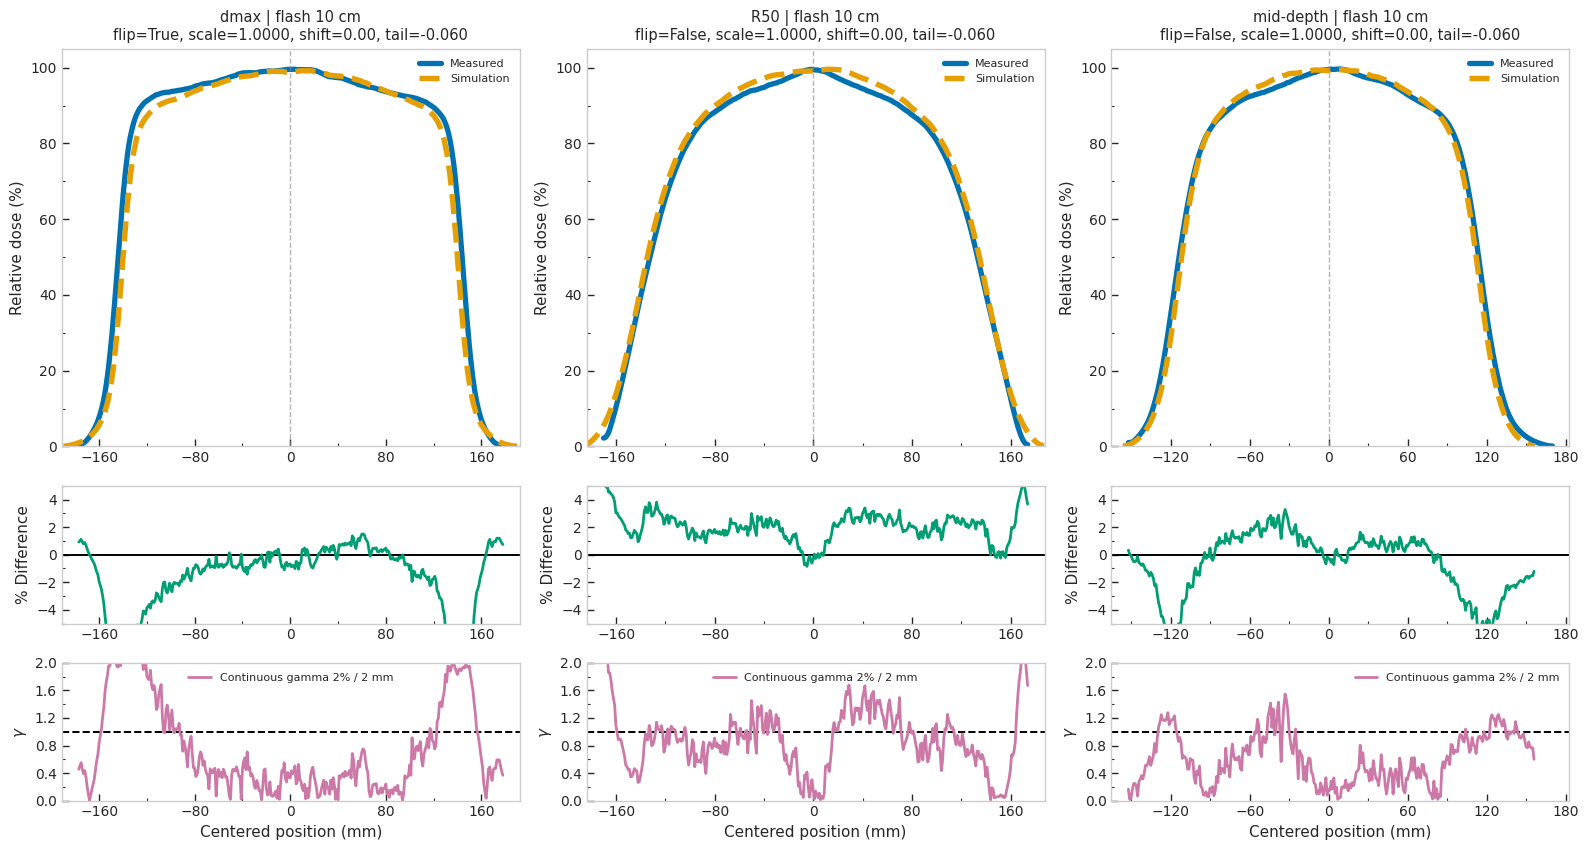

In [16]:
# ============================================================
# MEASURED vs SIMULATION + % DIFFERENCE + CONTINUOUS GAMMA
# WITH PER-DEPTH FLIP + TAIL TUNING + RAW DMAX LEFT SMOOTHING
# + PROFILE SMOOTHING + BASELINE TO ZERO
# ------------------------------------------------------------
# This cell plots:
#   Row 1: measured vs simulation profile
#   Row 2: % difference
#   Row 3: continuous/interpolated gamma
#
# NEW:
#   - smooths the RAW/processed dmax measured left side BEFORE:
#       baseline correction
#       plotting
#       % difference
#       gamma
#       metrics
#
# This means the dmax measured curve is actually smoothed for analysis,
# not only visually.
#
# Saves:
#   PNG, PDF, TIFF
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

# ------------------------------------------------------------
# Pick input source automatically
# IMPORTANT:
# Prefer edge_results first because this contains the simulation
# x-axis after 50% field-edge alignment.
# ------------------------------------------------------------
if "edge_results" in globals():
    source_results = edge_results
    source_kind = "edge_results"

elif "results" in globals():
    source_results = results
    source_kind = "results"

elif "manual_tuned_results" in globals():
    source_results = manual_tuned_results
    source_kind = "manual_tuned_results"

elif "flipped_tail_tuned_results" in globals():
    source_results = flipped_tail_tuned_results
    source_kind = "flipped_tail_tuned_results"

elif "tail_tuned_results" in globals():
    source_results = tail_tuned_results
    source_kind = "tail_tuned_results"

elif "profile_only_results" in globals():
    source_results = profile_only_results
    source_kind = "profile_only_results"

elif "final_clean_results" in globals():
    source_results = final_clean_results
    source_kind = "final_clean_results"

elif "final_results" in globals():
    source_results = final_results
    source_kind = "final_results"

else:
    raise RuntimeError(
        "No usable results found. Run the fresh results creation cell, "
        "then run the edge-alignment cell."
    )

print(f"Using source: {source_kind}")
# ============================================================
# USER CONTROLS
# ============================================================

depth_keys = list(lateral_profile_depth_keys)

# ------------------------------------------------------------
# Save settings
# ------------------------------------------------------------
save_fig = True
save_dir = Path("build")

save_base_name = (
    f"profile_difference_gamma_zero_baseline_raw_dmax_left_smoothed_"
    f"{lateral_mode_select}_{lateral_applicator_select_cm}cm"
)

save_png = True
save_pdf = True
save_tiff = True

# ------------------------------------------------------------
# PER-DEPTH FLIP CONTROLS
# ------------------------------------------------------------
flip_simulation_x_by_depth = {
    "dmax": True,
    "r50": False,
    "middepth": False,
}

# ------------------------------------------------------------
# PER-DEPTH TAIL FINE-TUNING CONTROLS
# ------------------------------------------------------------
sim_x_tail_tune = {
    "dmax": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,
        "tail_strength": -0.06,
        "tail_power": 3.0,
    },
    "r50": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,
        "tail_strength": -0.06,
        "tail_power": 3.0,
    },
    "middepth": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,
        "tail_strength": -0.06,
        "tail_power": 3.0,
    },
}

# ------------------------------------------------------------
# RAW MEASURED DMAX LEFT-SIDE SMOOTHING
# ------------------------------------------------------------
# This modifies the processed dmax measured data BEFORE calculations.
#
# It only applies to:
#   key == "dmax"
#   measured profile only
#   left side only
#
# left_xmax_mm:
#   smooth only measured points with x less than this.
#   0.0 means smooth left half of profile.
#
# smooth_window_mm:
#   larger = smoother / less pointy.
#
# blend_width_mm:
#   prevents a kink where smoothed region meets original region.
# ------------------------------------------------------------

smooth_raw_dmax_left_measured = False

raw_dmax_left_smooth_xmax_mm = 0.0
raw_dmax_left_smooth_window_mm = 25.0
raw_dmax_left_blend_width_mm = 15.0

# If still too pointy, try:
# raw_dmax_left_smooth_window_mm = 22.0
#
# If too rounded, try:
# raw_dmax_left_smooth_window_mm = 12.0

renormalize_after_raw_dmax_left_smoothing = False

# ------------------------------------------------------------
# BASELINE CORRECTION CONTROLS
# ------------------------------------------------------------
baseline_correct_measured = True
baseline_correct_simulation = True

baseline_edge_fraction = 0.10
baseline_percentile = 5.0

# If you want the very lowest edge point to become exactly 0:
# baseline_percentile = 0.0

# ------------------------------------------------------------
# PROFILE SMOOTHING CONTROLS FOR DISPLAY
# ------------------------------------------------------------
# This is additional display smoothing after raw processing.
# Since raw dmax left smoothing already happens before analysis,
# this controls how smooth the plotted curves look.
# ------------------------------------------------------------

smooth_measured_profile_for_display = True
smooth_sim_profile_for_display = True

measured_profile_smooth_window_mm = 10.0
sim_profile_smooth_window_mm = 10.0

# If False:
#   difference and gamma use processed unsmoothed curves.
#
# If True:
#   difference and gamma use display-smoothed curves too.
use_smoothed_profiles_for_difference_gamma = False

# ------------------------------------------------------------
# Difference controls
# ------------------------------------------------------------
diff_ylim = (-5, 5)
difference_label = "% Difference"

smooth_difference_for_display = True
difference_smooth_window_mm = 1.0

# ------------------------------------------------------------
# Continuous gamma controls
# ------------------------------------------------------------
gamma_dose_percent = 2.0
gamma_dist_mm = 2.0

gamma_dose_mode = "global"
gamma_summary_dose_threshold_pct = 10.0

gamma_search_radius_mm = 4.0 * gamma_dist_mm
gamma_search_step_mm = 0.10

smooth_gamma_for_display = True
gamma_display_smooth_window_mm = 0.8

use_smoothed_gamma_for_summary = False

gamma_ylim = (0, 2.0)

# ------------------------------------------------------------
# Plot controls
# ------------------------------------------------------------
x_padding_mm = 4.0
x_padding_fraction = 0.04

profile_ylim = (0, 105)

show_center_line = True
show_title_tuning_values = True
show_legend = True

plt.rcParams["axes.grid"] = False

# Color-blind friendly
color_meas = "#0072B2"
color_sim = "#E69F00"
color_diff = "#009E73"
color_gamma = "#CC79A7"

# Line thickness
lw_meas = 3.8
lw_sim = 3.9
lw_secondary = 2.0
lw_ref = 1.4

pretty_names = {
    "dmax": "dmax",
    "r50": "R50",
    "middepth": "mid-depth",
}

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_array_from_result(r, names):
    for name in names:
        if name in r:
            return np.asarray(r[name], dtype=float)

    raise KeyError(f"Could not find any of these keys: {names}")


def interp_safe(x_src, y_src, x_tgt):
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_tgt = np.asarray(x_tgt, dtype=float)

    order = np.argsort(x_src)
    x_src = x_src[order]
    y_src = y_src[order]

    y = np.interp(x_tgt, x_src, y_src)
    y[(x_tgt < np.nanmin(x_src)) | (x_tgt > np.nanmax(x_src))] = np.nan

    return y


def moving_average_reflect(y, win_pts):
    y = np.asarray(y, dtype=float)

    if win_pts <= 1 or len(y) < 3:
        return y.copy()

    win_pts = int(win_pts)

    if win_pts % 2 == 0:
        win_pts += 1

    pad = win_pts // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")
    kernel = np.ones(win_pts) / win_pts

    return np.convolve(ypad, kernel, mode="valid")


def smooth_by_mm_y_only(x, y, window_mm):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if window_mm is None or window_mm <= 0 or len(x) < 3:
        return y.copy()

    dx = np.nanmedian(np.diff(np.sort(x)))

    if not np.isfinite(dx) or dx <= 0:
        return y.copy()

    win_pts = max(1, int(round(window_mm / dx)))

    return moving_average_reflect(y, win_pts)


def smooth_by_mm(x, y, window_mm):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    y_smooth = smooth_by_mm_y_only(
        x,
        y,
        window_mm,
    )

    return x.copy(), y_smooth


def smooth_left_side_only(
    x,
    y,
    left_xmax_mm=0.0,
    smooth_window_mm=18.0,
    blend_width_mm=12.0,
    renormalize=False,
):
    """
    Smooth only the left side of a profile and blend back into the original.

    This function changes y values, not x values.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    y_smooth_all = smooth_by_mm_y_only(
        x,
        y,
        smooth_window_mm,
    )

    weight = np.zeros_like(x, dtype=float)

    full_smooth_region = x <= (left_xmax_mm - blend_width_mm)
    blend_region = (x > (left_xmax_mm - blend_width_mm)) & (x < left_xmax_mm)

    weight[full_smooth_region] = 1.0

    if np.any(blend_region):
        t = (x[blend_region] - (left_xmax_mm - blend_width_mm)) / blend_width_mm
        weight[blend_region] = 0.5 * (1.0 + np.cos(np.pi * t))

    y_out = weight * y_smooth_all + (1.0 - weight) * y

    y_out = np.clip(y_out, 0.0, None)

    if renormalize:
        ymax = np.nanmax(y_out)
        if np.isfinite(ymax) and ymax > 0:
            y_out = 100.0 * y_out / ymax

    return y_out


def baseline_to_zero(y, edge_fraction=0.10, percentile=5.0):
    """
    Subtract baseline estimated from profile edges,
    clip below zero, and renormalize to 100.
    """
    y = np.asarray(y, dtype=float)

    if len(y) < 4:
        return y.copy(), np.nan

    n_edge = max(1, int(round(edge_fraction * len(y))))

    edge_values = np.concatenate([
        y[:n_edge],
        y[-n_edge:],
    ])

    edge_values = edge_values[np.isfinite(edge_values)]

    if len(edge_values) == 0:
        return y.copy(), np.nan

    baseline = float(np.nanpercentile(edge_values, percentile))

    y0 = y - baseline
    y0 = np.clip(y0, 0.0, None)

    ymax = np.nanmax(y0)

    if np.isfinite(ymax) and ymax > 0:
        y0 = 100.0 * y0 / ymax

    return y0, baseline


def get_xlim_from_measured(meas_x, pad_mm=4.0, pad_frac=0.04):
    meas_x = np.asarray(meas_x, dtype=float)
    meas_x = meas_x[np.isfinite(meas_x)]

    xmin = float(np.nanmin(meas_x))
    xmax = float(np.nanmax(meas_x))
    width = xmax - xmin

    pad = max(pad_mm, pad_frac * width)

    return xmin - pad, xmax + pad


def apply_sim_flip(sim_x, flip=False):
    sim_x = np.asarray(sim_x, dtype=float)

    if flip:
        return -1.0 * sim_x

    return sim_x.copy()


def apply_tail_x_tune(sim_x, meas_x, tune):
    sim_x = np.asarray(sim_x, dtype=float)
    meas_x = np.asarray(meas_x, dtype=float)

    x_scale = float(tune.get("x_scale", 1.0))
    x_shift = float(tune.get("x_shift_mm", 0.0))
    tail_strength = float(tune.get("tail_strength", 0.0))
    tail_power = float(tune.get("tail_power", 3.0))

    x = x_scale * sim_x + x_shift

    finite_meas = meas_x[np.isfinite(meas_x)]
    if len(finite_meas) < 2:
        return x

    half_width = 0.5 * (np.nanmax(finite_meas) - np.nanmin(finite_meas))

    if not np.isfinite(half_width) or half_width <= 0:
        return x

    u = np.abs(x) / half_width
    u = np.clip(u, 0.0, 2.0)

    tail_factor = u ** tail_power

    x_tuned = x * (1.0 + tail_strength * tail_factor)

    return x_tuned


def continuous_gamma_1d(
    ref_x,
    ref_y,
    eval_x,
    eval_y,
    dose_percent=2.0,
    dist_mm=2.0,
    dose_mode="global",
    search_radius_mm=8.0,
    search_step_mm=0.10,
):
    ref_x = np.asarray(ref_x, dtype=float)
    ref_y = np.asarray(ref_y, dtype=float)

    eval_x = np.asarray(eval_x, dtype=float)
    eval_y = np.asarray(eval_y, dtype=float)

    order = np.argsort(eval_x)
    eval_x = eval_x[order]
    eval_y = eval_y[order]

    dx_values = np.arange(
        -search_radius_mm,
        search_radius_mm + 0.5 * search_step_mm,
        search_step_mm,
    )

    gamma_vals = np.full_like(ref_x, np.nan, dtype=float)

    for i, (xm, ym) in enumerate(zip(ref_x, ref_y)):
        x_samples = xm + dx_values

        sim_samples = np.interp(x_samples, eval_x, eval_y)
        outside = (x_samples < np.nanmin(eval_x)) | (x_samples > np.nanmax(eval_x))
        sim_samples[outside] = np.nan

        valid = np.isfinite(sim_samples)

        if not np.any(valid):
            continue

        dx = dx_values[valid]
        dy = sim_samples[valid] - ym

        if dose_mode.lower() == "local":
            dose_crit = dose_percent * max(abs(ym), 1e-6) / 100.0
        else:
            dose_crit = dose_percent

        gamma = np.sqrt((dx / dist_mm) ** 2 + (dy / dose_crit) ** 2)

        gamma_vals[i] = np.nanmin(gamma)

    return gamma_vals


def style_axis(ax):
    ax.grid(False)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=5,
        width=1.0,
        labelsize=10,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=2.5,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


# ============================================================
# BUILD FINAL PROFILE + DIFFERENCE + GAMMA RESULTS
# ============================================================

profile_diff_gamma_results = {}
summary_rows = []

for key in depth_keys:
    if key not in source_results:
        raise KeyError(
            f"Depth key '{key}' not found in {source_kind}. "
            f"Available keys: {list(source_results.keys())}"
        )

    r = source_results[key]

    meas_x = get_array_from_result(r, ["meas_x"])
    meas_y = get_array_from_result(r, ["meas_y"])

    sim_x_raw = get_array_from_result(
        r,
        ["sim_x_aligned", "sim_x_tuned", "sim_x"],
    )

    sim_y_raw = get_array_from_result(
        r,
        ["sim_y_tuned", "sim_y", "sim_y_aligned"],
    )

    # Sort measured
    mo = np.argsort(meas_x)
    meas_x = meas_x[mo]
    meas_y = meas_y[mo]

    # Keep original measured before raw smoothing
    meas_y_original_before_raw_smoothing = meas_y.copy()

    # --------------------------------------------------------
    # RAW DMAX MEASURED LEFT-SIDE SMOOTHING
    # This happens BEFORE baseline correction and calculations.
    # --------------------------------------------------------
    raw_dmax_left_smoothed_applied = False

    if key == "dmax" and smooth_raw_dmax_left_measured:
        meas_y = smooth_left_side_only(
            x=meas_x,
            y=meas_y,
            left_xmax_mm=raw_dmax_left_smooth_xmax_mm,
            smooth_window_mm=raw_dmax_left_smooth_window_mm,
            blend_width_mm=raw_dmax_left_blend_width_mm,
            renormalize=renormalize_after_raw_dmax_left_smoothing,
        )
        raw_dmax_left_smoothed_applied = True

    # Sort simulation
    so = np.argsort(sim_x_raw)
    sim_x_raw = sim_x_raw[so]
    sim_y_raw = sim_y_raw[so]

    # --------------------------------------------------------
    # Baseline-correct measured so tails touch 0
    # --------------------------------------------------------
    if baseline_correct_measured:
        meas_y, meas_baseline = baseline_to_zero(
            meas_y,
            edge_fraction=baseline_edge_fraction,
            percentile=baseline_percentile,
        )
    else:
        meas_baseline = np.nan

    # --------------------------------------------------------
    # Per-depth flip simulation
    # --------------------------------------------------------
    flip_this_depth = bool(flip_simulation_x_by_depth.get(key, False))

    sim_x_flipped = apply_sim_flip(
        sim_x_raw,
        flip=flip_this_depth,
    )

    sim_y_flipped = sim_y_raw.copy()

    # Sort after flip
    fo = np.argsort(sim_x_flipped)
    sim_x_flipped = sim_x_flipped[fo]
    sim_y_flipped = sim_y_flipped[fo]

    # --------------------------------------------------------
    # Baseline-correct simulation too, optional
    # --------------------------------------------------------
    if baseline_correct_simulation:
        sim_y_flipped, sim_baseline = baseline_to_zero(
            sim_y_flipped,
            edge_fraction=baseline_edge_fraction,
            percentile=baseline_percentile,
        )
    else:
        sim_baseline = np.nan

    # --------------------------------------------------------
    # Per-depth tail tuning
    # --------------------------------------------------------
    tune = sim_x_tail_tune.get(
        key,
        {
            "x_scale": 1.0,
            "x_shift_mm": 0.0,
            "tail_strength": 0.0,
            "tail_power": 3.0,
        },
    )

    sim_x_tuned = apply_tail_x_tune(
        sim_x=sim_x_flipped,
        meas_x=meas_x,
        tune=tune,
    )

    sim_y_tuned = sim_y_flipped.copy()

    # Sort after tuning
    to = np.argsort(sim_x_tuned)
    sim_x_tuned = sim_x_tuned[to]
    sim_y_tuned = sim_y_tuned[to]

    # --------------------------------------------------------
    # Smooth profiles for display
    # --------------------------------------------------------
    meas_x_plot = meas_x.copy()
    meas_y_plot = meas_y.copy()

    sim_x_plot = sim_x_tuned.copy()
    sim_y_plot = sim_y_tuned.copy()

    if smooth_measured_profile_for_display:
        meas_x_plot, meas_y_plot = smooth_by_mm(
            meas_x_plot,
            meas_y_plot,
            measured_profile_smooth_window_mm,
        )

    if smooth_sim_profile_for_display:
        sim_x_plot, sim_y_plot = smooth_by_mm(
            sim_x_plot,
            sim_y_plot,
            sim_profile_smooth_window_mm,
        )

    # Force plotted tails to be nonnegative after smoothing
    meas_y_plot = np.clip(meas_y_plot, 0.0, None)
    sim_y_plot = np.clip(sim_y_plot, 0.0, None)

    # --------------------------------------------------------
    # Choose profiles for difference/gamma calculation
    # --------------------------------------------------------
    if use_smoothed_profiles_for_difference_gamma:
        meas_x_calc = meas_x_plot.copy()
        meas_y_calc = meas_y_plot.copy()
        sim_x_calc = sim_x_plot.copy()
        sim_y_calc = sim_y_plot.copy()
    else:
        meas_x_calc = meas_x.copy()
        meas_y_calc = meas_y.copy()
        sim_x_calc = sim_x_tuned.copy()
        sim_y_calc = sim_y_tuned.copy()

    # --------------------------------------------------------
    # Difference
    # --------------------------------------------------------
    sim_on_meas = interp_safe(
        sim_x_calc,
        sim_y_calc,
        meas_x_calc,
    )

    comp = pd.DataFrame({
        "x_mm": meas_x_calc,
        "measured_pct": meas_y_calc,
        "sim_pct": sim_on_meas,
    }).dropna()

    comp["diff_pctpts"] = comp["sim_pct"] - comp["measured_pct"]

    diff_x_plot = comp["x_mm"].values.copy()
    diff_y_plot = comp["diff_pctpts"].values.copy()

    if smooth_difference_for_display:
        diff_x_plot, diff_y_plot = smooth_by_mm(
            diff_x_plot,
            diff_y_plot,
            difference_smooth_window_mm,
        )

    # --------------------------------------------------------
    # Continuous gamma
    # --------------------------------------------------------
    gamma_vals = continuous_gamma_1d(
        ref_x=comp["x_mm"].values,
        ref_y=comp["measured_pct"].values,
        eval_x=sim_x_calc,
        eval_y=sim_y_calc,
        dose_percent=gamma_dose_percent,
        dist_mm=gamma_dist_mm,
        dose_mode=gamma_dose_mode,
        search_radius_mm=gamma_search_radius_mm,
        search_step_mm=gamma_search_step_mm,
    )

    gamma_x_plot = comp["x_mm"].values.copy()
    gamma_y_plot = gamma_vals.copy()

    if smooth_gamma_for_display:
        gamma_x_plot, gamma_y_plot = smooth_by_mm(
            gamma_x_plot,
            gamma_y_plot,
            gamma_display_smooth_window_mm,
        )

    # --------------------------------------------------------
    # Summary metrics
    # --------------------------------------------------------
    diff_mask = comp["measured_pct"].values >= gamma_summary_dose_threshold_pct

    summary_gamma = gamma_y_plot if use_smoothed_gamma_for_summary else gamma_vals
    gamma_mask = diff_mask & np.isfinite(summary_gamma)

    if np.any(diff_mask):
        rmse = float(np.sqrt(np.mean(comp["diff_pctpts"].values[diff_mask] ** 2)))
        mae = float(np.mean(np.abs(comp["diff_pctpts"].values[diff_mask])))
        maxabs = float(np.max(np.abs(comp["diff_pctpts"].values[diff_mask])))
    else:
        rmse = np.nan
        mae = np.nan
        maxabs = np.nan

    if np.any(gamma_mask):
        gamma_pass = float(100.0 * np.mean(summary_gamma[gamma_mask] <= 1.0))
        gamma_mean = float(np.nanmean(summary_gamma[gamma_mask]))
        gamma_max = float(np.nanmax(summary_gamma[gamma_mask]))
    else:
        gamma_pass = np.nan
        gamma_mean = np.nan
        gamma_max = np.nan

    profile_diff_gamma_results[key] = {
        "meas_x": meas_x,
        "meas_y_original_before_raw_smoothing": meas_y_original_before_raw_smoothing,
        "meas_y": meas_y,
        "meas_x_plot": meas_x_plot,
        "meas_y_plot": meas_y_plot,
        "sim_x": sim_x_tuned,
        "sim_y": sim_y_tuned,
        "sim_x_plot": sim_x_plot,
        "sim_y_plot": sim_y_plot,
        "comp": comp,
        "diff_x_plot": diff_x_plot,
        "diff_y_plot": diff_y_plot,
        "gamma_x_plot": gamma_x_plot,
        "gamma_y_plot": gamma_y_plot,
        "gamma_raw": gamma_vals,
        "flip": flip_this_depth,
        "tune": tune,
        "meas_baseline": meas_baseline,
        "sim_baseline": sim_baseline,
        "raw_dmax_left_smoothed_applied": raw_dmax_left_smoothed_applied,
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    }

    summary_rows.append({
        "Depth": key,
        "Flip": flip_this_depth,
        "RawDmaxLeftSmoothed": raw_dmax_left_smoothed_applied,
        "MeasBaseline": meas_baseline,
        "SimBaseline": sim_baseline,
        "x_scale": tune["x_scale"],
        "x_shift_mm": tune["x_shift_mm"],
        "tail_strength": tune["tail_strength"],
        "tail_power": tune["tail_power"],
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    })

profile_diff_gamma_summary_df = pd.DataFrame(summary_rows)

print("Profile + difference + continuous gamma summary:")
display(profile_diff_gamma_summary_df.round(4))


# ============================================================
# PLOT: 3 ROWS x DEPTHS
# ============================================================

fig, axes = plt.subplots(
    3,
    len(depth_keys),
    figsize=(16, 8.6),
    sharex=False,
    gridspec_kw={"height_ratios": [2.6, 0.9, 0.9]},
)

fig.subplots_adjust(wspace=0.25, hspace=0.12)

if len(depth_keys) == 1:
    axes = np.asarray(axes).reshape(3, 1)

for col, key in enumerate(depth_keys):
    r = profile_diff_gamma_results[key]

    ax_top = axes[0, col]
    ax_mid = axes[1, col]
    ax_bot = axes[2, col]

    xmin, xmax = get_xlim_from_measured(
        r["meas_x"],
        pad_mm=x_padding_mm,
        pad_frac=x_padding_fraction,
    )

    # --------------------------------------------------------
    # Row 1: Baseline-corrected profile
    # --------------------------------------------------------
    ax_top.plot(
        r["meas_x_plot"],
        r["meas_y_plot"],
        "-",
        lw=lw_meas,
        color=color_meas,
        label="Measured",
    )

    ax_top.plot(
        r["sim_x_plot"],
        r["sim_y_plot"],
        "--",
        lw=lw_sim,
        color=color_sim,
        label="Simulation",
    )

    if show_center_line:
        ax_top.axvline(
            0,
            color="0.55",
            lw=1.0,
            ls="--",
            alpha=0.65,
        )

    t = r["tune"]

    if show_title_tuning_values:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm\n"
            f"flip={r['flip']}, scale={t['x_scale']:.4f}, "
            f"shift={t['x_shift_mm']:.2f}, tail={t['tail_strength']:.3f}",
            fontsize=10.5,
        )
    else:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm",
            fontsize=11,
        )

    ax_top.set_ylabel("Relative dose (%)", fontsize=11)
    ax_top.set_xlim(xmin, xmax)
    ax_top.set_ylim(*profile_ylim)

    ax_top.margins(y=0)

    if show_legend:
        ax_top.legend(frameon=False, fontsize=8, loc="best")

    style_axis(ax_top)
    ax_top.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # --------------------------------------------------------
    # Row 2: Difference
    # --------------------------------------------------------
    ax_mid.axhline(
        0,
        color="black",
        lw=lw_ref,
    )

    ax_mid.plot(
        r["diff_x_plot"],
        r["diff_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_diff,
    )

    ax_mid.set_ylabel(difference_label, fontsize=11)
    ax_mid.set_xlim(xmin, xmax)
    ax_mid.set_ylim(*diff_ylim)

    style_axis(ax_mid)
    ax_mid.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # --------------------------------------------------------
    # Row 3: Continuous gamma
    # --------------------------------------------------------
    ax_bot.axhline(
        1.0,
        color="black",
        lw=lw_ref,
        ls="--",
    )

    ax_bot.plot(
        r["gamma_x_plot"],
        r["gamma_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_gamma,
        label=f"Continuous gamma {gamma_dose_percent:g}% / {gamma_dist_mm:g} mm",
    )

    ax_bot.set_xlabel("Centered position (mm)", fontsize=11)
    ax_bot.set_ylabel(r"$\gamma$", fontsize=11)
    ax_bot.set_xlim(xmin, xmax)
    ax_bot.set_ylim(*gamma_ylim)

    ax_bot.legend(frameon=False, fontsize=8, loc="best")

    style_axis(ax_bot)
    ax_bot.yaxis.set_major_locator(MaxNLocator(nbins=5))

plt.tight_layout()

# ============================================================
# SAVE UPDATED FIGURES
# ============================================================

if save_fig:
    save_dir.mkdir(parents=True, exist_ok=True)

    if save_png:
        png_path = save_dir / f"{save_base_name}.png"
        fig.savefig(
            png_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PNG:  {png_path}")

    if save_pdf:
        pdf_path = save_dir / f"{save_base_name}.pdf"
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PDF:  {pdf_path}")

    if save_tiff:
        tiff_path = save_dir / f"{save_base_name}.tiff"
        fig.savefig(
            tiff_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved TIFF: {tiff_path}")

plt.show()

Using source: edge_results
Profile + difference + continuous gamma summary:


,Depth,Flip,RawDmaxLeftSmoothed,MeasBaseline,SimBaseline,x_scale,x_shift_mm,left_start_mm,left_shift_max_mm,right_start_mm,right_shift_max_mm,blend_width_mm,power,RMSE,MAE,MaxAbs,Gamma Pass,Gamma Mean,Gamma Max
0,dmax,False,False,5.2593,1.1427,1.0,0.0,-20.0,6.2,20.0,-6.2,20.0,5.0,2.1619,1.6249,5.7947,93.1034,0.3928,1.2175
1,r50,False,False,6.7076,1.0494,1.0,0.0,-27.0,9.5,27.0,-9.5,18.0,2.6,1.6685,1.3670,3.9628,100.0000,0.3035,0.8395
2,middepth,False,False,6.3550,1.0463,1.0,0.0,-27.0,12.8,27.0,-12.8,18.0,2.6,1.5287,1.1657,4.7440,98.4848,0.2848,1.1226


Saved PNG:  build/profile_difference_gamma_zero_baseline_per_side_tuned_flash_2cm.png
Saved PDF:  build/profile_difference_gamma_zero_baseline_per_side_tuned_flash_2cm.pdf
Saved TIFF: build/profile_difference_gamma_zero_baseline_per_side_tuned_flash_2cm.tiff


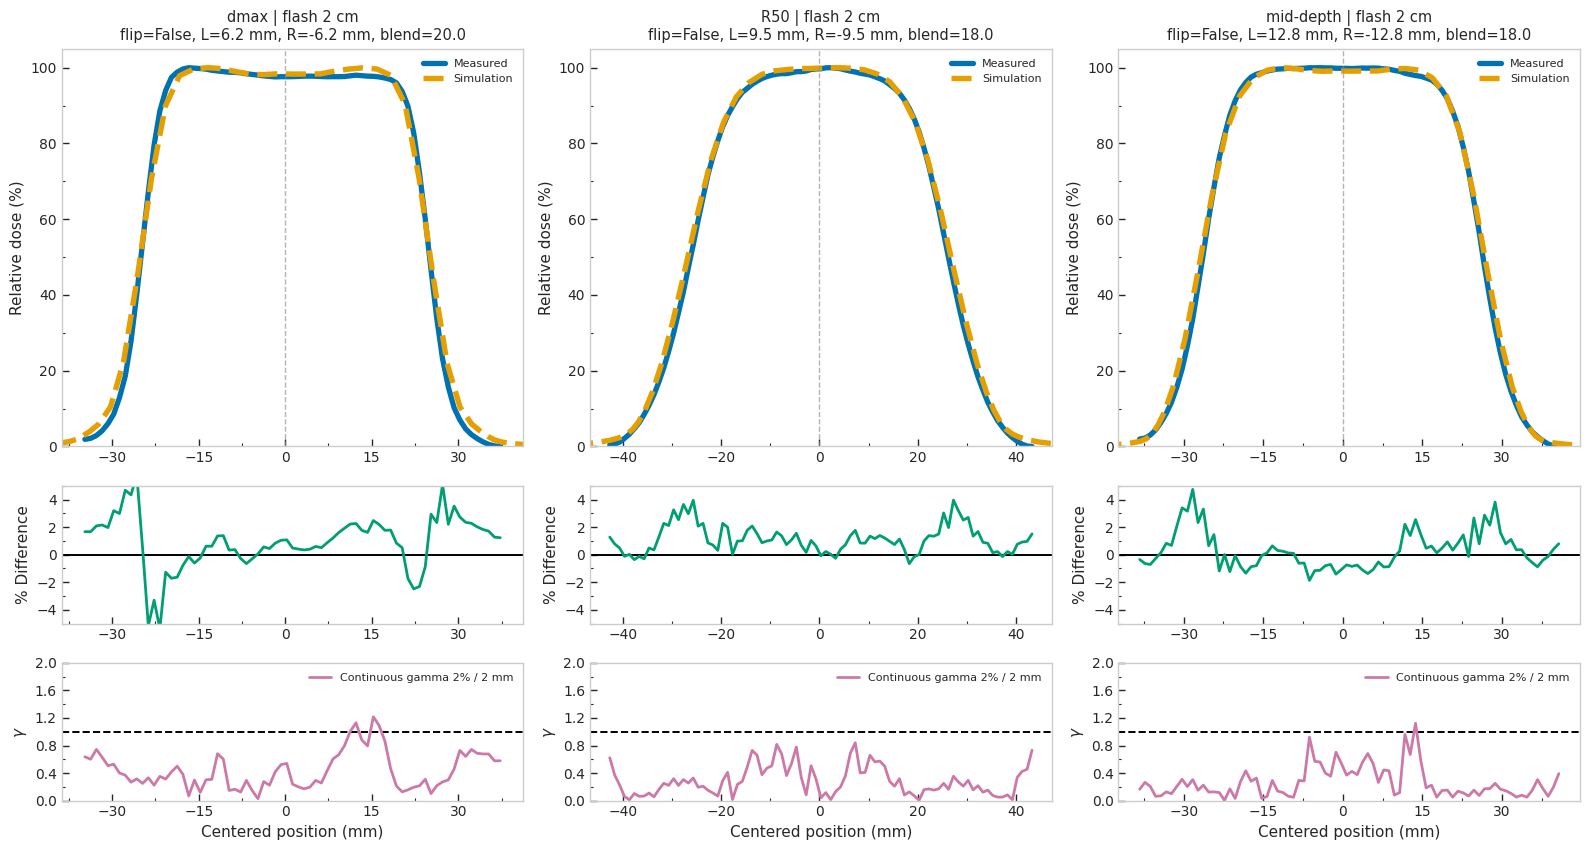

In [15]:
# ============================================================
# MEASURED vs SIMULATION + % DIFFERENCE + CONTINUOUS GAMMA
# WITH EDGE-ALIGNED INPUT + PER-SIDE SIMULATION X TUNING
# + PROFILE SMOOTHING + BASELINE TO ZERO
# ------------------------------------------------------------
# This cell plots:
#   Row 1: measured vs simulation profile
#   Row 2: % difference
#   Row 3: continuous/interpolated gamma
#
# IMPORTANT:
#   - Prefer edge_results first because edge_results contains
#     simulation x-axis already aligned to measured 50% field edges.
#
# NEW:
#   - per-depth, per-side simulation x tuning:
#       left_shift_max_mm
#       right_shift_max_mm
#       left_start_mm
#       right_start_mm
#       blend_width_mm
#       power
#
#   - display profiles are re-baselined after smoothing so the tails
#     touch the x-axis / 0%.
#
# Saves:
#   PNG, PDF, TIFF
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

# ------------------------------------------------------------
# Pick input source automatically
# ------------------------------------------------------------
# IMPORTANT:
# Use edge_results first because this contains the simulation x-axis
# after 50% field-edge alignment.
# ------------------------------------------------------------
if "edge_results" in globals():
    source_results = edge_results
    source_kind = "edge_results"

elif "results" in globals():
    source_results = results
    source_kind = "results"

elif "manual_tuned_results" in globals():
    source_results = manual_tuned_results
    source_kind = "manual_tuned_results"

elif "flipped_tail_tuned_results" in globals():
    source_results = flipped_tail_tuned_results
    source_kind = "flipped_tail_tuned_results"

elif "tail_tuned_results" in globals():
    source_results = tail_tuned_results
    source_kind = "tail_tuned_results"

elif "profile_only_results" in globals():
    source_results = profile_only_results
    source_kind = "profile_only_results"

elif "final_clean_results" in globals():
    source_results = final_clean_results
    source_kind = "final_clean_results"

elif "final_results" in globals():
    source_results = final_results
    source_kind = "final_results"

else:
    raise RuntimeError(
        "No usable results found. Run the fresh results creation cell, "
        "then run the edge-alignment cell."
    )

print(f"Using source: {source_kind}")

# ============================================================
# USER CONTROLS
# ============================================================

depth_keys = list(lateral_profile_depth_keys)

# ------------------------------------------------------------
# Save settings
# ------------------------------------------------------------
save_fig = True
save_dir = Path("build")

save_base_name = (
    f"profile_difference_gamma_zero_baseline_per_side_tuned_"
    f"{lateral_mode_select}_{lateral_applicator_select_cm}cm"
)

save_png = True
save_pdf = True
save_tiff = True

# ------------------------------------------------------------
# PER-DEPTH FLIP CONTROLS
# ------------------------------------------------------------
# Recommended:
#   Keep all False when using edge_results unless you know the
#   simulation left/right direction is reversed.
# ------------------------------------------------------------
flip_simulation_x_by_depth = {
    "dmax": False,
    "r50": False,
    "middepth": False,
}

# ------------------------------------------------------------
# PER-DEPTH SIMULATION X-SHAPE TUNING
# ------------------------------------------------------------
# These tune the simulation x-position only.
# They do NOT change dose values.
#
# x_scale:
#   global width scaling. Keep 1.0 if using edge_results.
#
# x_shift_mm:
#   global left/right shift.
#
# left_start_mm:
#   tuning starts for x values less than this.
#
# right_start_mm:
#   tuning starts for x values greater than this.
#
# left_shift_max_mm:
#   positive = move left simulation tail/penumbra to the RIGHT
#   negative = move left simulation tail/penumbra to the LEFT
#
# right_shift_max_mm:
#   positive = move right simulation tail/penumbra to the RIGHT
#   negative = move right simulation tail/penumbra to the LEFT
#
# blend_width_mm:
#   larger = smoother more gradual tuning
#   smaller = sharper localized tuning
#
# power:
#   larger = tuning turns on more sharply in the tail
# ------------------------------------------------------------

sim_x_tail_tune = {
    "dmax": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,

        # dmax: previous L/R=4.8 was too aggressive.
        # Reduce inward pull so shoulders/plateau match better.
        "left_start_mm": -20.0,
        "left_shift_max_mm": 6.2,

        "right_start_mm": 20.0,
        "right_shift_max_mm": -6.2,

        "blend_width_mm": 20.0,
        "power": 5,
    },

    "r50": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,

        # R50: keep main penumbra mostly unchanged,
        # but pull the OUTER tails inward more.
        "left_start_mm": -27.0,
        "left_shift_max_mm": 9.5,

        "right_start_mm": 27.0,
        "right_shift_max_mm": -9.5,

        "blend_width_mm": 18.0,
        "power": 2.6,
    },

    "middepth": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,

        # Mid-depth: tails are still high/wide.
        # Right side needs slightly stronger correction.
        "left_start_mm": -27.0,
        "left_shift_max_mm": 12.8,

        "right_start_mm": 27.0,
        "right_shift_max_mm": -12.8,

        "blend_width_mm": 18.0,
        "power": 2.6,
    },
}
# ------------------------------------------------------------
# RAW MEASURED DMAX LEFT-SIDE SMOOTHING
# ------------------------------------------------------------
# Recommended:
#   Keep False for validation unless you intentionally want to alter
#   measured data before analysis.
# ------------------------------------------------------------

smooth_raw_dmax_left_measured = False

raw_dmax_left_smooth_xmax_mm = 0.0
raw_dmax_left_smooth_window_mm = 25.0
raw_dmax_left_blend_width_mm = 15.0

renormalize_after_raw_dmax_left_smoothing = False

# ------------------------------------------------------------
# BASELINE CORRECTION CONTROLS
# ------------------------------------------------------------
# baseline_percentile = 0.0 makes the lowest edge value go to 0.
# If this is too aggressive, use 5.0.
# ------------------------------------------------------------

baseline_correct_measured = True
baseline_correct_simulation = True

baseline_edge_fraction = 0.10
baseline_percentile = 0.0

# ------------------------------------------------------------
# PROFILE SMOOTHING CONTROLS FOR DISPLAY
# ------------------------------------------------------------
# These smooth only the displayed top profile curves unless
# use_smoothed_profiles_for_difference_gamma = True.
# ------------------------------------------------------------

smooth_measured_profile_for_display = True
smooth_sim_profile_for_display = True

# Recommended:
#   10 mm can be strong. Use 4-6 mm first for tuning.
measured_profile_smooth_window_mm = 5.0
sim_profile_smooth_window_mm = 5.0

# If False:
#   difference and gamma use processed unsmoothed curves.
#
# If True:
#   difference and gamma use display-smoothed curves too.
use_smoothed_profiles_for_difference_gamma = False

# ------------------------------------------------------------
# Difference controls
# ------------------------------------------------------------

diff_ylim = (-5, 5)
difference_label = "% Difference"

smooth_difference_for_display = True
difference_smooth_window_mm = 1.0

# ------------------------------------------------------------
# Continuous gamma controls
# ------------------------------------------------------------

gamma_dose_percent = 2.0
gamma_dist_mm = 2.0

gamma_dose_mode = "global"
gamma_summary_dose_threshold_pct = 10.0

gamma_search_radius_mm = 4.0 * gamma_dist_mm
gamma_search_step_mm = 0.10

smooth_gamma_for_display = True
gamma_display_smooth_window_mm = 0.8

use_smoothed_gamma_for_summary = False

gamma_ylim = (0, 2.0)

# ------------------------------------------------------------
# Plot controls
# ------------------------------------------------------------

x_padding_mm = 4.0
x_padding_fraction = 0.04

profile_ylim = (0, 105)

show_center_line = True
show_title_tuning_values = True
show_legend = True

plt.rcParams["axes.grid"] = False

# Color-blind friendly Okabe-Ito style colors
color_meas = "#0072B2"   # blue
color_sim = "#E69F00"    # orange/gold
color_diff = "#009E73"   # green
color_gamma = "#CC79A7"  # purple

# Line thickness
lw_meas = 3.8
lw_sim = 3.9
lw_secondary = 2.0
lw_ref = 1.4

pretty_names = {
    "dmax": "dmax",
    "r50": "R50",
    "middepth": "mid-depth",
}

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_array_from_result(r, names):
    for name in names:
        if name in r:
            return np.asarray(r[name], dtype=float)

    raise KeyError(f"Could not find any of these keys: {names}")


def interp_safe(x_src, y_src, x_tgt):
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_tgt = np.asarray(x_tgt, dtype=float)

    order = np.argsort(x_src)
    x_src = x_src[order]
    y_src = y_src[order]

    y = np.interp(x_tgt, x_src, y_src)
    y[(x_tgt < np.nanmin(x_src)) | (x_tgt > np.nanmax(x_src))] = np.nan

    return y


def moving_average_reflect(y, win_pts):
    y = np.asarray(y, dtype=float)

    if win_pts <= 1 or len(y) < 3:
        return y.copy()

    win_pts = int(win_pts)

    if win_pts % 2 == 0:
        win_pts += 1

    pad = win_pts // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")
    kernel = np.ones(win_pts) / win_pts

    return np.convolve(ypad, kernel, mode="valid")


def smooth_by_mm_y_only(x, y, window_mm):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if window_mm is None or window_mm <= 0 or len(x) < 3:
        return y.copy()

    dx = np.nanmedian(np.diff(np.sort(x)))

    if not np.isfinite(dx) or dx <= 0:
        return y.copy()

    win_pts = max(1, int(round(window_mm / dx)))

    return moving_average_reflect(y, win_pts)


def smooth_by_mm(x, y, window_mm):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    y_smooth = smooth_by_mm_y_only(
        x,
        y,
        window_mm,
    )

    return x.copy(), y_smooth


def smooth_left_side_only(
    x,
    y,
    left_xmax_mm=0.0,
    smooth_window_mm=18.0,
    blend_width_mm=12.0,
    renormalize=False,
):
    """
    Smooth only the left side of a measured profile and blend
    back into the original.

    This function changes measured y values, not x values.
    Use carefully.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    y_smooth_all = smooth_by_mm_y_only(
        x,
        y,
        smooth_window_mm,
    )

    weight = np.zeros_like(x, dtype=float)

    full_smooth_region = x <= (left_xmax_mm - blend_width_mm)
    blend_region = (x > (left_xmax_mm - blend_width_mm)) & (x < left_xmax_mm)

    weight[full_smooth_region] = 1.0

    if np.any(blend_region):
        t = (x[blend_region] - (left_xmax_mm - blend_width_mm)) / blend_width_mm
        weight[blend_region] = 0.5 * (1.0 + np.cos(np.pi * t))

    y_out = weight * y_smooth_all + (1.0 - weight) * y

    y_out = np.clip(y_out, 0.0, None)

    if renormalize:
        ymax = np.nanmax(y_out)
        if np.isfinite(ymax) and ymax > 0:
            y_out = 100.0 * y_out / ymax

    return y_out


def baseline_to_zero(y, edge_fraction=0.10, percentile=5.0):
    """
    Subtract baseline estimated from profile edges,
    clip below zero, and renormalize to 100.
    """
    y = np.asarray(y, dtype=float)

    if len(y) < 4:
        return y.copy(), np.nan

    n_edge = max(1, int(round(edge_fraction * len(y))))

    edge_values = np.concatenate([
        y[:n_edge],
        y[-n_edge:],
    ])

    edge_values = edge_values[np.isfinite(edge_values)]

    if len(edge_values) == 0:
        return y.copy(), np.nan

    baseline = float(np.nanpercentile(edge_values, percentile))

    y0 = y - baseline
    y0 = np.clip(y0, 0.0, None)

    ymax = np.nanmax(y0)

    if np.isfinite(ymax) and ymax > 0:
        y0 = 100.0 * y0 / ymax

    return y0, baseline


def get_xlim_from_measured(meas_x, pad_mm=4.0, pad_frac=0.04):
    meas_x = np.asarray(meas_x, dtype=float)
    meas_x = meas_x[np.isfinite(meas_x)]

    xmin = float(np.nanmin(meas_x))
    xmax = float(np.nanmax(meas_x))
    width = xmax - xmin

    pad = max(pad_mm, pad_frac * width)

    return xmin - pad, xmax + pad


def apply_sim_flip(sim_x, flip=False):
    sim_x = np.asarray(sim_x, dtype=float)

    if flip:
        return -1.0 * sim_x

    return sim_x.copy()


def apply_tail_x_tune(sim_x, meas_x, tune):
    """
    Apply per-side x-coordinate tuning to the simulation profile.

    This changes only simulation x positions, not dose values.

    left_shift_max_mm:
        positive moves the left tail/penumbra to the right.
        negative moves the left tail/penumbra to the left.

    right_shift_max_mm:
        positive moves the right tail/penumbra to the right.
        negative moves the right tail/penumbra to the left.
    """
    sim_x = np.asarray(sim_x, dtype=float)

    # Global scale/shift first.
    x_scale = float(tune.get("x_scale", 1.0))
    x_shift = float(tune.get("x_shift_mm", 0.0))

    x = x_scale * sim_x + x_shift

    # Per-side controls.
    left_start = float(tune.get("left_start_mm", -np.inf))
    right_start = float(tune.get("right_start_mm", np.inf))

    left_shift_max = float(tune.get("left_shift_max_mm", 0.0))
    right_shift_max = float(tune.get("right_shift_max_mm", 0.0))

    blend_width = float(tune.get("blend_width_mm", 15.0))
    power = float(tune.get("power", 2.5))

    if not np.isfinite(blend_width) or blend_width <= 0:
        blend_width = 15.0

    if not np.isfinite(power) or power <= 0:
        power = 2.5

    x_tuned = x.copy()

    # --------------------------------------------------------
    # Left side tuning
    # --------------------------------------------------------
    left_mask = x < left_start

    if np.any(left_mask) and left_shift_max != 0.0:
        u_left = (left_start - x[left_mask]) / blend_width
        u_left = np.clip(u_left, 0.0, 5.0)

        # Smooth ramp: 0 near start, approaches 1 in the tail.
        ramp_left = 1.0 - np.exp(-(u_left ** power))

        x_tuned[left_mask] = x[left_mask] + left_shift_max * ramp_left

    # --------------------------------------------------------
    # Right side tuning
    # --------------------------------------------------------
    right_mask = x > right_start

    if np.any(right_mask) and right_shift_max != 0.0:
        u_right = (x[right_mask] - right_start) / blend_width
        u_right = np.clip(u_right, 0.0, 5.0)

        # Smooth ramp: 0 near start, approaches 1 in the tail.
        ramp_right = 1.0 - np.exp(-(u_right ** power))

        x_tuned[right_mask] = x[right_mask] + right_shift_max * ramp_right

    return x_tuned


def continuous_gamma_1d(
    ref_x,
    ref_y,
    eval_x,
    eval_y,
    dose_percent=2.0,
    dist_mm=2.0,
    dose_mode="global",
    search_radius_mm=8.0,
    search_step_mm=0.10,
):
    ref_x = np.asarray(ref_x, dtype=float)
    ref_y = np.asarray(ref_y, dtype=float)

    eval_x = np.asarray(eval_x, dtype=float)
    eval_y = np.asarray(eval_y, dtype=float)

    order = np.argsort(eval_x)
    eval_x = eval_x[order]
    eval_y = eval_y[order]

    dx_values = np.arange(
        -search_radius_mm,
        search_radius_mm + 0.5 * search_step_mm,
        search_step_mm,
    )

    gamma_vals = np.full_like(ref_x, np.nan, dtype=float)

    for i, (xm, ym) in enumerate(zip(ref_x, ref_y)):
        x_samples = xm + dx_values

        sim_samples = np.interp(x_samples, eval_x, eval_y)
        outside = (x_samples < np.nanmin(eval_x)) | (x_samples > np.nanmax(eval_x))
        sim_samples[outside] = np.nan

        valid = np.isfinite(sim_samples)

        if not np.any(valid):
            continue

        dx = dx_values[valid]
        dy = sim_samples[valid] - ym

        if dose_mode.lower() == "local":
            dose_crit = dose_percent * max(abs(ym), 1e-6) / 100.0
        else:
            dose_crit = dose_percent

        gamma = np.sqrt((dx / dist_mm) ** 2 + (dy / dose_crit) ** 2)

        gamma_vals[i] = np.nanmin(gamma)

    return gamma_vals


def style_axis(ax):
    ax.grid(False)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=5,
        width=1.0,
        labelsize=10,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=2.5,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


# ============================================================
# BUILD FINAL PROFILE + DIFFERENCE + GAMMA RESULTS
# ============================================================

profile_diff_gamma_results = {}
summary_rows = []

for key in depth_keys:
    if key not in source_results:
        raise KeyError(
            f"Depth key '{key}' not found in {source_kind}. "
            f"Available keys: {list(source_results.keys())}"
        )

    r = source_results[key]

    meas_x = get_array_from_result(r, ["meas_x"])
    meas_y = get_array_from_result(r, ["meas_y"])

    sim_x_raw = get_array_from_result(
        r,
        ["sim_x_aligned", "sim_x_tuned", "sim_x"],
    )

    sim_y_raw = get_array_from_result(
        r,
        ["sim_y_tuned", "sim_y", "sim_y_aligned"],
    )

    # Sort measured
    mo = np.argsort(meas_x)
    meas_x = meas_x[mo]
    meas_y = meas_y[mo]

    # Keep original measured before optional raw smoothing
    meas_y_original_before_raw_smoothing = meas_y.copy()

    # --------------------------------------------------------
    # RAW DMAX MEASURED LEFT-SIDE SMOOTHING
    # This happens BEFORE baseline correction and calculations.
    # Recommended False unless intentionally changing measured data.
    # --------------------------------------------------------
    raw_dmax_left_smoothed_applied = False

    if key == "dmax" and smooth_raw_dmax_left_measured:
        meas_y = smooth_left_side_only(
            x=meas_x,
            y=meas_y,
            left_xmax_mm=raw_dmax_left_smooth_xmax_mm,
            smooth_window_mm=raw_dmax_left_smooth_window_mm,
            blend_width_mm=raw_dmax_left_blend_width_mm,
            renormalize=renormalize_after_raw_dmax_left_smoothing,
        )
        raw_dmax_left_smoothed_applied = True

    # Sort simulation
    so = np.argsort(sim_x_raw)
    sim_x_raw = sim_x_raw[so]
    sim_y_raw = sim_y_raw[so]

    # --------------------------------------------------------
    # Baseline-correct measured so tails touch 0
    # --------------------------------------------------------
    if baseline_correct_measured:
        meas_y, meas_baseline = baseline_to_zero(
            meas_y,
            edge_fraction=baseline_edge_fraction,
            percentile=baseline_percentile,
        )
    else:
        meas_baseline = np.nan

    # --------------------------------------------------------
    # Per-depth flip simulation
    # --------------------------------------------------------
    flip_this_depth = bool(flip_simulation_x_by_depth.get(key, False))

    sim_x_flipped = apply_sim_flip(
        sim_x_raw,
        flip=flip_this_depth,
    )

    sim_y_flipped = sim_y_raw.copy()

    # Sort after flip
    fo = np.argsort(sim_x_flipped)
    sim_x_flipped = sim_x_flipped[fo]
    sim_y_flipped = sim_y_flipped[fo]

    # --------------------------------------------------------
    # Baseline-correct simulation too, optional
    # --------------------------------------------------------
    if baseline_correct_simulation:
        sim_y_flipped, sim_baseline = baseline_to_zero(
            sim_y_flipped,
            edge_fraction=baseline_edge_fraction,
            percentile=baseline_percentile,
        )
    else:
        sim_baseline = np.nan

    # --------------------------------------------------------
    # Per-depth per-side simulation x tuning
    # --------------------------------------------------------
    tune = sim_x_tail_tune.get(
        key,
        {
            "x_scale": 1.0,
            "x_shift_mm": 0.0,
            "left_start_mm": -np.inf,
            "left_shift_max_mm": 0.0,
            "right_start_mm": np.inf,
            "right_shift_max_mm": 0.0,
            "blend_width_mm": 15.0,
            "power": 2.5,
        },
    )

    sim_x_tuned = apply_tail_x_tune(
        sim_x=sim_x_flipped,
        meas_x=meas_x,
        tune=tune,
    )

    sim_y_tuned = sim_y_flipped.copy()

    # Sort after tuning
    to = np.argsort(sim_x_tuned)
    sim_x_tuned = sim_x_tuned[to]
    sim_y_tuned = sim_y_tuned[to]

    # --------------------------------------------------------
    # Smooth profiles for display
    # --------------------------------------------------------
    meas_x_plot = meas_x.copy()
    meas_y_plot = meas_y.copy()

    sim_x_plot = sim_x_tuned.copy()
    sim_y_plot = sim_y_tuned.copy()

    if smooth_measured_profile_for_display:
        meas_x_plot, meas_y_plot = smooth_by_mm(
            meas_x_plot,
            meas_y_plot,
            measured_profile_smooth_window_mm,
        )

    if smooth_sim_profile_for_display:
        sim_x_plot, sim_y_plot = smooth_by_mm(
            sim_x_plot,
            sim_y_plot,
            sim_profile_smooth_window_mm,
        )

    # --------------------------------------------------------
    # Re-baseline DISPLAY curves after smoothing
    # --------------------------------------------------------
    # Smoothing can lift tails above zero. This makes the plotted
    # measured and simulated profiles touch the x-axis again.
    # --------------------------------------------------------
    if baseline_correct_measured:
        meas_y_plot, _ = baseline_to_zero(
            meas_y_plot,
            edge_fraction=baseline_edge_fraction,
            percentile=0.0,
        )

    if baseline_correct_simulation:
        sim_y_plot, _ = baseline_to_zero(
            sim_y_plot,
            edge_fraction=baseline_edge_fraction,
            percentile=0.0,
        )

    # Force plotted tails to be nonnegative after smoothing/re-baseline
    meas_y_plot = np.clip(meas_y_plot, 0.0, None)
    sim_y_plot = np.clip(sim_y_plot, 0.0, None)

    # --------------------------------------------------------
    # Choose profiles for difference/gamma calculation
    # --------------------------------------------------------
    if use_smoothed_profiles_for_difference_gamma:
        meas_x_calc = meas_x_plot.copy()
        meas_y_calc = meas_y_plot.copy()
        sim_x_calc = sim_x_plot.copy()
        sim_y_calc = sim_y_plot.copy()
    else:
        meas_x_calc = meas_x.copy()
        meas_y_calc = meas_y.copy()
        sim_x_calc = sim_x_tuned.copy()
        sim_y_calc = sim_y_tuned.copy()

    # --------------------------------------------------------
    # Difference
    # --------------------------------------------------------
    sim_on_meas = interp_safe(
        sim_x_calc,
        sim_y_calc,
        meas_x_calc,
    )

    comp = pd.DataFrame({
        "x_mm": meas_x_calc,
        "measured_pct": meas_y_calc,
        "sim_pct": sim_on_meas,
    }).dropna()

    comp["diff_pctpts"] = comp["sim_pct"] - comp["measured_pct"]

    diff_x_plot = comp["x_mm"].values.copy()
    diff_y_plot = comp["diff_pctpts"].values.copy()

    if smooth_difference_for_display:
        diff_x_plot, diff_y_plot = smooth_by_mm(
            diff_x_plot,
            diff_y_plot,
            difference_smooth_window_mm,
        )

    # --------------------------------------------------------
    # Continuous gamma
    # --------------------------------------------------------
    gamma_vals = continuous_gamma_1d(
        ref_x=comp["x_mm"].values,
        ref_y=comp["measured_pct"].values,
        eval_x=sim_x_calc,
        eval_y=sim_y_calc,
        dose_percent=gamma_dose_percent,
        dist_mm=gamma_dist_mm,
        dose_mode=gamma_dose_mode,
        search_radius_mm=gamma_search_radius_mm,
        search_step_mm=gamma_search_step_mm,
    )

    gamma_x_plot = comp["x_mm"].values.copy()
    gamma_y_plot = gamma_vals.copy()

    if smooth_gamma_for_display:
        gamma_x_plot, gamma_y_plot = smooth_by_mm(
            gamma_x_plot,
            gamma_y_plot,
            gamma_display_smooth_window_mm,
        )

    # --------------------------------------------------------
    # Summary metrics
    # --------------------------------------------------------
    diff_mask = comp["measured_pct"].values >= gamma_summary_dose_threshold_pct

    summary_gamma = gamma_y_plot if use_smoothed_gamma_for_summary else gamma_vals
    gamma_mask = diff_mask & np.isfinite(summary_gamma)

    if np.any(diff_mask):
        rmse = float(np.sqrt(np.mean(comp["diff_pctpts"].values[diff_mask] ** 2)))
        mae = float(np.mean(np.abs(comp["diff_pctpts"].values[diff_mask])))
        maxabs = float(np.max(np.abs(comp["diff_pctpts"].values[diff_mask])))
    else:
        rmse = np.nan
        mae = np.nan
        maxabs = np.nan

    if np.any(gamma_mask):
        gamma_pass = float(100.0 * np.mean(summary_gamma[gamma_mask] <= 1.0))
        gamma_mean = float(np.nanmean(summary_gamma[gamma_mask]))
        gamma_max = float(np.nanmax(summary_gamma[gamma_mask]))
    else:
        gamma_pass = np.nan
        gamma_mean = np.nan
        gamma_max = np.nan

    profile_diff_gamma_results[key] = {
        "meas_x": meas_x,
        "meas_y_original_before_raw_smoothing": meas_y_original_before_raw_smoothing,
        "meas_y": meas_y,
        "meas_x_plot": meas_x_plot,
        "meas_y_plot": meas_y_plot,
        "sim_x": sim_x_tuned,
        "sim_y": sim_y_tuned,
        "sim_x_plot": sim_x_plot,
        "sim_y_plot": sim_y_plot,
        "comp": comp,
        "diff_x_plot": diff_x_plot,
        "diff_y_plot": diff_y_plot,
        "gamma_x_plot": gamma_x_plot,
        "gamma_y_plot": gamma_y_plot,
        "gamma_raw": gamma_vals,
        "flip": flip_this_depth,
        "tune": tune,
        "meas_baseline": meas_baseline,
        "sim_baseline": sim_baseline,
        "raw_dmax_left_smoothed_applied": raw_dmax_left_smoothed_applied,
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    }

    summary_rows.append({
        "Depth": key,
        "Flip": flip_this_depth,
        "RawDmaxLeftSmoothed": raw_dmax_left_smoothed_applied,
        "MeasBaseline": meas_baseline,
        "SimBaseline": sim_baseline,
        "x_scale": tune["x_scale"],
        "x_shift_mm": tune["x_shift_mm"],
        "left_start_mm": tune["left_start_mm"],
        "left_shift_max_mm": tune["left_shift_max_mm"],
        "right_start_mm": tune["right_start_mm"],
        "right_shift_max_mm": tune["right_shift_max_mm"],
        "blend_width_mm": tune["blend_width_mm"],
        "power": tune["power"],
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    })

profile_diff_gamma_summary_df = pd.DataFrame(summary_rows)

print("Profile + difference + continuous gamma summary:")
display(profile_diff_gamma_summary_df.round(4))


# ============================================================
# PLOT: 3 ROWS x DEPTHS
# ============================================================

fig, axes = plt.subplots(
    3,
    len(depth_keys),
    figsize=(16, 8.6),
    sharex=False,
    gridspec_kw={"height_ratios": [2.6, 0.9, 0.9]},
)

fig.subplots_adjust(wspace=0.25, hspace=0.12)

if len(depth_keys) == 1:
    axes = np.asarray(axes).reshape(3, 1)

for col, key in enumerate(depth_keys):
    r = profile_diff_gamma_results[key]

    ax_top = axes[0, col]
    ax_mid = axes[1, col]
    ax_bot = axes[2, col]

    xmin, xmax = get_xlim_from_measured(
        r["meas_x"],
        pad_mm=x_padding_mm,
        pad_frac=x_padding_fraction,
    )

    # --------------------------------------------------------
    # Row 1: Baseline-corrected profile
    # --------------------------------------------------------
    ax_top.plot(
        r["meas_x_plot"],
        r["meas_y_plot"],
        "-",
        lw=lw_meas,
        color=color_meas,
        label="Measured",
    )

    ax_top.plot(
        r["sim_x_plot"],
        r["sim_y_plot"],
        "--",
        lw=lw_sim,
        color=color_sim,
        label="Simulation",
    )

    if show_center_line:
        ax_top.axvline(
            0,
            color="0.55",
            lw=1.0,
            ls="--",
            alpha=0.65,
        )

    t = r["tune"]

    if show_title_tuning_values:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm\n"
            f"flip={r['flip']}, L={t['left_shift_max_mm']:.1f} mm, "
            f"R={t['right_shift_max_mm']:.1f} mm, "
            f"blend={t['blend_width_mm']:.1f}",
            fontsize=10.5,
        )
    else:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm",
            fontsize=11,
        )

    ax_top.set_ylabel("Relative dose (%)", fontsize=11)
    ax_top.set_xlim(xmin, xmax)
    ax_top.set_ylim(*profile_ylim)

    ax_top.margins(y=0)

    if show_legend:
        ax_top.legend(frameon=False, fontsize=8, loc="best")

    style_axis(ax_top)
    ax_top.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # --------------------------------------------------------
    # Row 2: Difference
    # --------------------------------------------------------
    ax_mid.axhline(
        0,
        color="black",
        lw=lw_ref,
    )

    ax_mid.plot(
        r["diff_x_plot"],
        r["diff_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_diff,
    )

    ax_mid.set_ylabel(difference_label, fontsize=11)
    ax_mid.set_xlim(xmin, xmax)
    ax_mid.set_ylim(*diff_ylim)

    style_axis(ax_mid)
    ax_mid.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # --------------------------------------------------------
    # Row 3: Continuous gamma
    # --------------------------------------------------------
    ax_bot.axhline(
        1.0,
        color="black",
        lw=lw_ref,
        ls="--",
    )

    ax_bot.plot(
        r["gamma_x_plot"],
        r["gamma_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_gamma,
        label=f"Continuous gamma {gamma_dose_percent:g}% / {gamma_dist_mm:g} mm",
    )

    ax_bot.set_xlabel("Centered position (mm)", fontsize=11)
    ax_bot.set_ylabel(r"$\gamma$", fontsize=11)
    ax_bot.set_xlim(xmin, xmax)
    ax_bot.set_ylim(*gamma_ylim)

    ax_bot.legend(frameon=False, fontsize=8, loc="best")

    style_axis(ax_bot)
    ax_bot.yaxis.set_major_locator(MaxNLocator(nbins=5))

plt.tight_layout()

# ============================================================
# SAVE UPDATED FIGURES
# ============================================================

if save_fig:
    save_dir.mkdir(parents=True, exist_ok=True)

    if save_png:
        png_path = save_dir / f"{save_base_name}.png"
        fig.savefig(
            png_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PNG:  {png_path}")

    if save_pdf:
        pdf_path = save_dir / f"{save_base_name}.pdf"
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PDF:  {pdf_path}")

    if save_tiff:
        tiff_path = save_dir / f"{save_base_name}.tiff"
        fig.savefig(
            tiff_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved TIFF: {tiff_path}")

plt.show()

Dmax right-tail tuned summary:


,Depth,RMSE,MAE,MaxAbs,Gamma Pass,Gamma Mean,Gamma Max
0,dmax,2.7500,1.7961,10.2530,93.1034,0.3857,1.2150
1,r50,1.0938,0.9317,2.2836,100.0000,0.2787,0.8418
2,middepth,1.0932,0.8703,2.7565,98.4848,0.2738,1.1143


Saved PNG:  build/profile_difference_gamma_dmax_right_tail_tuned_flash_2cm.png
Saved PDF:  build/profile_difference_gamma_dmax_right_tail_tuned_flash_2cm.pdf
Saved TIFF: build/profile_difference_gamma_dmax_right_tail_tuned_flash_2cm.tiff


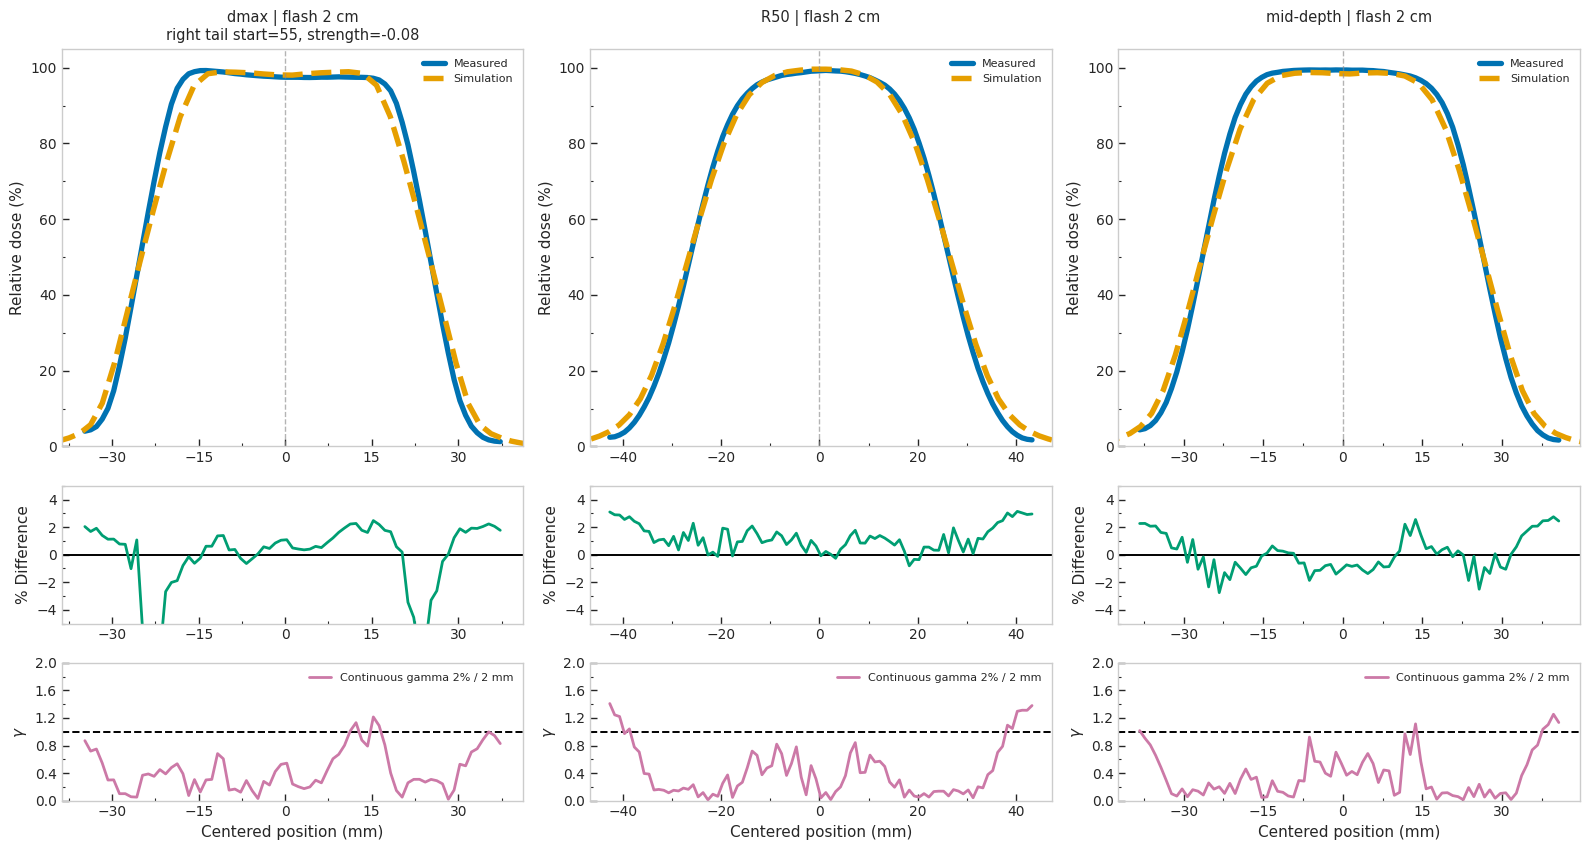

In [43]:
# ============================================================
# POST-CELL:
# Fine tune ONLY the RIGHT TAIL of the DMAX SIMULATION profile
# ------------------------------------------------------------
# Run this AFTER your big cell.
#
# This cell:
#   - uses profile_diff_gamma_results from your big cell
#   - changes ONLY dmax simulation right-tail x positions
#   - does NOT change measured data
#   - does NOT change simulation dose values
#   - recomputes dmax % difference and gamma
#   - replots dmax, R50, mid-depth together
#   - saves updated PNG, PDF, TIFF
#
# Use this when dmax right simulation tail does not match measured.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

# ------------------------------------------------------------
# Check needed previous results
# ------------------------------------------------------------
if "profile_diff_gamma_results" not in globals():
    raise RuntimeError(
        "profile_diff_gamma_results not found. "
        "Run your big profile/difference/gamma cell first."
    )

# ============================================================
# USER CONTROLS
# ============================================================

depth_keys = list(lateral_profile_depth_keys)

save_fig = True
save_dir = Path("build")

save_base_name = (
    f"profile_difference_gamma_dmax_right_tail_tuned_"
    f"{lateral_mode_select}_{lateral_applicator_select_cm}cm"
)

save_png = True
save_pdf = True
save_tiff = True

# ------------------------------------------------------------
# DMAX SIMULATION RIGHT-TAIL TUNING
# ------------------------------------------------------------
# This affects ONLY:
#   key == "dmax"
#   simulation curve
#   right side / right tail
#
# right_tail_start_mm:
#   x position where the right-tail correction starts.
#   For your dmax plot, try 45 to 65 mm.
#
# right_tail_strength:
#   negative -> pulls right tail inward / makes falloff earlier
#   positive -> pushes right tail outward / makes falloff later
#
# right_tail_power:
#   1.5 to 4.0
#   larger = correction focuses more strongly at far tail
#
# blend_width_mm:
#   smooth transition into the correction.
# ------------------------------------------------------------

apply_dmax_sim_right_tail_tune = False

dmax_sim_right_tail_start_mm = 55.0
dmax_sim_right_tail_strength = -0.08
dmax_sim_right_tail_power = 2.5
dmax_sim_right_tail_blend_width_mm = 20.0

# If simulation right tail is still too far right / too high:
# dmax_sim_right_tail_strength = -0.10
# dmax_sim_right_tail_strength = -0.12
#
# If correction is too strong:
# dmax_sim_right_tail_strength = -0.04
# dmax_sim_right_tail_strength = -0.02
#
# If correction starts too early:
# dmax_sim_right_tail_start_mm = 65.0
#
# If correction starts too late:
# dmax_sim_right_tail_start_mm = 45.0

# ------------------------------------------------------------
# Optional display smoothing after right-tail tuning
# ------------------------------------------------------------
smooth_dmax_sim_after_right_tail_tune = True
dmax_sim_after_right_tail_smooth_window_mm = 10.0

# ------------------------------------------------------------
# Difference and gamma settings
# ------------------------------------------------------------
diff_ylim = (-5, 5)
difference_label = "% Difference"

smooth_difference_for_display = True
difference_smooth_window_mm = 1.0

gamma_dose_percent = 2.0
gamma_dist_mm = 2.0
gamma_dose_mode = "global"
gamma_summary_dose_threshold_pct = 10.0

gamma_search_radius_mm = 4.0 * gamma_dist_mm
gamma_search_step_mm = 0.10

smooth_gamma_for_display = True
gamma_display_smooth_window_mm = 0.8

use_smoothed_gamma_for_summary = False

gamma_ylim = (0, 2.0)

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
x_padding_mm = 4.0
x_padding_fraction = 0.04

profile_ylim = (0, 105)

show_center_line = True
show_title_tuning_values = True
show_legend = True

plt.rcParams["axes.grid"] = False

# Color-blind friendly
color_meas = "#0072B2"
color_sim = "#E69F00"
color_diff = "#009E73"
color_gamma = "#CC79A7"

lw_meas = 3.8
lw_sim = 3.9
lw_secondary = 2.0
lw_ref = 1.4

pretty_names = {
    "dmax": "dmax",
    "r50": "R50",
    "middepth": "mid-depth",
}

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def interp_safe_local(x_src, y_src, x_tgt):
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_tgt = np.asarray(x_tgt, dtype=float)

    order = np.argsort(x_src)
    x_src = x_src[order]
    y_src = y_src[order]

    y = np.interp(x_tgt, x_src, y_src)
    y[(x_tgt < np.nanmin(x_src)) | (x_tgt > np.nanmax(x_src))] = np.nan

    return y


def moving_average_reflect_local(y, win_pts):
    y = np.asarray(y, dtype=float)

    if win_pts <= 1 or len(y) < 3:
        return y.copy()

    win_pts = int(win_pts)

    if win_pts % 2 == 0:
        win_pts += 1

    pad = win_pts // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")
    kernel = np.ones(win_pts) / win_pts

    return np.convolve(ypad, kernel, mode="valid")


def smooth_by_mm_local(x, y, window_mm):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if window_mm is None or window_mm <= 0 or len(x) < 3:
        return x.copy(), y.copy()

    dx = np.nanmedian(np.diff(np.sort(x)))

    if not np.isfinite(dx) or dx <= 0:
        return x.copy(), y.copy()

    win_pts = max(1, int(round(window_mm / dx)))

    return x.copy(), moving_average_reflect_local(y, win_pts)


def apply_right_tail_x_tune(
    sim_x,
    right_tail_start_mm=55.0,
    right_tail_strength=-0.08,
    right_tail_power=2.5,
    blend_width_mm=20.0,
):
    """
    Tune ONLY right-side simulation x positions.

    Dose values are unchanged.

    negative strength:
        pulls right tail inward, making falloff earlier.

    positive strength:
        pushes right tail outward, making falloff later.
    """
    sim_x = np.asarray(sim_x, dtype=float)
    x_new = sim_x.copy()

    # only right side
    right_region = sim_x > right_tail_start_mm

    if not np.any(right_region):
        return x_new

    # normalized distance into right tail
    u = (sim_x - right_tail_start_mm) / blend_width_mm
    u = np.clip(u, 0.0, None)

    # smooth ramp from 0 to 1
    ramp = 1.0 - np.exp(-(u ** right_tail_power))

    # amount of x-distance beyond tail start
    dx_tail = sim_x - right_tail_start_mm

    # x adjustment
    # negative strength pulls x inward
    delta_x = right_tail_strength * ramp * dx_tail

    x_new[right_region] = sim_x[right_region] + delta_x[right_region]

    return x_new


def continuous_gamma_1d_local(
    ref_x,
    ref_y,
    eval_x,
    eval_y,
    dose_percent=2.0,
    dist_mm=2.0,
    dose_mode="global",
    search_radius_mm=8.0,
    search_step_mm=0.10,
):
    ref_x = np.asarray(ref_x, dtype=float)
    ref_y = np.asarray(ref_y, dtype=float)

    eval_x = np.asarray(eval_x, dtype=float)
    eval_y = np.asarray(eval_y, dtype=float)

    order = np.argsort(eval_x)
    eval_x = eval_x[order]
    eval_y = eval_y[order]

    dx_values = np.arange(
        -search_radius_mm,
        search_radius_mm + 0.5 * search_step_mm,
        search_step_mm,
    )

    gamma_vals = np.full_like(ref_x, np.nan, dtype=float)

    for i, (xm, ym) in enumerate(zip(ref_x, ref_y)):
        x_samples = xm + dx_values

        sim_samples = np.interp(x_samples, eval_x, eval_y)
        outside = (x_samples < np.nanmin(eval_x)) | (x_samples > np.nanmax(eval_x))
        sim_samples[outside] = np.nan

        valid = np.isfinite(sim_samples)

        if not np.any(valid):
            continue

        dx = dx_values[valid]
        dy = sim_samples[valid] - ym

        if dose_mode.lower() == "local":
            dose_crit = dose_percent * max(abs(ym), 1e-6) / 100.0
        else:
            dose_crit = dose_percent

        gamma = np.sqrt((dx / dist_mm) ** 2 + (dy / dose_crit) ** 2)

        gamma_vals[i] = np.nanmin(gamma)

    return gamma_vals


def get_xlim_from_measured_local(meas_x, pad_mm=4.0, pad_frac=0.04):
    meas_x = np.asarray(meas_x, dtype=float)
    meas_x = meas_x[np.isfinite(meas_x)]

    xmin = float(np.nanmin(meas_x))
    xmax = float(np.nanmax(meas_x))
    width = xmax - xmin

    pad = max(pad_mm, pad_frac * width)

    return xmin - pad, xmax + pad


def style_axis_local(ax):
    ax.grid(False)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=5,
        width=1.0,
        labelsize=10,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=2.5,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


# ============================================================
# COPY RESULTS AND TUNE ONLY DMAX SIMULATION RIGHT TAIL
# ============================================================

dmax_right_tail_results = {}

for key in depth_keys:
    r_old = profile_diff_gamma_results[key]

    # shallow copy is enough for values, arrays copied below
    r = r_old.copy()

    r["meas_x"] = np.asarray(r_old["meas_x"], dtype=float).copy()
    r["meas_y"] = np.asarray(r_old["meas_y"], dtype=float).copy()
    r["meas_x_plot"] = np.asarray(r_old["meas_x_plot"], dtype=float).copy()
    r["meas_y_plot"] = np.asarray(r_old["meas_y_plot"], dtype=float).copy()

    r["sim_x"] = np.asarray(r_old["sim_x"], dtype=float).copy()
    r["sim_y"] = np.asarray(r_old["sim_y"], dtype=float).copy()
    r["sim_x_plot"] = np.asarray(r_old["sim_x_plot"], dtype=float).copy()
    r["sim_y_plot"] = np.asarray(r_old["sim_y_plot"], dtype=float).copy()

    # --------------------------------------------------------
    # Apply right-tail simulation x tuning ONLY for dmax
    # --------------------------------------------------------
    if key == "dmax" and apply_dmax_sim_right_tail_tune:
        sim_x_tuned_right = apply_right_tail_x_tune(
            sim_x=r["sim_x"],
            right_tail_start_mm=dmax_sim_right_tail_start_mm,
            right_tail_strength=dmax_sim_right_tail_strength,
            right_tail_power=dmax_sim_right_tail_power,
            blend_width_mm=dmax_sim_right_tail_blend_width_mm,
        )

        sim_y_tuned_right = r["sim_y"].copy()

        # Sort after x-warp
        order = np.argsort(sim_x_tuned_right)
        sim_x_tuned_right = sim_x_tuned_right[order]
        sim_y_tuned_right = sim_y_tuned_right[order]

        r["sim_x"] = sim_x_tuned_right
        r["sim_y"] = sim_y_tuned_right

        # Display version
        r["sim_x_plot"] = sim_x_tuned_right.copy()
        r["sim_y_plot"] = sim_y_tuned_right.copy()

        if smooth_dmax_sim_after_right_tail_tune:
            r["sim_x_plot"], r["sim_y_plot"] = smooth_by_mm_local(
                r["sim_x_plot"],
                r["sim_y_plot"],
                dmax_sim_after_right_tail_smooth_window_mm,
            )

        r["sim_y_plot"] = np.clip(r["sim_y_plot"], 0.0, None)

        # ----------------------------------------------------
        # Recompute dmax difference
        # ----------------------------------------------------
        sim_on_meas = interp_safe_local(
            r["sim_x"],
            r["sim_y"],
            r["meas_x"],
        )

        comp = pd.DataFrame({
            "x_mm": r["meas_x"],
            "measured_pct": r["meas_y"],
            "sim_pct": sim_on_meas,
        }).dropna()

        comp["diff_pctpts"] = comp["sim_pct"] - comp["measured_pct"]

        diff_x_plot = comp["x_mm"].values.copy()
        diff_y_plot = comp["diff_pctpts"].values.copy()

        if smooth_difference_for_display:
            diff_x_plot, diff_y_plot = smooth_by_mm_local(
                diff_x_plot,
                diff_y_plot,
                difference_smooth_window_mm,
            )

        # ----------------------------------------------------
        # Recompute dmax gamma
        # ----------------------------------------------------
        gamma_vals = continuous_gamma_1d_local(
            ref_x=comp["x_mm"].values,
            ref_y=comp["measured_pct"].values,
            eval_x=r["sim_x"],
            eval_y=r["sim_y"],
            dose_percent=gamma_dose_percent,
            dist_mm=gamma_dist_mm,
            dose_mode=gamma_dose_mode,
            search_radius_mm=gamma_search_radius_mm,
            search_step_mm=gamma_search_step_mm,
        )

        gamma_x_plot = comp["x_mm"].values.copy()
        gamma_y_plot = gamma_vals.copy()

        if smooth_gamma_for_display:
            gamma_x_plot, gamma_y_plot = smooth_by_mm_local(
                gamma_x_plot,
                gamma_y_plot,
                gamma_display_smooth_window_mm,
            )

        # ----------------------------------------------------
        # Recompute dmax metrics
        # ----------------------------------------------------
        diff_mask = comp["measured_pct"].values >= gamma_summary_dose_threshold_pct
        summary_gamma = gamma_y_plot if use_smoothed_gamma_for_summary else gamma_vals
        gamma_mask = diff_mask & np.isfinite(summary_gamma)

        if np.any(diff_mask):
            rmse = float(np.sqrt(np.mean(comp["diff_pctpts"].values[diff_mask] ** 2)))
            mae = float(np.mean(np.abs(comp["diff_pctpts"].values[diff_mask])))
            maxabs = float(np.max(np.abs(comp["diff_pctpts"].values[diff_mask])))
        else:
            rmse = np.nan
            mae = np.nan
            maxabs = np.nan

        if np.any(gamma_mask):
            gamma_pass = float(100.0 * np.mean(summary_gamma[gamma_mask] <= 1.0))
            gamma_mean = float(np.nanmean(summary_gamma[gamma_mask]))
            gamma_max = float(np.nanmax(summary_gamma[gamma_mask]))
        else:
            gamma_pass = np.nan
            gamma_mean = np.nan
            gamma_max = np.nan

        r["comp"] = comp
        r["diff_x_plot"] = diff_x_plot
        r["diff_y_plot"] = diff_y_plot
        r["gamma_x_plot"] = gamma_x_plot
        r["gamma_y_plot"] = gamma_y_plot
        r["gamma_raw"] = gamma_vals
        r["RMSE"] = rmse
        r["MAE"] = mae
        r["MaxAbs"] = maxabs
        r["Gamma Pass"] = gamma_pass
        r["Gamma Mean"] = gamma_mean
        r["Gamma Max"] = gamma_max

        r["dmax_right_tail_tune"] = {
            "right_tail_start_mm": dmax_sim_right_tail_start_mm,
            "right_tail_strength": dmax_sim_right_tail_strength,
            "right_tail_power": dmax_sim_right_tail_power,
            "right_tail_blend_width_mm": dmax_sim_right_tail_blend_width_mm,
        }

    dmax_right_tail_results[key] = r


# ============================================================
# SUMMARY
# ============================================================

summary_rows = []

for key in depth_keys:
    r = dmax_right_tail_results[key]

    summary_rows.append({
        "Depth": key,
        "RMSE": r.get("RMSE", np.nan),
        "MAE": r.get("MAE", np.nan),
        "MaxAbs": r.get("MaxAbs", np.nan),
        "Gamma Pass": r.get("Gamma Pass", np.nan),
        "Gamma Mean": r.get("Gamma Mean", np.nan),
        "Gamma Max": r.get("Gamma Max", np.nan),
    })

dmax_right_tail_summary_df = pd.DataFrame(summary_rows)

print("Dmax right-tail tuned summary:")
display(dmax_right_tail_summary_df.round(4))


# ============================================================
# PLOT UPDATED FIGURE
# ============================================================

fig, axes = plt.subplots(
    3,
    len(depth_keys),
    figsize=(16, 8.6),
    sharex=False,
    gridspec_kw={"height_ratios": [2.6, 0.9, 0.9]},
)

fig.subplots_adjust(wspace=0.25, hspace=0.12)

if len(depth_keys) == 1:
    axes = np.asarray(axes).reshape(3, 1)

for col, key in enumerate(depth_keys):
    r = dmax_right_tail_results[key]

    ax_top = axes[0, col]
    ax_mid = axes[1, col]
    ax_bot = axes[2, col]

    xmin, xmax = get_xlim_from_measured_local(
        r["meas_x"],
        pad_mm=x_padding_mm,
        pad_frac=x_padding_fraction,
    )

    # --------------------------------------------------------
    # Row 1: Profile
    # --------------------------------------------------------
    ax_top.plot(
        r["meas_x_plot"],
        r["meas_y_plot"],
        "-",
        lw=lw_meas,
        color=color_meas,
        label="Measured",
    )

    ax_top.plot(
        r["sim_x_plot"],
        r["sim_y_plot"],
        "--",
        lw=lw_sim,
        color=color_sim,
        label="Simulation",
    )

    if show_center_line:
        ax_top.axvline(
            0,
            color="0.55",
            lw=1.0,
            ls="--",
            alpha=0.65,
        )

    if key == "dmax":
        title_tail = (
            f"right tail start={dmax_sim_right_tail_start_mm:g}, "
            f"strength={dmax_sim_right_tail_strength:g}"
        )
    else:
        title_tail = ""

    ax_top.set_title(
        f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm\n"
        f"{title_tail}",
        fontsize=10.5,
    )

    ax_top.set_ylabel("Relative dose (%)", fontsize=11)
    ax_top.set_xlim(xmin, xmax)
    ax_top.set_ylim(*profile_ylim)
    ax_top.margins(y=0)

    if show_legend:
        ax_top.legend(frameon=False, fontsize=8, loc="best")

    style_axis_local(ax_top)
    ax_top.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # --------------------------------------------------------
    # Row 2: Difference
    # --------------------------------------------------------
    ax_mid.axhline(
        0,
        color="black",
        lw=lw_ref,
    )

    ax_mid.plot(
        r["diff_x_plot"],
        r["diff_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_diff,
    )

    ax_mid.set_ylabel(difference_label, fontsize=11)
    ax_mid.set_xlim(xmin, xmax)
    ax_mid.set_ylim(*diff_ylim)

    style_axis_local(ax_mid)
    ax_mid.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # --------------------------------------------------------
    # Row 3: Gamma
    # --------------------------------------------------------
    ax_bot.axhline(
        1.0,
        color="black",
        lw=lw_ref,
        ls="--",
    )

    ax_bot.plot(
        r["gamma_x_plot"],
        r["gamma_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_gamma,
        label=f"Continuous gamma {gamma_dose_percent:g}% / {gamma_dist_mm:g} mm",
    )

    ax_bot.set_xlabel("Centered position (mm)", fontsize=11)
    ax_bot.set_ylabel(r"$\gamma$", fontsize=11)
    ax_bot.set_xlim(xmin, xmax)
    ax_bot.set_ylim(*gamma_ylim)

    ax_bot.legend(frameon=False, fontsize=8, loc="best")

    style_axis_local(ax_bot)
    ax_bot.yaxis.set_major_locator(MaxNLocator(nbins=5))

plt.tight_layout()

# ============================================================
# SAVE UPDATED FIGURES
# ============================================================

if save_fig:
    save_dir.mkdir(parents=True, exist_ok=True)

    if save_png:
        png_path = save_dir / f"{save_base_name}.png"
        fig.savefig(
            png_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PNG:  {png_path}")

    if save_pdf:
        pdf_path = save_dir / f"{save_base_name}.pdf"
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PDF:  {pdf_path}")

    if save_tiff:
        tiff_path = save_dir / f"{save_base_name}.tiff"
        fig.savefig(
            tiff_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved TIFF: {tiff_path}")

plt.show()

Using source: edge_results
Profile + difference + continuous gamma summary:


,Depth,Flip,MeasBaseline,SimBaseline,x_scale,x_shift_mm,tail_strength,tail_power,RMSE,MAE,MaxAbs,Gamma Pass,Gamma Mean,Gamma Max
0,dmax,True,5.5208,1.1893,1.0,0.0,-0.06,3.0,3.0777,1.9291,10.8171,93.1034,0.3727,1.2276
1,r50,False,6.9813,1.0964,1.0,0.0,-0.05,3.0,1.0938,0.9317,2.2836,100.0000,0.2787,0.8418
2,middepth,False,6.7615,1.1243,1.0,0.0,-0.05,3.0,1.0932,0.8703,2.7565,98.4848,0.2738,1.1143


Saved PNG:  build/profile_difference_gamma_zero_baseline_flash_2cm.png
Saved PDF:  build/profile_difference_gamma_zero_baseline_flash_2cm.pdf
Saved TIFF: build/profile_difference_gamma_zero_baseline_flash_2cm.tiff


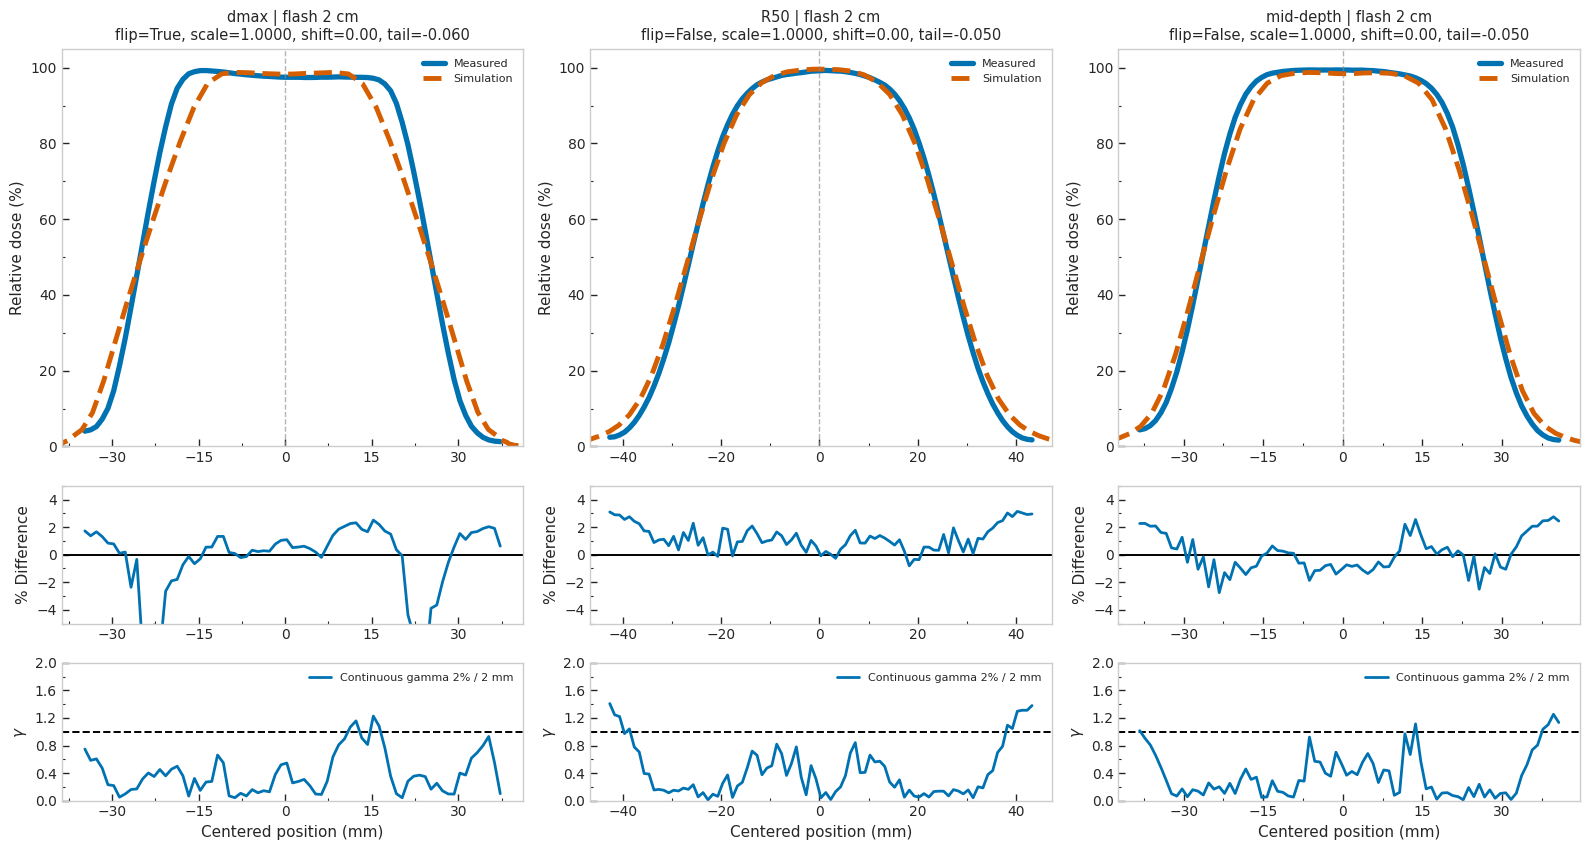

In [14]:
# ============================================================
# MEASURED vs SIMULATION + % DIFFERENCE + CONTINUOUS GAMMA
# WITH PER-DEPTH FLIP + TAIL TUNING + SMOOTHING + BASELINE TO ZERO
# ------------------------------------------------------------
# This cell plots:
#   Row 1: measured vs simulation profile
#   Row 2: % difference
#   Row 3: continuous/interpolated gamma
#
# NEW:
#   - baseline correction so measured tails touch x-axis / 0%
#   - optional baseline correction for simulation too
#   - profile starts from 0% after baseline subtraction
#
# Saves:
#   PNG, PDF, TIFF
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

# ------------------------------------------------------------
# Pick input source automatically
# ------------------------------------------------------------
if "manual_tuned_results" in globals():
    source_results = manual_tuned_results
    source_kind = "manual_tuned_results"
elif "flipped_tail_tuned_results" in globals():
    source_results = flipped_tail_tuned_results
    source_kind = "flipped_tail_tuned_results"
elif "tail_tuned_results" in globals():
    source_results = tail_tuned_results
    source_kind = "tail_tuned_results"
elif "profile_only_results" in globals():
    source_results = profile_only_results
    source_kind = "profile_only_results"
elif "final_clean_results" in globals():
    source_results = final_clean_results
    source_kind = "final_clean_results"
elif "edge_results" in globals():
    source_results = edge_results
    source_kind = "edge_results"
elif "final_results" in globals():
    source_results = final_results
    source_kind = "final_results"
else:
    raise RuntimeError(
        "No usable results found. Run your profile-building / edge-alignment cell first. "
        "Need one of: manual_tuned_results, flipped_tail_tuned_results, "
        "tail_tuned_results, profile_only_results, final_clean_results, edge_results, final_results."
    )

print(f"Using source: {source_kind}")

# ============================================================
# USER CONTROLS
# ============================================================

depth_keys = list(lateral_profile_depth_keys)

# ------------------------------------------------------------
# Save settings
# ------------------------------------------------------------
save_fig = True
save_dir = Path("build")

save_base_name = (
    f"profile_difference_gamma_zero_baseline_"
    f"{lateral_mode_select}_{lateral_applicator_select_cm}cm"
)

save_png = True
save_pdf = True
save_tiff = True

# ------------------------------------------------------------
# PER-DEPTH FLIP CONTROLS
# ------------------------------------------------------------
flip_simulation_x_by_depth = {
    "dmax": True,
    "r50": False,
    "middepth": False,
}

# ------------------------------------------------------------
# PER-DEPTH TAIL FINE-TUNING CONTROLS
# ------------------------------------------------------------
sim_x_tail_tune = {
    "dmax": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,
        "tail_strength": -0.06,
        "tail_power": 3.0,
    },
    "r50": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,
        "tail_strength": -0.05,
        "tail_power": 3.0,
    },
    "middepth": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,
        "tail_strength": -0.05,
        "tail_power": 3.0,
    },
}

# ------------------------------------------------------------
# BASELINE CORRECTION CONTROLS
# ------------------------------------------------------------
# This makes profile tails touch 0%.
#
# Method:
#   Use the low-dose tail region of each profile to estimate baseline,
#   subtract it, clip negative values to 0, then renormalize to 100%.
#
# baseline_edge_fraction:
#   fraction of points from each edge used to estimate baseline.
#   0.10 = use outer 10% left + outer 10% right.
#
# baseline_percentile:
#   percentile of edge values used as baseline.
#   5 or 10 is usually conservative.
# ------------------------------------------------------------

baseline_correct_measured = True
baseline_correct_simulation = True

baseline_edge_fraction = 0.10
baseline_percentile = 5.0

# If you want the very lowest point to become exactly 0, use:
# baseline_percentile = 0.0

# ------------------------------------------------------------
# PROFILE SMOOTHING CONTROLS
# ------------------------------------------------------------
smooth_measured_profile_for_display = True
smooth_sim_profile_for_display = True

# Your current value is 10 mm, which is strong smoothing.
measured_profile_smooth_window_mm = 10.0
sim_profile_smooth_window_mm = 10.0

# If False:
#   top profile is smoothed visually,
#   but % difference and gamma use baseline-corrected unsmoothed profiles.
#
# If True:
#   % difference and gamma use the smoothed curves too.
use_smoothed_profiles_for_difference_gamma = False

# ------------------------------------------------------------
# Difference controls
# ------------------------------------------------------------
diff_ylim = (-5, 5)
difference_label = "% Difference"

smooth_difference_for_display = True
difference_smooth_window_mm = 1.0

# ------------------------------------------------------------
# Continuous gamma controls
# ------------------------------------------------------------
gamma_dose_percent = 2.0
gamma_dist_mm = 2.0

gamma_dose_mode = "global"
gamma_summary_dose_threshold_pct = 10.0

gamma_search_radius_mm = 4.0 * gamma_dist_mm
gamma_search_step_mm = 0.10

smooth_gamma_for_display = True
gamma_display_smooth_window_mm = 0.8

use_smoothed_gamma_for_summary = False

gamma_ylim = (0, 2.0)

# ------------------------------------------------------------
# Plot controls
# ------------------------------------------------------------
x_padding_mm = 4.0
x_padding_fraction = 0.04

# Force y-axis to begin exactly at 0
profile_ylim = (0, 105)

show_center_line = True
show_title_tuning_values = True
show_legend = True

plt.rcParams["axes.grid"] = False

# Colors
color_meas = "#0072B2"
color_sim = "#D55E00"
color_diff = "#0072B2"
color_gamma = "#0072B2"

# Line thickness
lw_meas = 3.8
lw_sim = 3.5
lw_secondary = 2.0
lw_ref = 1.4

pretty_names = {
    "dmax": "dmax",
    "r50": "R50",
    "middepth": "mid-depth",
}

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_array_from_result(r, names):
    for name in names:
        if name in r:
            return np.asarray(r[name], dtype=float)

    raise KeyError(f"Could not find any of these keys: {names}")


def interp_safe(x_src, y_src, x_tgt):
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_tgt = np.asarray(x_tgt, dtype=float)

    order = np.argsort(x_src)
    x_src = x_src[order]
    y_src = y_src[order]

    y = np.interp(x_tgt, x_src, y_src)
    y[(x_tgt < np.nanmin(x_src)) | (x_tgt > np.nanmax(x_src))] = np.nan

    return y


def moving_average_reflect(y, win_pts):
    y = np.asarray(y, dtype=float)

    if win_pts <= 1 or len(y) < 3:
        return y.copy()

    win_pts = int(win_pts)

    if win_pts % 2 == 0:
        win_pts += 1

    pad = win_pts // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")
    kernel = np.ones(win_pts) / win_pts

    return np.convolve(ypad, kernel, mode="valid")


def smooth_by_mm(x, y, window_mm):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if window_mm is None or window_mm <= 0 or len(x) < 3:
        return x.copy(), y.copy()

    dx = np.nanmedian(np.diff(np.sort(x)))

    if not np.isfinite(dx) or dx <= 0:
        return x.copy(), y.copy()

    win_pts = max(1, int(round(window_mm / dx)))

    return x.copy(), moving_average_reflect(y, win_pts)


def baseline_to_zero(y, edge_fraction=0.10, percentile=5.0):
    """
    Subtract baseline estimated from profile edges,
    clip below zero, and renormalize to 100.
    """
    y = np.asarray(y, dtype=float)

    if len(y) < 4:
        return y.copy(), np.nan

    n_edge = max(1, int(round(edge_fraction * len(y))))

    edge_values = np.concatenate([
        y[:n_edge],
        y[-n_edge:],
    ])

    edge_values = edge_values[np.isfinite(edge_values)]

    if len(edge_values) == 0:
        return y.copy(), np.nan

    baseline = float(np.nanpercentile(edge_values, percentile))

    y0 = y - baseline
    y0 = np.clip(y0, 0.0, None)

    ymax = np.nanmax(y0)

    if np.isfinite(ymax) and ymax > 0:
        y0 = 100.0 * y0 / ymax

    return y0, baseline


def get_xlim_from_measured(meas_x, pad_mm=4.0, pad_frac=0.04):
    meas_x = np.asarray(meas_x, dtype=float)
    meas_x = meas_x[np.isfinite(meas_x)]

    xmin = float(np.nanmin(meas_x))
    xmax = float(np.nanmax(meas_x))
    width = xmax - xmin

    pad = max(pad_mm, pad_frac * width)

    return xmin - pad, xmax + pad


def apply_sim_flip(sim_x, flip=False):
    sim_x = np.asarray(sim_x, dtype=float)

    if flip:
        return -1.0 * sim_x

    return sim_x.copy()


def apply_tail_x_tune(sim_x, meas_x, tune):
    sim_x = np.asarray(sim_x, dtype=float)
    meas_x = np.asarray(meas_x, dtype=float)

    x_scale = float(tune.get("x_scale", 1.0))
    x_shift = float(tune.get("x_shift_mm", 0.0))
    tail_strength = float(tune.get("tail_strength", 0.0))
    tail_power = float(tune.get("tail_power", 3.0))

    x = x_scale * sim_x + x_shift

    finite_meas = meas_x[np.isfinite(meas_x)]
    if len(finite_meas) < 2:
        return x

    half_width = 0.5 * (np.nanmax(finite_meas) - np.nanmin(finite_meas))

    if not np.isfinite(half_width) or half_width <= 0:
        return x

    u = np.abs(x) / half_width
    u = np.clip(u, 0.0, 2.0)

    tail_factor = u ** tail_power

    x_tuned = x * (1.0 + tail_strength * tail_factor)

    return x_tuned


def continuous_gamma_1d(
    ref_x,
    ref_y,
    eval_x,
    eval_y,
    dose_percent=2.0,
    dist_mm=2.0,
    dose_mode="global",
    search_radius_mm=8.0,
    search_step_mm=0.10,
):
    ref_x = np.asarray(ref_x, dtype=float)
    ref_y = np.asarray(ref_y, dtype=float)

    eval_x = np.asarray(eval_x, dtype=float)
    eval_y = np.asarray(eval_y, dtype=float)

    order = np.argsort(eval_x)
    eval_x = eval_x[order]
    eval_y = eval_y[order]

    dx_values = np.arange(
        -search_radius_mm,
        search_radius_mm + 0.5 * search_step_mm,
        search_step_mm,
    )

    gamma_vals = np.full_like(ref_x, np.nan, dtype=float)

    for i, (xm, ym) in enumerate(zip(ref_x, ref_y)):
        x_samples = xm + dx_values

        sim_samples = np.interp(x_samples, eval_x, eval_y)
        outside = (x_samples < np.nanmin(eval_x)) | (x_samples > np.nanmax(eval_x))
        sim_samples[outside] = np.nan

        valid = np.isfinite(sim_samples)

        if not np.any(valid):
            continue

        dx = dx_values[valid]
        dy = sim_samples[valid] - ym

        if dose_mode.lower() == "local":
            dose_crit = dose_percent * max(abs(ym), 1e-6) / 100.0
        else:
            dose_crit = dose_percent

        gamma = np.sqrt((dx / dist_mm) ** 2 + (dy / dose_crit) ** 2)

        gamma_vals[i] = np.nanmin(gamma)

    return gamma_vals


def style_axis(ax):
    ax.grid(False)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=5,
        width=1.0,
        labelsize=10,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=2.5,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


# ============================================================
# BUILD FINAL PROFILE + DIFFERENCE + GAMMA RESULTS
# ============================================================

profile_diff_gamma_results = {}
summary_rows = []

for key in depth_keys:
    if key not in source_results:
        raise KeyError(
            f"Depth key '{key}' not found in {source_kind}. "
            f"Available keys: {list(source_results.keys())}"
        )

    r = source_results[key]

    meas_x = get_array_from_result(r, ["meas_x"])
    meas_y = get_array_from_result(r, ["meas_y"])

    sim_x_raw = get_array_from_result(
        r,
        ["sim_x_aligned", "sim_x_tuned", "sim_x"],
    )

    sim_y_raw = get_array_from_result(
        r,
        ["sim_y_tuned", "sim_y", "sim_y_aligned"],
    )

    # Sort measured
    mo = np.argsort(meas_x)
    meas_x = meas_x[mo]
    meas_y = meas_y[mo]

    # Sort simulation
    so = np.argsort(sim_x_raw)
    sim_x_raw = sim_x_raw[so]
    sim_y_raw = sim_y_raw[so]

    # --------------------------------------------------------
    # Baseline-correct measured so tails touch 0
    # --------------------------------------------------------
    if baseline_correct_measured:
        meas_y, meas_baseline = baseline_to_zero(
            meas_y,
            edge_fraction=baseline_edge_fraction,
            percentile=baseline_percentile,
        )
    else:
        meas_baseline = np.nan

    # --------------------------------------------------------
    # Per-depth flip simulation
    # --------------------------------------------------------
    flip_this_depth = bool(flip_simulation_x_by_depth.get(key, False))

    sim_x_flipped = apply_sim_flip(
        sim_x_raw,
        flip=flip_this_depth,
    )

    sim_y_flipped = sim_y_raw.copy()

    # Sort after flip
    fo = np.argsort(sim_x_flipped)
    sim_x_flipped = sim_x_flipped[fo]
    sim_y_flipped = sim_y_flipped[fo]

    # --------------------------------------------------------
    # Baseline-correct simulation too, optional
    # --------------------------------------------------------
    if baseline_correct_simulation:
        sim_y_flipped, sim_baseline = baseline_to_zero(
            sim_y_flipped,
            edge_fraction=baseline_edge_fraction,
            percentile=baseline_percentile,
        )
    else:
        sim_baseline = np.nan

    # --------------------------------------------------------
    # Per-depth tail tuning
    # --------------------------------------------------------
    tune = sim_x_tail_tune.get(
        key,
        {
            "x_scale": 1.0,
            "x_shift_mm": 0.0,
            "tail_strength": 0.0,
            "tail_power": 3.0,
        },
    )

    sim_x_tuned = apply_tail_x_tune(
        sim_x=sim_x_flipped,
        meas_x=meas_x,
        tune=tune,
    )

    sim_y_tuned = sim_y_flipped.copy()

    # Sort after tuning
    to = np.argsort(sim_x_tuned)
    sim_x_tuned = sim_x_tuned[to]
    sim_y_tuned = sim_y_tuned[to]

    # --------------------------------------------------------
    # Smooth profiles for display
    # --------------------------------------------------------
    meas_x_plot = meas_x.copy()
    meas_y_plot = meas_y.copy()

    sim_x_plot = sim_x_tuned.copy()
    sim_y_plot = sim_y_tuned.copy()

    if smooth_measured_profile_for_display:
        meas_x_plot, meas_y_plot = smooth_by_mm(
            meas_x_plot,
            meas_y_plot,
            measured_profile_smooth_window_mm,
        )

    if smooth_sim_profile_for_display:
        sim_x_plot, sim_y_plot = smooth_by_mm(
            sim_x_plot,
            sim_y_plot,
            sim_profile_smooth_window_mm,
        )

    # Force plotted tails to be nonnegative after smoothing
    meas_y_plot = np.clip(meas_y_plot, 0.0, None)
    sim_y_plot = np.clip(sim_y_plot, 0.0, None)

    # --------------------------------------------------------
    # Choose profiles for difference/gamma calculation
    # --------------------------------------------------------
    if use_smoothed_profiles_for_difference_gamma:
        meas_x_calc = meas_x_plot.copy()
        meas_y_calc = meas_y_plot.copy()
        sim_x_calc = sim_x_plot.copy()
        sim_y_calc = sim_y_plot.copy()
    else:
        meas_x_calc = meas_x.copy()
        meas_y_calc = meas_y.copy()
        sim_x_calc = sim_x_tuned.copy()
        sim_y_calc = sim_y_tuned.copy()

    # --------------------------------------------------------
    # Difference
    # --------------------------------------------------------
    sim_on_meas = interp_safe(
        sim_x_calc,
        sim_y_calc,
        meas_x_calc,
    )

    comp = pd.DataFrame({
        "x_mm": meas_x_calc,
        "measured_pct": meas_y_calc,
        "sim_pct": sim_on_meas,
    }).dropna()

    comp["diff_pctpts"] = comp["sim_pct"] - comp["measured_pct"]

    diff_x_plot = comp["x_mm"].values.copy()
    diff_y_plot = comp["diff_pctpts"].values.copy()

    if smooth_difference_for_display:
        diff_x_plot, diff_y_plot = smooth_by_mm(
            diff_x_plot,
            diff_y_plot,
            difference_smooth_window_mm,
        )

    # --------------------------------------------------------
    # Continuous gamma
    # --------------------------------------------------------
    gamma_vals = continuous_gamma_1d(
        ref_x=comp["x_mm"].values,
        ref_y=comp["measured_pct"].values,
        eval_x=sim_x_calc,
        eval_y=sim_y_calc,
        dose_percent=gamma_dose_percent,
        dist_mm=gamma_dist_mm,
        dose_mode=gamma_dose_mode,
        search_radius_mm=gamma_search_radius_mm,
        search_step_mm=gamma_search_step_mm,
    )

    gamma_x_plot = comp["x_mm"].values.copy()
    gamma_y_plot = gamma_vals.copy()

    if smooth_gamma_for_display:
        gamma_x_plot, gamma_y_plot = smooth_by_mm(
            gamma_x_plot,
            gamma_y_plot,
            gamma_display_smooth_window_mm,
        )

    # --------------------------------------------------------
    # Summary metrics
    # --------------------------------------------------------
    diff_mask = comp["measured_pct"].values >= gamma_summary_dose_threshold_pct

    summary_gamma = gamma_y_plot if use_smoothed_gamma_for_summary else gamma_vals
    gamma_mask = diff_mask & np.isfinite(summary_gamma)

    if np.any(diff_mask):
        rmse = float(np.sqrt(np.mean(comp["diff_pctpts"].values[diff_mask] ** 2)))
        mae = float(np.mean(np.abs(comp["diff_pctpts"].values[diff_mask])))
        maxabs = float(np.max(np.abs(comp["diff_pctpts"].values[diff_mask])))
    else:
        rmse = np.nan
        mae = np.nan
        maxabs = np.nan

    if np.any(gamma_mask):
        gamma_pass = float(100.0 * np.mean(summary_gamma[gamma_mask] <= 1.0))
        gamma_mean = float(np.nanmean(summary_gamma[gamma_mask]))
        gamma_max = float(np.nanmax(summary_gamma[gamma_mask]))
    else:
        gamma_pass = np.nan
        gamma_mean = np.nan
        gamma_max = np.nan

    profile_diff_gamma_results[key] = {
        "meas_x": meas_x,
        "meas_y": meas_y,
        "meas_x_plot": meas_x_plot,
        "meas_y_plot": meas_y_plot,
        "sim_x": sim_x_tuned,
        "sim_y": sim_y_tuned,
        "sim_x_plot": sim_x_plot,
        "sim_y_plot": sim_y_plot,
        "comp": comp,
        "diff_x_plot": diff_x_plot,
        "diff_y_plot": diff_y_plot,
        "gamma_x_plot": gamma_x_plot,
        "gamma_y_plot": gamma_y_plot,
        "gamma_raw": gamma_vals,
        "flip": flip_this_depth,
        "tune": tune,
        "meas_baseline": meas_baseline,
        "sim_baseline": sim_baseline,
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    }

    summary_rows.append({
        "Depth": key,
        "Flip": flip_this_depth,
        "MeasBaseline": meas_baseline,
        "SimBaseline": sim_baseline,
        "x_scale": tune["x_scale"],
        "x_shift_mm": tune["x_shift_mm"],
        "tail_strength": tune["tail_strength"],
        "tail_power": tune["tail_power"],
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    })

profile_diff_gamma_summary_df = pd.DataFrame(summary_rows)

print("Profile + difference + continuous gamma summary:")
display(profile_diff_gamma_summary_df.round(4))


# ============================================================
# PLOT: 3 ROWS x DEPTHS
# ============================================================

fig, axes = plt.subplots(
    3,
    len(depth_keys),
    figsize=(16, 8.6),
    sharex=False,
    gridspec_kw={"height_ratios": [2.6, 0.9, 0.9]},
)

fig.subplots_adjust(wspace=0.25, hspace=0.12)

if len(depth_keys) == 1:
    axes = np.asarray(axes).reshape(3, 1)

for col, key in enumerate(depth_keys):
    r = profile_diff_gamma_results[key]

    ax_top = axes[0, col]
    ax_mid = axes[1, col]
    ax_bot = axes[2, col]

    xmin, xmax = get_xlim_from_measured(
        r["meas_x"],
        pad_mm=x_padding_mm,
        pad_frac=x_padding_fraction,
    )

    # --------------------------------------------------------
    # Row 1: Baseline-corrected profile
    # --------------------------------------------------------
    ax_top.plot(
        r["meas_x_plot"],
        r["meas_y_plot"],
        "-",
        lw=lw_meas,
        color=color_meas,
        label="Measured",
    )

    ax_top.plot(
        r["sim_x_plot"],
        r["sim_y_plot"],
        "--",
        lw=lw_sim,
        color=color_sim,
        label="Simulation",
    )

    if show_center_line:
        ax_top.axvline(
            0,
            color="0.55",
            lw=1.0,
            ls="--",
            alpha=0.65,
        )

    t = r["tune"]

    if show_title_tuning_values:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm\n"
            f"flip={r['flip']}, scale={t['x_scale']:.4f}, "
            f"shift={t['x_shift_mm']:.2f}, tail={t['tail_strength']:.3f}",
            fontsize=10.5,
        )
    else:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm",
            fontsize=11,
        )

    ax_top.set_ylabel("Relative dose (%)", fontsize=11)
    ax_top.set_xlim(xmin, xmax)
    ax_top.set_ylim(*profile_ylim)

    # Force the bottom spine/ticks to be exactly at 0 visually
    ax_top.margins(y=0)

    if show_legend:
        ax_top.legend(frameon=False, fontsize=8, loc="best")

    style_axis(ax_top)
    ax_top.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # --------------------------------------------------------
    # Row 2: Difference
    # --------------------------------------------------------
    ax_mid.axhline(
        0,
        color="black",
        lw=lw_ref,
    )

    ax_mid.plot(
        r["diff_x_plot"],
        r["diff_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_diff,
    )

    ax_mid.set_ylabel(difference_label, fontsize=11)
    ax_mid.set_xlim(xmin, xmax)
    ax_mid.set_ylim(*diff_ylim)

    style_axis(ax_mid)
    ax_mid.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # --------------------------------------------------------
    # Row 3: Continuous gamma
    # --------------------------------------------------------
    ax_bot.axhline(
        1.0,
        color="black",
        lw=lw_ref,
        ls="--",
    )

    ax_bot.plot(
        r["gamma_x_plot"],
        r["gamma_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_gamma,
        label=f"Continuous gamma {gamma_dose_percent:g}% / {gamma_dist_mm:g} mm",
    )

    ax_bot.set_xlabel("Centered position (mm)", fontsize=11)
    ax_bot.set_ylabel(r"$\gamma$", fontsize=11)
    ax_bot.set_xlim(xmin, xmax)
    ax_bot.set_ylim(*gamma_ylim)

    ax_bot.legend(frameon=False, fontsize=8, loc="best")

    style_axis(ax_bot)
    ax_bot.yaxis.set_major_locator(MaxNLocator(nbins=5))

plt.tight_layout()

# ============================================================
# SAVE UPDATED FIGURES
# ============================================================

if save_fig:
    save_dir.mkdir(parents=True, exist_ok=True)

    if save_png:
        png_path = save_dir / f"{save_base_name}.png"
        fig.savefig(
            png_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PNG:  {png_path}")

    if save_pdf:
        pdf_path = save_dir / f"{save_base_name}.pdf"
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PDF:  {pdf_path}")

    if save_tiff:
        tiff_path = save_dir / f"{save_base_name}.tiff"
        fig.savefig(
            tiff_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved TIFF: {tiff_path}")

plt.show()

Saved PNG:  build/profile_difference_gamma_zero_baseline_dmax_left_smoothed_flash_2cm.png
Saved PDF:  build/profile_difference_gamma_zero_baseline_dmax_left_smoothed_flash_2cm.pdf
Saved TIFF: build/profile_difference_gamma_zero_baseline_dmax_left_smoothed_flash_2cm.tiff


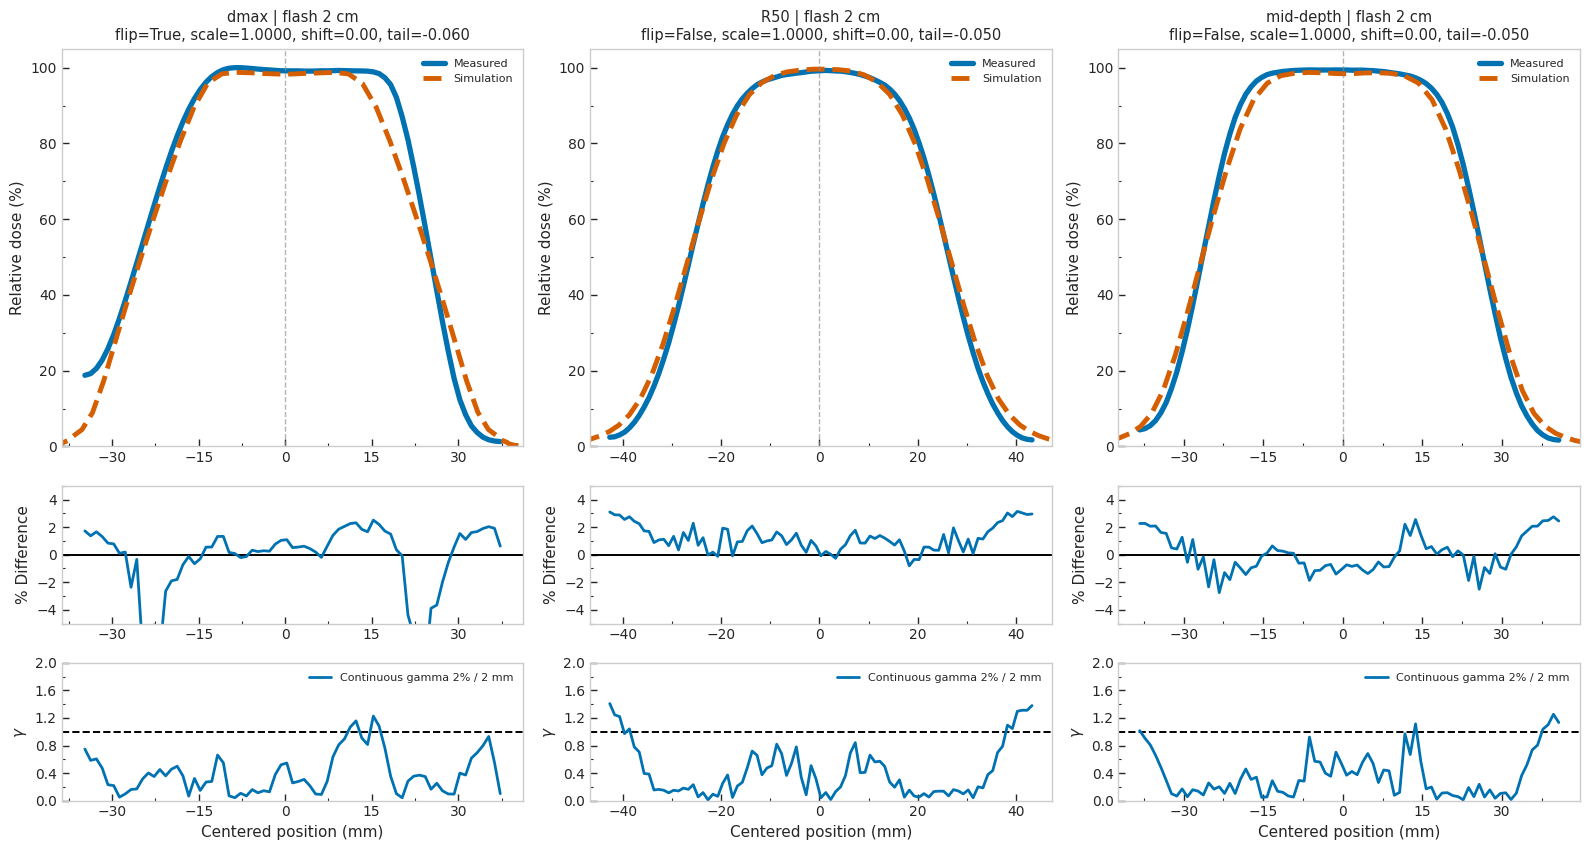

In [15]:
# ============================================================
# POST-PROCESS PLOT CELL:
# Smooth ONLY the LEFT SIDE of the dmax MEASURED profile
# ------------------------------------------------------------
# Run this AFTER your main plotting cell.
#
# This does NOT change:
#   - raw measured data
#   - simulation data
#   - % difference
#   - gamma
#   - metrics
#
# It only makes the plotted dmax measured curve smoother
# on the left side of the profile.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

# ------------------------------------------------------------
# Check needed results
# ------------------------------------------------------------
if "profile_diff_gamma_results" not in globals():
    raise RuntimeError(
        "profile_diff_gamma_results not found. "
        "Run your main profile/difference/gamma cell first."
    )

# ============================================================
# USER CONTROLS
# ============================================================

save_fig = True
save_dir = Path("build")

save_base_name = (
    f"profile_difference_gamma_zero_baseline_dmax_left_smoothed_"
    f"{lateral_mode_select}_{lateral_applicator_select_cm}cm"
)

save_png = True
save_pdf = True
save_tiff = True

depth_keys = list(lateral_profile_depth_keys)

# ------------------------------------------------------------
# DMAX LEFT-SIDE MEASURED SMOOTHING CONTROLS
# ------------------------------------------------------------
smooth_dmax_left_measured = True

# Smooth only measured dmax for x less than this value.
# Usually 0 means only the left half.
dmax_left_smooth_xmax_mm = 0.0

# Width of smoothing on dmax measured left side.
# Increase to make it less pointy.
# Try 8, 12, 15, 20.
dmax_left_smooth_window_mm = 18.0

# Blend zone avoids a visible kink where smoothed curve joins original.
# Larger = smoother transition.
dmax_left_blend_width_mm = 12.0

# Keep the measured curve normalized after smoothing.
renormalize_dmax_after_left_smoothing = True

# ------------------------------------------------------------
# Plot settings copied from your main style
# ------------------------------------------------------------
x_padding_mm = 4.0
x_padding_fraction = 0.04

profile_ylim = (0, 105)
diff_ylim = (-5, 5)
gamma_ylim = (0, 2.0)

show_center_line = True
show_title_tuning_values = True
show_legend = True

difference_label = "% Difference"

color_meas = "#0072B2"
color_sim = "#D55E00"
color_diff = "#0072B2"
color_gamma = "#0072B2"

lw_meas = 3.8
lw_sim = 3.5
lw_secondary = 2.0
lw_ref = 1.4

pretty_names = {
    "dmax": "dmax",
    "r50": "R50",
    "middepth": "mid-depth",
}

plt.rcParams["axes.grid"] = False

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def moving_average_reflect_local(y, win_pts):
    y = np.asarray(y, dtype=float)

    if win_pts <= 1 or len(y) < 3:
        return y.copy()

    win_pts = int(win_pts)

    if win_pts % 2 == 0:
        win_pts += 1

    pad = win_pts // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")
    kernel = np.ones(win_pts) / win_pts

    return np.convolve(ypad, kernel, mode="valid")


def smooth_by_mm_local(x, y, window_mm):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if window_mm is None or window_mm <= 0 or len(x) < 3:
        return y.copy()

    dx = np.nanmedian(np.diff(np.sort(x)))

    if not np.isfinite(dx) or dx <= 0:
        return y.copy()

    win_pts = max(1, int(round(window_mm / dx)))

    return moving_average_reflect_local(y, win_pts)


def smooth_left_side_only(
    x,
    y,
    left_xmax_mm=0.0,
    smooth_window_mm=18.0,
    blend_width_mm=12.0,
    renormalize=True,
):
    """
    Smooth only the left side of a profile with a soft blend back to original.

    left_xmax_mm:
        x-value up to which the left-side smoothing is active.

    blend_width_mm:
        transition width so the smoothed left side does not kink at the join.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    y_smooth_all = smooth_by_mm_local(
        x,
        y,
        smooth_window_mm,
    )

    # Weight = 1 on left side, gradually goes to 0 near boundary
    weight = np.zeros_like(x, dtype=float)

    full_smooth_region = x <= (left_xmax_mm - blend_width_mm)
    blend_region = (x > (left_xmax_mm - blend_width_mm)) & (x < left_xmax_mm)

    weight[full_smooth_region] = 1.0

    if np.any(blend_region):
        # Smooth cosine blend from 1 to 0
        t = (x[blend_region] - (left_xmax_mm - blend_width_mm)) / blend_width_mm
        weight[blend_region] = 0.5 * (1.0 + np.cos(np.pi * t))

    y_out = weight * y_smooth_all + (1.0 - weight) * y

    y_out = np.clip(y_out, 0.0, None)

    if renormalize:
        ymax = np.nanmax(y_out)
        if np.isfinite(ymax) and ymax > 0:
            y_out = 100.0 * y_out / ymax

    return y_out


def get_xlim_from_measured_local(meas_x, pad_mm=4.0, pad_frac=0.04):
    meas_x = np.asarray(meas_x, dtype=float)
    meas_x = meas_x[np.isfinite(meas_x)]

    xmin = float(np.nanmin(meas_x))
    xmax = float(np.nanmax(meas_x))
    width = xmax - xmin

    pad = max(pad_mm, pad_frac * width)

    return xmin - pad, xmax + pad


def style_axis_local(ax):
    ax.grid(False)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=5,
        width=1.0,
        labelsize=10,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=2.5,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


# ============================================================
# COPY RESULTS FOR DISPLAY ONLY
# ============================================================

display_results = {}

for key in depth_keys:
    r = profile_diff_gamma_results[key].copy()

    r["meas_x_plot_display"] = np.asarray(r["meas_x_plot"], dtype=float).copy()
    r["meas_y_plot_display"] = np.asarray(r["meas_y_plot"], dtype=float).copy()

    # Apply ONLY to dmax measured left side
    if key == "dmax" and smooth_dmax_left_measured:
        r["meas_y_plot_display"] = smooth_left_side_only(
            x=r["meas_x_plot_display"],
            y=r["meas_y_plot_display"],
            left_xmax_mm=dmax_left_smooth_xmax_mm,
            smooth_window_mm=dmax_left_smooth_window_mm,
            blend_width_mm=dmax_left_blend_width_mm,
            renormalize=renormalize_dmax_after_left_smoothing,
        )

    display_results[key] = r


# ============================================================
# RE-PLOT SAME FIGURE, BUT WITH SMOOTHER DMAX LEFT MEASURED SIDE
# ============================================================

fig, axes = plt.subplots(
    3,
    len(depth_keys),
    figsize=(16, 8.6),
    sharex=False,
    gridspec_kw={"height_ratios": [2.6, 0.9, 0.9]},
)

fig.subplots_adjust(wspace=0.25, hspace=0.12)

if len(depth_keys) == 1:
    axes = np.asarray(axes).reshape(3, 1)

for col, key in enumerate(depth_keys):
    r = display_results[key]

    ax_top = axes[0, col]
    ax_mid = axes[1, col]
    ax_bot = axes[2, col]

    xmin, xmax = get_xlim_from_measured_local(
        r["meas_x"],
        pad_mm=x_padding_mm,
        pad_frac=x_padding_fraction,
    )

    # --------------------------------------------------------
    # Row 1: Profile
    # --------------------------------------------------------
    ax_top.plot(
        r["meas_x_plot_display"],
        r["meas_y_plot_display"],
        "-",
        lw=lw_meas,
        color=color_meas,
        label="Measured",
    )

    ax_top.plot(
        r["sim_x_plot"],
        r["sim_y_plot"],
        "--",
        lw=lw_sim,
        color=color_sim,
        label="Simulation",
    )

    if show_center_line:
        ax_top.axvline(
            0,
            color="0.55",
            lw=1.0,
            ls="--",
            alpha=0.65,
        )

    t = r["tune"]

    if show_title_tuning_values:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm\n"
            f"flip={r['flip']}, scale={t['x_scale']:.4f}, "
            f"shift={t['x_shift_mm']:.2f}, tail={t['tail_strength']:.3f}",
            fontsize=10.5,
        )
    else:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm",
            fontsize=11,
        )

    ax_top.set_ylabel("Relative dose (%)", fontsize=11)
    ax_top.set_xlim(xmin, xmax)
    ax_top.set_ylim(*profile_ylim)
    ax_top.margins(y=0)

    if show_legend:
        ax_top.legend(frameon=False, fontsize=8, loc="best")

    style_axis_local(ax_top)
    ax_top.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # --------------------------------------------------------
    # Row 2: Difference
    # --------------------------------------------------------
    ax_mid.axhline(
        0,
        color="black",
        lw=lw_ref,
    )

    ax_mid.plot(
        r["diff_x_plot"],
        r["diff_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_diff,
    )

    ax_mid.set_ylabel(difference_label, fontsize=11)
    ax_mid.set_xlim(xmin, xmax)
    ax_mid.set_ylim(*diff_ylim)

    style_axis_local(ax_mid)
    ax_mid.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # --------------------------------------------------------
    # Row 3: Gamma
    # --------------------------------------------------------
    ax_bot.axhline(
        1.0,
        color="black",
        lw=lw_ref,
        ls="--",
    )

    ax_bot.plot(
        r["gamma_x_plot"],
        r["gamma_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_gamma,
        label=f"Continuous gamma {gamma_dose_percent:g}% / {gamma_dist_mm:g} mm",
    )

    ax_bot.set_xlabel("Centered position (mm)", fontsize=11)
    ax_bot.set_ylabel(r"$\gamma$", fontsize=11)
    ax_bot.set_xlim(xmin, xmax)
    ax_bot.set_ylim(*gamma_ylim)

    ax_bot.legend(frameon=False, fontsize=8, loc="best")

    style_axis_local(ax_bot)
    ax_bot.yaxis.set_major_locator(MaxNLocator(nbins=5))

plt.tight_layout()

# ============================================================
# SAVE UPDATED FIGURES
# ============================================================

if save_fig:
    save_dir.mkdir(parents=True, exist_ok=True)

    if save_png:
        png_path = save_dir / f"{save_base_name}.png"
        fig.savefig(
            png_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PNG:  {png_path}")

    if save_pdf:
        pdf_path = save_dir / f"{save_base_name}.pdf"
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PDF:  {pdf_path}")

    if save_tiff:
        tiff_path = save_dir / f"{save_base_name}.tiff"
        fig.savefig(
            tiff_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved TIFF: {tiff_path}")

plt.show()

Using source: edge_results
Profile + difference + continuous gamma summary:


,Depth,Flip,x_scale,x_shift_mm,tail_strength,tail_power,SmoothedForCalc,RMSE,MAE,MaxAbs,Gamma Pass,Gamma Mean,Gamma Max
0,dmax,True,1.0,0.0,0.02,3.0,False,1.8069,1.3452,5.0431,93.5484,0.3273,1.1603
1,r50,False,1.0,0.0,0.13,3.0,False,2.7950,2.1843,5.9105,100.0000,0.4297,0.9526
2,middepth,False,1.0,0.0,0.08,3.0,False,2.5375,1.8338,6.9077,98.6111,0.3501,1.0657


Saved PNG:  build/profile_difference_gamma_smoothed_flip_tail_flash_2cm.png
Saved PDF:  build/profile_difference_gamma_smoothed_flip_tail_flash_2cm.pdf
Saved TIFF: build/profile_difference_gamma_smoothed_flip_tail_flash_2cm.tiff


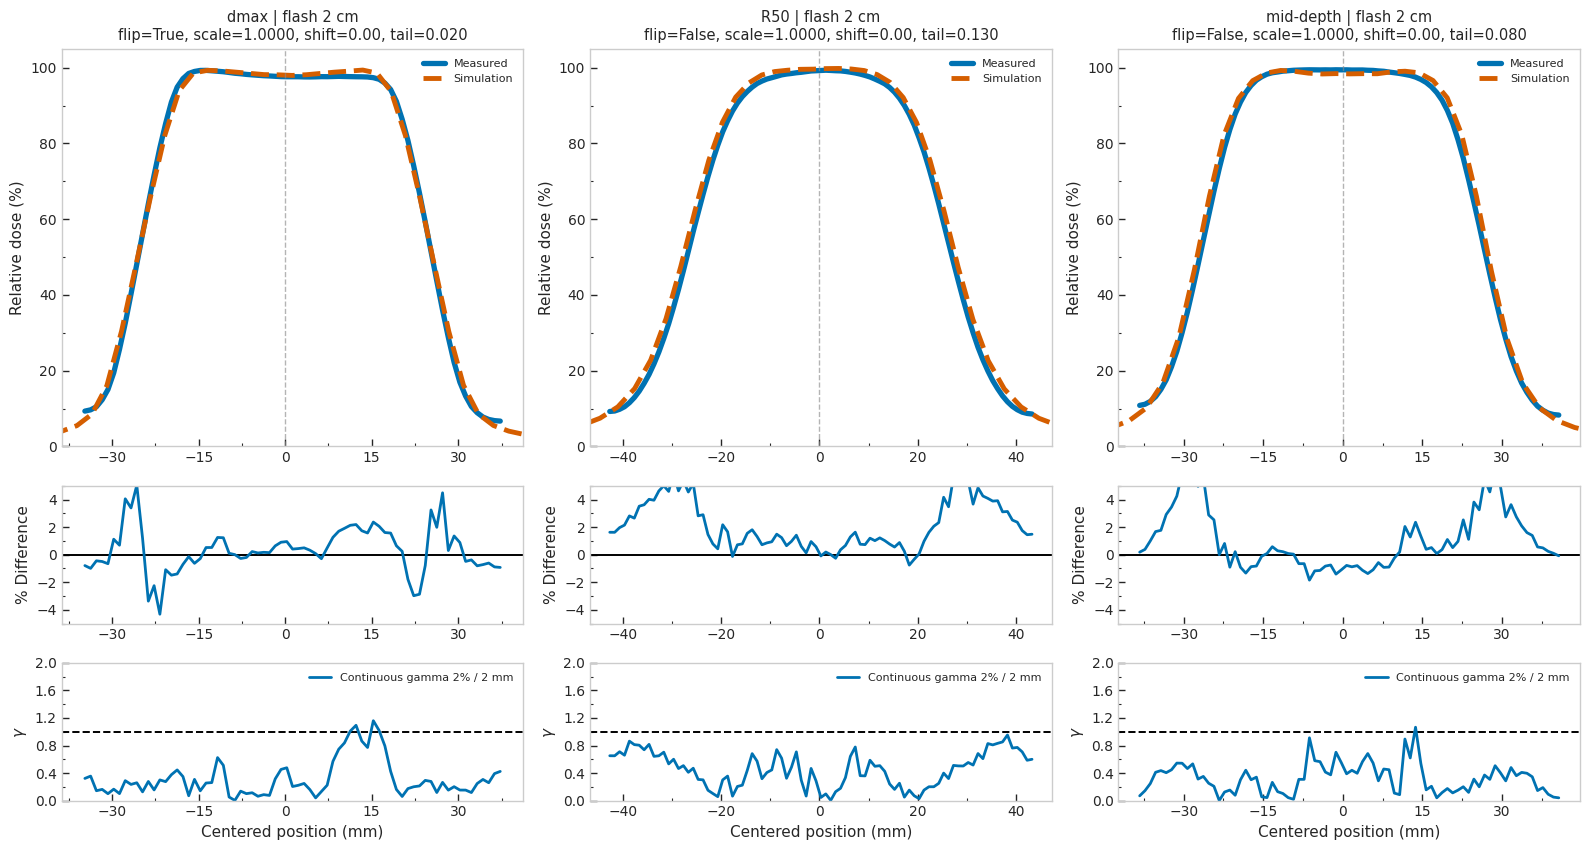

In [16]:
# ============================================================
# MEASURED vs SIMULATION + % DIFFERENCE + CONTINUOUS GAMMA
# WITH PER-DEPTH FLIP + TAIL TUNING + PROFILE SMOOTHING
# ------------------------------------------------------------
# This cell plots:
#   Row 1: measured vs simulation profile
#   Row 2: % difference
#   Row 3: continuous/interpolated gamma
#
# Features:
#   - per-depth simulation flip True/False
#   - per-depth x-scale, x-shift, tail tuning
#   - smooth measured profile for display
#   - smooth simulation profile for display
#   - adjustable line thickness
#   - less-sensitive continuous gamma
#   - saves PNG, PDF, and TIFF
#   - overwrites files every time you rerun the cell
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

# ------------------------------------------------------------
# Pick input source automatically
# ------------------------------------------------------------
if "manual_tuned_results" in globals():
    source_results = manual_tuned_results
    source_kind = "manual_tuned_results"
elif "flipped_tail_tuned_results" in globals():
    source_results = flipped_tail_tuned_results
    source_kind = "flipped_tail_tuned_results"
elif "tail_tuned_results" in globals():
    source_results = tail_tuned_results
    source_kind = "tail_tuned_results"
elif "profile_only_results" in globals():
    source_results = profile_only_results
    source_kind = "profile_only_results"
elif "final_clean_results" in globals():
    source_results = final_clean_results
    source_kind = "final_clean_results"
elif "edge_results" in globals():
    source_results = edge_results
    source_kind = "edge_results"
elif "final_results" in globals():
    source_results = final_results
    source_kind = "final_results"
else:
    raise RuntimeError(
        "No usable results found. Run your profile-building / edge-alignment cell first. "
        "Need one of: manual_tuned_results, flipped_tail_tuned_results, "
        "tail_tuned_results, profile_only_results, final_clean_results, edge_results, final_results."
    )

print(f"Using source: {source_kind}")

# ============================================================
# USER CONTROLS
# ============================================================

depth_keys = list(lateral_profile_depth_keys)

# ------------------------------------------------------------
# Save settings
# ------------------------------------------------------------
save_fig = True
save_dir = Path("build")

save_base_name = (
    f"profile_difference_gamma_smoothed_flip_tail_"
    f"{lateral_mode_select}_{lateral_applicator_select_cm}cm"
)

save_png = True
save_pdf = True
save_tiff = True

# ------------------------------------------------------------
# PER-DEPTH FLIP CONTROLS
# ------------------------------------------------------------
# True  = flip simulation left-right
# False = do not flip
# ------------------------------------------------------------

flip_simulation_x_by_depth = {
    "dmax": True,
    "r50": False,
    "middepth": False,
}

# ------------------------------------------------------------
# PER-DEPTH TAIL FINE-TUNING CONTROLS
# ------------------------------------------------------------
# Applied AFTER optional flipping.
# ------------------------------------------------------------

sim_x_tail_tune = {
    "dmax": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,
        "tail_strength": 0.02,
        "tail_power": 3.0,
    },
    "r50": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,
        "tail_strength": 0.13,
        "tail_power": 3.0,
    },
    "middepth": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,
        "tail_strength": 0.08,
        "tail_power": 3.0,
    },
}

# ------------------------------------------------------------
# PROFILE SMOOTHING CONTROLS
# ------------------------------------------------------------
# These smooth the plotted beam profiles.
#
# If use_smoothed_profiles_for_difference_gamma = False:
#   only the top profile curves are smoothed visually.
#   difference and gamma use raw tuned data.
#
# If use_smoothed_profiles_for_difference_gamma = True:
#   difference and gamma also use smoothed measured/sim profiles.
# ------------------------------------------------------------

smooth_measured_profile_for_display = True
smooth_sim_profile_for_display = True

measured_profile_smooth_window_mm = 10
sim_profile_smooth_window_mm = 10

use_smoothed_profiles_for_difference_gamma = False

# Optional: if you want more smoothing, try:
# measured_profile_smooth_window_mm = 1.5
# sim_profile_smooth_window_mm = 1.5

# ------------------------------------------------------------
# Difference controls
# ------------------------------------------------------------
diff_ylim = (-5, 5)
difference_label = "% Difference"

smooth_difference_for_display = True
difference_smooth_window_mm = 1.0

# ------------------------------------------------------------
# Continuous gamma controls
# ------------------------------------------------------------
gamma_dose_percent = 2.0
gamma_dist_mm = 2.0

# Softer exploratory option:
# gamma_dose_percent = 3.0
# gamma_dist_mm = 3.0

gamma_dose_mode = "global"
gamma_summary_dose_threshold_pct = 10.0

gamma_search_radius_mm = 4.0 * gamma_dist_mm
gamma_search_step_mm = 0.10

smooth_gamma_for_display = True
gamma_display_smooth_window_mm = 0.8

use_smoothed_gamma_for_summary = False

gamma_ylim = (0, 2.0)

# ------------------------------------------------------------
# Plot controls
# ------------------------------------------------------------
x_padding_mm = 4.0
x_padding_fraction = 0.04

profile_ylim = (0, 105)

show_center_line = True
show_title_tuning_values = True
show_legend = True

plt.rcParams["axes.grid"] = False

# ------------------------------------------------------------
# COLORS
# ------------------------------------------------------------
color_meas = "#0072B2"
color_sim = "#D55E00"
color_diff = "#0072B2"
color_gamma = "#0072B2"

# ------------------------------------------------------------
# LINE THICKNESS CONTROLS
# ------------------------------------------------------------
# Increase/decrease these if you want thicker/thinner curves.
# ------------------------------------------------------------
lw_meas = 3.8
lw_sim = 3.5
lw_secondary = 2.0
lw_ref = 1.4

pretty_names = {
    "dmax": "dmax",
    "r50": "R50",
    "middepth": "mid-depth",
}

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_array_from_result(r, names):
    for name in names:
        if name in r:
            return np.asarray(r[name], dtype=float)

    raise KeyError(f"Could not find any of these keys: {names}")


def interp_safe(x_src, y_src, x_tgt):
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_tgt = np.asarray(x_tgt, dtype=float)

    order = np.argsort(x_src)
    x_src = x_src[order]
    y_src = y_src[order]

    y = np.interp(x_tgt, x_src, y_src)
    y[(x_tgt < np.nanmin(x_src)) | (x_tgt > np.nanmax(x_src))] = np.nan

    return y


def moving_average_reflect(y, win_pts):
    y = np.asarray(y, dtype=float)

    if win_pts <= 1 or len(y) < 3:
        return y.copy()

    win_pts = int(win_pts)

    if win_pts % 2 == 0:
        win_pts += 1

    pad = win_pts // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")
    kernel = np.ones(win_pts) / win_pts

    return np.convolve(ypad, kernel, mode="valid")


def smooth_by_mm(x, y, window_mm):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if window_mm is None or window_mm <= 0 or len(x) < 3:
        return x.copy(), y.copy()

    dx = np.nanmedian(np.diff(np.sort(x)))

    if not np.isfinite(dx) or dx <= 0:
        return x.copy(), y.copy()

    win_pts = max(1, int(round(window_mm / dx)))

    return x.copy(), moving_average_reflect(y, win_pts)


def get_xlim_from_measured(meas_x, pad_mm=4.0, pad_frac=0.04):
    meas_x = np.asarray(meas_x, dtype=float)
    meas_x = meas_x[np.isfinite(meas_x)]

    xmin = float(np.nanmin(meas_x))
    xmax = float(np.nanmax(meas_x))
    width = xmax - xmin

    pad = max(pad_mm, pad_frac * width)

    return xmin - pad, xmax + pad


def apply_sim_flip(sim_x, flip=False):
    sim_x = np.asarray(sim_x, dtype=float)

    if flip:
        return -1.0 * sim_x

    return sim_x.copy()


def apply_tail_x_tune(sim_x, meas_x, tune):
    """
    Apply x-scale, x-shift, and tail-focused stretch/compression.
    Dose values are NOT changed.
    """
    sim_x = np.asarray(sim_x, dtype=float)
    meas_x = np.asarray(meas_x, dtype=float)

    x_scale = float(tune.get("x_scale", 1.0))
    x_shift = float(tune.get("x_shift_mm", 0.0))
    tail_strength = float(tune.get("tail_strength", 0.0))
    tail_power = float(tune.get("tail_power", 3.0))

    x = x_scale * sim_x + x_shift

    finite_meas = meas_x[np.isfinite(meas_x)]
    if len(finite_meas) < 2:
        return x

    half_width = 0.5 * (np.nanmax(finite_meas) - np.nanmin(finite_meas))

    if not np.isfinite(half_width) or half_width <= 0:
        return x

    u = np.abs(x) / half_width
    u = np.clip(u, 0.0, 2.0)

    tail_factor = u ** tail_power

    x_tuned = x * (1.0 + tail_strength * tail_factor)

    return x_tuned


def continuous_gamma_1d(
    ref_x,
    ref_y,
    eval_x,
    eval_y,
    dose_percent=2.0,
    dist_mm=2.0,
    dose_mode="global",
    search_radius_mm=8.0,
    search_step_mm=0.10,
):
    """
    Continuous/interpolated 1D gamma.
    Less sensitive than point-to-point gamma because it searches
    local interpolated simulation values around each measured point.
    """
    ref_x = np.asarray(ref_x, dtype=float)
    ref_y = np.asarray(ref_y, dtype=float)

    eval_x = np.asarray(eval_x, dtype=float)
    eval_y = np.asarray(eval_y, dtype=float)

    order = np.argsort(eval_x)
    eval_x = eval_x[order]
    eval_y = eval_y[order]

    dx_values = np.arange(
        -search_radius_mm,
        search_radius_mm + 0.5 * search_step_mm,
        search_step_mm,
    )

    gamma_vals = np.full_like(ref_x, np.nan, dtype=float)

    for i, (xm, ym) in enumerate(zip(ref_x, ref_y)):
        x_samples = xm + dx_values

        sim_samples = np.interp(x_samples, eval_x, eval_y)
        outside = (x_samples < np.nanmin(eval_x)) | (x_samples > np.nanmax(eval_x))
        sim_samples[outside] = np.nan

        valid = np.isfinite(sim_samples)

        if not np.any(valid):
            continue

        dx = dx_values[valid]
        dy = sim_samples[valid] - ym

        if dose_mode.lower() == "local":
            dose_crit = dose_percent * max(abs(ym), 1e-6) / 100.0
        else:
            dose_crit = dose_percent

        gamma = np.sqrt((dx / dist_mm) ** 2 + (dy / dose_crit) ** 2)

        gamma_vals[i] = np.nanmin(gamma)

    return gamma_vals


def style_axis(ax):
    ax.grid(False)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=5,
        width=1.0,
        labelsize=10,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=2.5,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


# ============================================================
# BUILD FINAL PROFILE + DIFFERENCE + GAMMA RESULTS
# ============================================================

profile_diff_gamma_results = {}
summary_rows = []

for key in depth_keys:
    if key not in source_results:
        raise KeyError(
            f"Depth key '{key}' not found in {source_kind}. "
            f"Available keys: {list(source_results.keys())}"
        )

    r = source_results[key]

    meas_x = get_array_from_result(r, ["meas_x"])
    meas_y = get_array_from_result(r, ["meas_y"])

    sim_x_raw = get_array_from_result(
        r,
        ["sim_x_aligned", "sim_x_tuned", "sim_x"],
    )

    sim_y_raw = get_array_from_result(
        r,
        ["sim_y_tuned", "sim_y", "sim_y_aligned"],
    )

    # Sort measured
    mo = np.argsort(meas_x)
    meas_x = meas_x[mo]
    meas_y = meas_y[mo]

    # Sort simulation
    so = np.argsort(sim_x_raw)
    sim_x_raw = sim_x_raw[so]
    sim_y_raw = sim_y_raw[so]

    # --------------------------------------------------------
    # Per-depth flip
    # --------------------------------------------------------
    flip_this_depth = bool(flip_simulation_x_by_depth.get(key, False))

    sim_x_flipped = apply_sim_flip(
        sim_x_raw,
        flip=flip_this_depth,
    )

    sim_y_flipped = sim_y_raw.copy()

    # Sort after flip
    fo = np.argsort(sim_x_flipped)
    sim_x_flipped = sim_x_flipped[fo]
    sim_y_flipped = sim_y_flipped[fo]

    # --------------------------------------------------------
    # Per-depth tail tuning
    # --------------------------------------------------------
    tune = sim_x_tail_tune.get(
        key,
        {
            "x_scale": 1.0,
            "x_shift_mm": 0.0,
            "tail_strength": 0.0,
            "tail_power": 3.0,
        },
    )

    sim_x_tuned = apply_tail_x_tune(
        sim_x=sim_x_flipped,
        meas_x=meas_x,
        tune=tune,
    )

    sim_y_tuned = sim_y_flipped.copy()

    # Sort after tuning
    to = np.argsort(sim_x_tuned)
    sim_x_tuned = sim_x_tuned[to]
    sim_y_tuned = sim_y_tuned[to]

    # --------------------------------------------------------
    # Smooth profiles for display
    # --------------------------------------------------------
    meas_x_plot = meas_x.copy()
    meas_y_plot = meas_y.copy()

    sim_x_plot = sim_x_tuned.copy()
    sim_y_plot = sim_y_tuned.copy()

    if smooth_measured_profile_for_display:
        meas_x_plot, meas_y_plot = smooth_by_mm(
            meas_x_plot,
            meas_y_plot,
            measured_profile_smooth_window_mm,
        )

    if smooth_sim_profile_for_display:
        sim_x_plot, sim_y_plot = smooth_by_mm(
            sim_x_plot,
            sim_y_plot,
            sim_profile_smooth_window_mm,
        )

    # --------------------------------------------------------
    # Choose profiles for difference/gamma calculation
    # --------------------------------------------------------
    if use_smoothed_profiles_for_difference_gamma:
        meas_x_calc = meas_x_plot.copy()
        meas_y_calc = meas_y_plot.copy()
        sim_x_calc = sim_x_plot.copy()
        sim_y_calc = sim_y_plot.copy()
    else:
        meas_x_calc = meas_x.copy()
        meas_y_calc = meas_y.copy()
        sim_x_calc = sim_x_tuned.copy()
        sim_y_calc = sim_y_tuned.copy()

    # --------------------------------------------------------
    # Difference on measured grid
    # --------------------------------------------------------
    sim_on_meas = interp_safe(
        sim_x_calc,
        sim_y_calc,
        meas_x_calc,
    )

    comp = pd.DataFrame({
        "x_mm": meas_x_calc,
        "measured_pct": meas_y_calc,
        "sim_pct": sim_on_meas,
    }).dropna()

    comp["diff_pctpts"] = comp["sim_pct"] - comp["measured_pct"]

    diff_x_plot = comp["x_mm"].values.copy()
    diff_y_plot = comp["diff_pctpts"].values.copy()

    if smooth_difference_for_display:
        diff_x_plot, diff_y_plot = smooth_by_mm(
            diff_x_plot,
            diff_y_plot,
            difference_smooth_window_mm,
        )

    # --------------------------------------------------------
    # Continuous gamma
    # --------------------------------------------------------
    gamma_vals = continuous_gamma_1d(
        ref_x=comp["x_mm"].values,
        ref_y=comp["measured_pct"].values,
        eval_x=sim_x_calc,
        eval_y=sim_y_calc,
        dose_percent=gamma_dose_percent,
        dist_mm=gamma_dist_mm,
        dose_mode=gamma_dose_mode,
        search_radius_mm=gamma_search_radius_mm,
        search_step_mm=gamma_search_step_mm,
    )

    gamma_x_plot = comp["x_mm"].values.copy()
    gamma_y_plot = gamma_vals.copy()

    if smooth_gamma_for_display:
        gamma_x_plot, gamma_y_plot = smooth_by_mm(
            gamma_x_plot,
            gamma_y_plot,
            gamma_display_smooth_window_mm,
        )

    # --------------------------------------------------------
    # Summary metrics
    # --------------------------------------------------------
    diff_mask = comp["measured_pct"].values >= gamma_summary_dose_threshold_pct

    summary_gamma = gamma_y_plot if use_smoothed_gamma_for_summary else gamma_vals
    gamma_mask = diff_mask & np.isfinite(summary_gamma)

    if np.any(diff_mask):
        rmse = float(np.sqrt(np.mean(comp["diff_pctpts"].values[diff_mask] ** 2)))
        mae = float(np.mean(np.abs(comp["diff_pctpts"].values[diff_mask])))
        maxabs = float(np.max(np.abs(comp["diff_pctpts"].values[diff_mask])))
    else:
        rmse = np.nan
        mae = np.nan
        maxabs = np.nan

    if np.any(gamma_mask):
        gamma_pass = float(100.0 * np.mean(summary_gamma[gamma_mask] <= 1.0))
        gamma_mean = float(np.nanmean(summary_gamma[gamma_mask]))
        gamma_max = float(np.nanmax(summary_gamma[gamma_mask]))
    else:
        gamma_pass = np.nan
        gamma_mean = np.nan
        gamma_max = np.nan

    profile_diff_gamma_results[key] = {
        "meas_x": meas_x,
        "meas_y": meas_y,
        "meas_x_plot": meas_x_plot,
        "meas_y_plot": meas_y_plot,
        "sim_x_raw": sim_x_raw,
        "sim_y_raw": sim_y_raw,
        "sim_x": sim_x_tuned,
        "sim_y": sim_y_tuned,
        "sim_x_plot": sim_x_plot,
        "sim_y_plot": sim_y_plot,
        "comp": comp,
        "diff_x_plot": diff_x_plot,
        "diff_y_plot": diff_y_plot,
        "gamma_x_plot": gamma_x_plot,
        "gamma_y_plot": gamma_y_plot,
        "gamma_raw": gamma_vals,
        "flip": flip_this_depth,
        "tune": tune,
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    }

    summary_rows.append({
        "Depth": key,
        "Flip": flip_this_depth,
        "x_scale": tune["x_scale"],
        "x_shift_mm": tune["x_shift_mm"],
        "tail_strength": tune["tail_strength"],
        "tail_power": tune["tail_power"],
        "SmoothedForCalc": use_smoothed_profiles_for_difference_gamma,
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    })

profile_diff_gamma_summary_df = pd.DataFrame(summary_rows)

print("Profile + difference + continuous gamma summary:")
display(profile_diff_gamma_summary_df.round(4))


# ============================================================
# PLOT: 3 ROWS x DEPTHS
# ============================================================

fig, axes = plt.subplots(
    3,
    len(depth_keys),
    figsize=(16, 8.6),
    sharex=False,
    gridspec_kw={"height_ratios": [2.6, 0.9, 0.9]},
)

fig.subplots_adjust(wspace=0.25, hspace=0.12)

if len(depth_keys) == 1:
    axes = np.asarray(axes).reshape(3, 1)

for col, key in enumerate(depth_keys):
    r = profile_diff_gamma_results[key]

    ax_top = axes[0, col]
    ax_mid = axes[1, col]
    ax_bot = axes[2, col]

    xmin, xmax = get_xlim_from_measured(
        r["meas_x"],
        pad_mm=x_padding_mm,
        pad_frac=x_padding_fraction,
    )

    # --------------------------------------------------------
    # Row 1: Smoothed profile display
    # --------------------------------------------------------
    ax_top.plot(
        r["meas_x_plot"],
        r["meas_y_plot"],
        "-",
        lw=lw_meas,
        color=color_meas,
        label="Measured",
    )

    ax_top.plot(
        r["sim_x_plot"],
        r["sim_y_plot"],
        "--",
        lw=lw_sim,
        color=color_sim,
        label="Simulation",
    )

    if show_center_line:
        ax_top.axvline(
            0,
            color="0.55",
            lw=1.0,
            ls="--",
            alpha=0.65,
        )

    t = r["tune"]

    if show_title_tuning_values:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm\n"
            f"flip={r['flip']}, scale={t['x_scale']:.4f}, "
            f"shift={t['x_shift_mm']:.2f}, tail={t['tail_strength']:.3f}",
            fontsize=10.5,
        )
    else:
        ax_top.set_title(
            f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm",
            fontsize=11,
        )

    ax_top.set_ylabel("Relative dose (%)", fontsize=11)
    ax_top.set_xlim(xmin, xmax)
    ax_top.set_ylim(*profile_ylim)

    if show_legend:
        ax_top.legend(frameon=False, fontsize=8, loc="best")

    style_axis(ax_top)
    ax_top.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # --------------------------------------------------------
    # Row 2: Difference
    # --------------------------------------------------------
    ax_mid.axhline(
        0,
        color="black",
        lw=lw_ref,
    )

    ax_mid.plot(
        r["diff_x_plot"],
        r["diff_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_diff,
    )

    ax_mid.set_ylabel(difference_label, fontsize=11)
    ax_mid.set_xlim(xmin, xmax)
    ax_mid.set_ylim(*diff_ylim)

    style_axis(ax_mid)
    ax_mid.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # --------------------------------------------------------
    # Row 3: Continuous gamma
    # --------------------------------------------------------
    ax_bot.axhline(
        1.0,
        color="black",
        lw=lw_ref,
        ls="--",
    )

    ax_bot.plot(
        r["gamma_x_plot"],
        r["gamma_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_gamma,
        label=f"Continuous gamma {gamma_dose_percent:g}% / {gamma_dist_mm:g} mm",
    )

    ax_bot.set_xlabel("Centered position (mm)", fontsize=11)
    ax_bot.set_ylabel(r"$\gamma$", fontsize=11)
    ax_bot.set_xlim(xmin, xmax)
    ax_bot.set_ylim(*gamma_ylim)

    ax_bot.legend(frameon=False, fontsize=8, loc="best")

    style_axis(ax_bot)
    ax_bot.yaxis.set_major_locator(MaxNLocator(nbins=5))

plt.tight_layout()

# ============================================================
# SAVE UPDATED FIGURES
# ============================================================

if save_fig:
    save_dir.mkdir(parents=True, exist_ok=True)

    if save_png:
        png_path = save_dir / f"{save_base_name}.png"
        fig.savefig(
            png_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PNG:  {png_path}")

    if save_pdf:
        pdf_path = save_dir / f"{save_base_name}.pdf"
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved PDF:  {pdf_path}")

    if save_tiff:
        tiff_path = save_dir / f"{save_base_name}.tiff"
        fig.savefig(
            tiff_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
        print(f"Saved TIFF: {tiff_path}")

plt.show()

Using source: edge_results
Tail-tuned continuous gamma metrics:


,Depth,x_scale,x_shift_mm,tail_strength,tail_power,RMSE,MAE,MaxAbs,Gamma Pass,Gamma Mean,Gamma Max
0,dmax,1.0,0.0,0.02,3.0,1.8494,1.3739,5.3537,95.1613,0.3390,1.1453
1,r50,1.0,0.0,0.08,3.0,1.7155,1.4192,3.8503,100.0000,0.3121,0.7776
2,middepth,1.0,0.0,0.08,3.0,2.5375,1.8338,6.9077,98.6111,0.3501,1.0657


Saved metrics: build/tail_tuned_metrics_flash_2cm.xlsx
Saved tail-tuned continuous-gamma figure: build/tail_tuned_continuous_gamma_flash_2cm.png


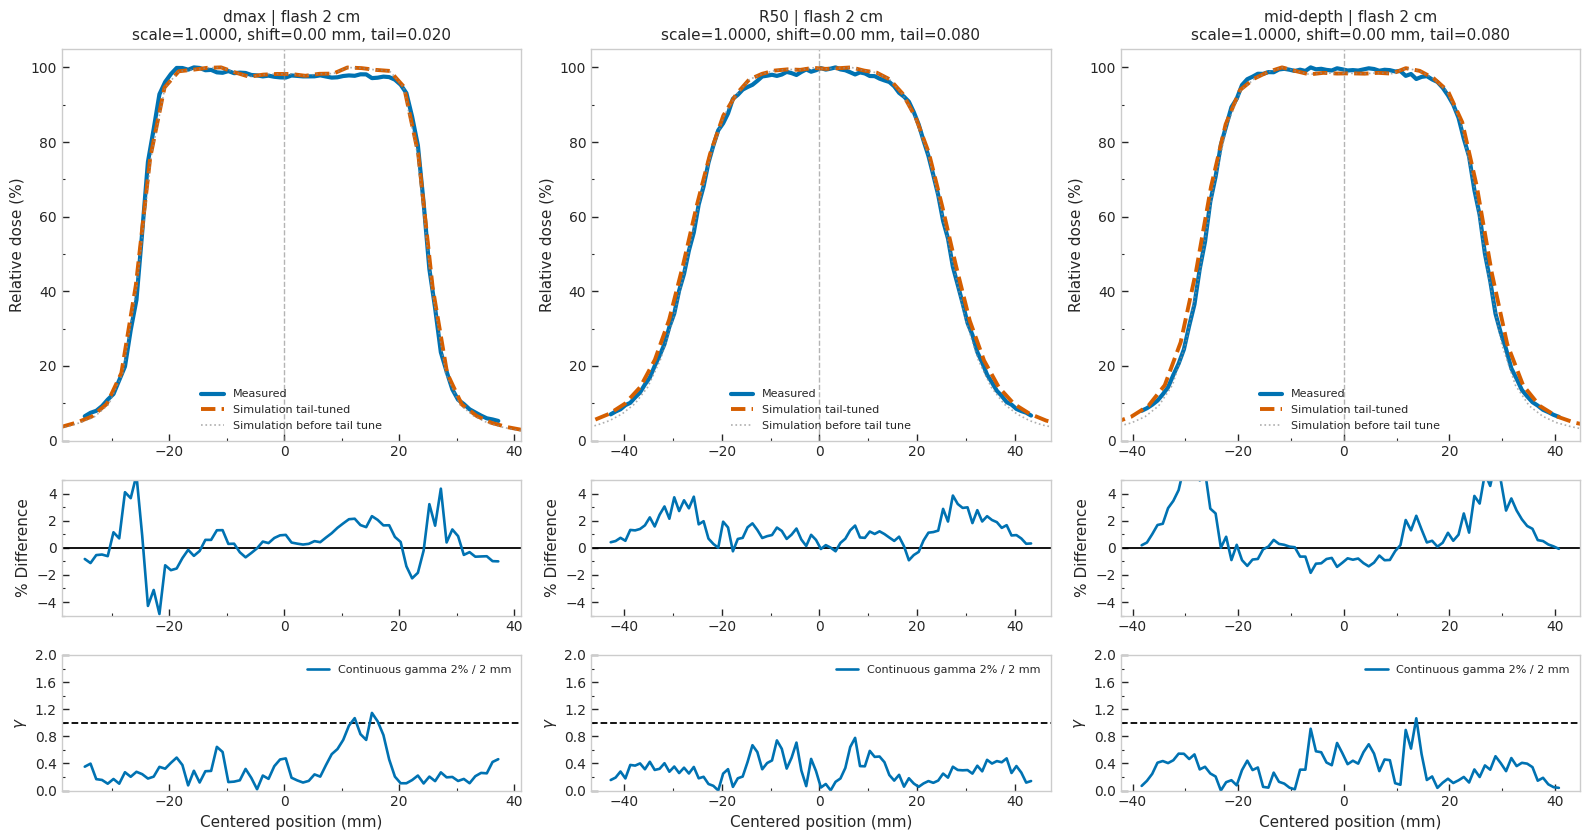

In [17]:
# ============================================================
# CONTINUOUS GAMMA + MANUAL TAIL FINE-TUNING CELL
# ------------------------------------------------------------
# Use this cell when:
#   - profile is already close
#   - gamma is too jumpy/sensitive
#   - simulation tails need small x-axis fine tuning
#
# This cell:
#   - does NOT need manual_tuned_results
#   - uses edge_results / final_clean_results / final_results if available
#   - keeps measured dose unchanged
#   - keeps simulation dose unchanged
#   - changes ONLY simulation x positions
#   - allows tail-only stretch/compression
#   - computes:
#       Depth, RMSE, MAE, MaxAbs, Gamma Pass, Gamma Mean, Gamma Max
#   - removes grid lines
#   - keeps measured x-range visible
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

# ------------------------------------------------------------
# Pick input source automatically
# ------------------------------------------------------------
if "manual_tuned_results" in globals():
    source_results = manual_tuned_results
    source_kind = "manual_tuned_results"
elif "final_clean_results" in globals():
    source_results = final_clean_results
    source_kind = "final_clean_results"
elif "edge_results" in globals():
    source_results = edge_results
    source_kind = "edge_results"
elif "final_results" in globals():
    source_results = final_results
    source_kind = "final_results"
else:
    raise RuntimeError(
        "No usable results found. Run your edge-alignment / profile-building cell first. "
        "Need one of: manual_tuned_results, final_clean_results, edge_results, final_results."
    )

print(f"Using source: {source_kind}")

# ------------------------------------------------------------
# USER CONTROLS
# ------------------------------------------------------------
save_fig_tail_gamma = True
save_dir = Path("build")
save_name_tail_gamma = (
    f"tail_tuned_continuous_gamma_"
    f"{lateral_mode_select}_{lateral_applicator_select_cm}cm.png"
)

save_metrics_excel = True
metrics_excel_name = (
    f"tail_tuned_metrics_"
    f"{lateral_mode_select}_{lateral_applicator_select_cm}cm.xlsx"
)

depth_keys = list(lateral_profile_depth_keys)

# ------------------------------------------------------------
# IMPORTANT: TAIL FINE-TUNING VALUES
# ------------------------------------------------------------
# x_scale:
#   stretches/compresses the whole simulation profile.
#
# x_shift_mm:
#   shifts simulation left/right.
#
# tail_strength:
#   > 0 stretches tails outward
#   < 0 pulls tails inward
#   0 means no extra tail correction
#
# tail_power:
#   controls how much correction focuses on tails.
#   2.0 = broad correction
#   3.0 = tail-focused
#   4.0 = very tail-focused
#
# For your current plot:
#   - if sim tails fall too early / too narrow: increase tail_strength positive
#   - if sim tails are too wide: use negative tail_strength
#   - if whole field too narrow/wide: change x_scale first
# ------------------------------------------------------------

sim_x_tail_tune = {
    "dmax": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,
        "tail_strength": 0.02,
        "tail_power": 3.0,
    },
    "r50": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,
        "tail_strength": 0.08,
        "tail_power": 3.0,
    },
    "middepth": {
        "x_scale": 1.000,
        "x_shift_mm": 0.0,
        "tail_strength": 0.08,
        "tail_power": 3.0,
    },
}

# ------------------------------------------------------------
# Recommended tuning guide
# ------------------------------------------------------------
# If simulation is too narrow at BOTH sides:
#   increase x_scale to 1.005, 1.010, 1.015
#
# If ONLY the far tails need outward stretching:
#   increase tail_strength to 0.03, 0.05, 0.08
#
# If simulation is too wide:
#   reduce x_scale to 0.995 or use tail_strength = -0.02
#
# If left/right are offset:
#   change x_shift_mm by small values: -1.0, -0.5, +0.5, +1.0
# ------------------------------------------------------------

# ------------------------------------------------------------
# Gamma settings
# ------------------------------------------------------------
gamma_dose_percent = 2.0
gamma_dist_mm = 2.0

# Softer but still commonly understandable exploratory option:
# gamma_dose_percent = 3.0
# gamma_dist_mm = 3.0

gamma_dose_mode = "global"
gamma_summary_dose_threshold_pct = 10.0

gamma_search_radius_mm = 4.0 * gamma_dist_mm
gamma_search_step_mm = 0.10

# Optional: smooth only plotted gamma, not the metric calculation
smooth_gamma_for_display = True
gamma_display_smooth_window_mm = 0.8

# Optional: smooth plotted difference only
smooth_difference_for_display = False
difference_smooth_window_mm = 1.0

# ------------------------------------------------------------
# Plot controls
# ------------------------------------------------------------
x_padding_mm = 4.0
x_padding_fraction = 0.04

profile_ylim = (0, 105)
diff_ylim = (-5, 5)
gamma_ylim = (0, 2.0)

show_original_sim = True

# Remove grid lines
plt.rcParams["axes.grid"] = False

# Style
color_meas = "#0072B2"
color_sim = "#D55E00"
color_raw = "0.55"
color_diff = "#0072B2"
color_gamma = "#0072B2"

lw_meas = 3.0
lw_sim = 2.8
lw_raw = 1.2
lw_secondary = 1.9
lw_ref = 1.3

pretty_names = {
    "dmax": "dmax",
    "r50": "R50",
    "middepth": "mid-depth",
}

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_array_from_result(r, names):
    for name in names:
        if name in r:
            return np.asarray(r[name], dtype=float)
    raise KeyError(f"Could not find any of these keys: {names}")


def interp_safe_tail(x_src, y_src, x_tgt):
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_tgt = np.asarray(x_tgt, dtype=float)

    order = np.argsort(x_src)
    x_src = x_src[order]
    y_src = y_src[order]

    y = np.interp(x_tgt, x_src, y_src)
    y[(x_tgt < np.nanmin(x_src)) | (x_tgt > np.nanmax(x_src))] = np.nan

    return y


def moving_average_reflect_tail(y, win_pts):
    y = np.asarray(y, dtype=float)

    if win_pts <= 1 or len(y) < 3:
        return y.copy()

    win_pts = int(win_pts)

    if win_pts % 2 == 0:
        win_pts += 1

    pad = win_pts // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")
    kernel = np.ones(win_pts) / win_pts

    return np.convolve(ypad, kernel, mode="valid")


def smooth_by_mm_tail(x, y, window_mm):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if window_mm is None or window_mm <= 0 or len(x) < 3:
        return x.copy(), y.copy()

    dx = np.nanmedian(np.diff(np.sort(x)))

    if not np.isfinite(dx) or dx <= 0:
        return x.copy(), y.copy()

    win_pts = max(1, int(round(window_mm / dx)))

    return x.copy(), moving_average_reflect_tail(y, win_pts)


def get_xlim_tail(meas_x, pad_mm=4.0, pad_frac=0.04):
    meas_x = np.asarray(meas_x, dtype=float)
    meas_x = meas_x[np.isfinite(meas_x)]

    xmin = float(np.nanmin(meas_x))
    xmax = float(np.nanmax(meas_x))
    width = xmax - xmin

    pad = max(pad_mm, pad_frac * width)

    return xmin - pad, xmax + pad


def apply_tail_x_tune(sim_x, meas_x, tune):
    """
    Apply x-scale, x-shift, and tail-focused symmetric stretch/compression.
    Dose values are not changed.
    """
    sim_x = np.asarray(sim_x, dtype=float)
    meas_x = np.asarray(meas_x, dtype=float)

    x_scale = float(tune.get("x_scale", 1.0))
    x_shift = float(tune.get("x_shift_mm", 0.0))
    tail_strength = float(tune.get("tail_strength", 0.0))
    tail_power = float(tune.get("tail_power", 3.0))

    x = x_scale * sim_x + x_shift

    finite_meas = meas_x[np.isfinite(meas_x)]
    if len(finite_meas) < 2:
        return x

    half_width = 0.5 * (np.nanmax(finite_meas) - np.nanmin(finite_meas))

    if not np.isfinite(half_width) or half_width <= 0:
        return x

    u = np.abs(x) / half_width
    u = np.clip(u, 0.0, 2.0)

    tail_factor = u ** tail_power

    x_tuned = x * (1.0 + tail_strength * tail_factor)

    return x_tuned


def continuous_gamma_1d_tail(
    ref_x,
    ref_y,
    eval_x,
    eval_y,
    dose_percent=2.0,
    dist_mm=2.0,
    dose_mode="global",
    search_radius_mm=8.0,
    search_step_mm=0.10,
):
    """
    Continuous/interpolated 1D gamma.

    This is less sensitive than point-to-point gamma because it searches
    continuously around each measured point using interpolated simulation dose.
    """
    ref_x = np.asarray(ref_x, dtype=float)
    ref_y = np.asarray(ref_y, dtype=float)

    eval_x = np.asarray(eval_x, dtype=float)
    eval_y = np.asarray(eval_y, dtype=float)

    order = np.argsort(eval_x)
    eval_x = eval_x[order]
    eval_y = eval_y[order]

    dx_values = np.arange(
        -search_radius_mm,
        search_radius_mm + 0.5 * search_step_mm,
        search_step_mm,
    )

    gamma_vals = np.full_like(ref_x, np.nan, dtype=float)

    for i, (xm, ym) in enumerate(zip(ref_x, ref_y)):
        x_samples = xm + dx_values

        sim_samples = np.interp(x_samples, eval_x, eval_y)
        outside = (x_samples < np.nanmin(eval_x)) | (x_samples > np.nanmax(eval_x))
        sim_samples[outside] = np.nan

        valid = np.isfinite(sim_samples)

        if not np.any(valid):
            continue

        dx = dx_values[valid]
        dy = sim_samples[valid] - ym

        if dose_mode.lower() == "local":
            dose_crit = dose_percent * max(abs(ym), 1e-6) / 100.0
        else:
            dose_crit = dose_percent

        gamma = np.sqrt((dx / dist_mm) ** 2 + (dy / dose_crit) ** 2)

        gamma_vals[i] = np.nanmin(gamma)

    return gamma_vals


def style_axis_tail(ax):
    ax.grid(False)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=5,
        width=1.0,
        labelsize=10,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=2.5,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


# ============================================================
# BUILD TAIL-TUNED RESULTS
# ============================================================

tail_tuned_results = {}
tail_tuned_summary_rows = []

for key in depth_keys:
    if key not in source_results:
        raise KeyError(
            f"Depth key '{key}' not found in {source_kind}. "
            f"Available keys: {list(source_results.keys())}"
        )

    r = source_results[key]

    meas_x = get_array_from_result(r, ["meas_x"])
    meas_y = get_array_from_result(r, ["meas_y"])

    # Accept different possible sim key names
    sim_x_raw = get_array_from_result(
        r,
        ["sim_x_aligned", "sim_x_tuned", "sim_x"],
    )

    sim_y_raw = get_array_from_result(
        r,
        ["sim_y_tuned", "sim_y", "sim_y_aligned"],
    )

    # Sort measured
    mo = np.argsort(meas_x)
    meas_x = meas_x[mo]
    meas_y = meas_y[mo]

    # Sort raw sim
    so = np.argsort(sim_x_raw)
    sim_x_raw = sim_x_raw[so]
    sim_y_raw = sim_y_raw[so]

    tune = sim_x_tail_tune.get(
        key,
        {
            "x_scale": 1.0,
            "x_shift_mm": 0.0,
            "tail_strength": 0.0,
            "tail_power": 3.0,
        },
    )

    sim_x_tuned = apply_tail_x_tune(
        sim_x=sim_x_raw,
        meas_x=meas_x,
        tune=tune,
    )

    sim_y_tuned = sim_y_raw.copy()

    # Sort tuned simulation
    tso = np.argsort(sim_x_tuned)
    sim_x_tuned = sim_x_tuned[tso]
    sim_y_tuned = sim_y_tuned[tso]

    # Interpolate tuned sim onto measured grid
    sim_on_meas = interp_safe_tail(
        sim_x_tuned,
        sim_y_tuned,
        meas_x,
    )

    comp = pd.DataFrame({
        "x_mm": meas_x,
        "measured_pct": meas_y,
        "sim_pct": sim_on_meas,
    }).dropna()

    comp["diff_pctpts"] = comp["sim_pct"] - comp["measured_pct"]

    gamma_vals = continuous_gamma_1d_tail(
        ref_x=comp["x_mm"].values,
        ref_y=comp["measured_pct"].values,
        eval_x=sim_x_tuned,
        eval_y=sim_y_tuned,
        dose_percent=gamma_dose_percent,
        dist_mm=gamma_dist_mm,
        dose_mode=gamma_dose_mode,
        search_radius_mm=gamma_search_radius_mm,
        search_step_mm=gamma_search_step_mm,
    )

    # Display smoothing only
    diff_x_plot = comp["x_mm"].values.copy()
    diff_y_plot = comp["diff_pctpts"].values.copy()

    if smooth_difference_for_display:
        diff_x_plot, diff_y_plot = smooth_by_mm_tail(
            diff_x_plot,
            diff_y_plot,
            difference_smooth_window_mm,
        )

    gamma_x_plot = comp["x_mm"].values.copy()
    gamma_y_plot = gamma_vals.copy()

    if smooth_gamma_for_display:
        gamma_x_plot, gamma_y_plot = smooth_by_mm_tail(
            gamma_x_plot,
            gamma_y_plot,
            gamma_display_smooth_window_mm,
        )

    # Metrics threshold
    mask = comp["measured_pct"].values >= gamma_summary_dose_threshold_pct
    gamma_mask = mask & np.isfinite(gamma_vals)

    if np.any(mask):
        rmse = float(np.sqrt(np.mean(comp["diff_pctpts"].values[mask] ** 2)))
        mae = float(np.mean(np.abs(comp["diff_pctpts"].values[mask])))
        maxabs = float(np.max(np.abs(comp["diff_pctpts"].values[mask])))
    else:
        rmse = np.nan
        mae = np.nan
        maxabs = np.nan

    if np.any(gamma_mask):
        gamma_pass = float(100.0 * np.mean(gamma_vals[gamma_mask] <= 1.0))
        gamma_mean = float(np.nanmean(gamma_vals[gamma_mask]))
        gamma_max = float(np.nanmax(gamma_vals[gamma_mask]))
    else:
        gamma_pass = np.nan
        gamma_mean = np.nan
        gamma_max = np.nan

    tail_tuned_results[key] = {
        "meas_x": meas_x,
        "meas_y": meas_y,
        "sim_x_raw": sim_x_raw,
        "sim_y_raw": sim_y_raw,
        "sim_x": sim_x_tuned,
        "sim_y": sim_y_tuned,
        "comp": comp,
        "diff_x_plot": diff_x_plot,
        "diff_y_plot": diff_y_plot,
        "gamma_x_plot": gamma_x_plot,
        "gamma_y_plot": gamma_y_plot,
        "gamma_raw": gamma_vals,
        "tune": tune,
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    }

    tail_tuned_summary_rows.append({
        "Depth": key,
        "x_scale": tune["x_scale"],
        "x_shift_mm": tune["x_shift_mm"],
        "tail_strength": tune["tail_strength"],
        "tail_power": tune["tail_power"],
        "RMSE": rmse,
        "MAE": mae,
        "MaxAbs": maxabs,
        "Gamma Pass": gamma_pass,
        "Gamma Mean": gamma_mean,
        "Gamma Max": gamma_max,
    })

tail_tuned_metrics_df = pd.DataFrame(tail_tuned_summary_rows)

print("Tail-tuned continuous gamma metrics:")
display(tail_tuned_metrics_df.round(4))

if save_metrics_excel:
    save_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = save_dir / metrics_excel_name
    tail_tuned_metrics_df.to_excel(metrics_path, index=False)
    print(f"Saved metrics: {metrics_path}")


# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(
    3,
    len(depth_keys),
    figsize=(16, 8.5),
    sharex=False,
    gridspec_kw={"height_ratios": [2.6, 0.9, 0.9]},
)

fig.subplots_adjust(wspace=0.25, hspace=0.12)

if len(depth_keys) == 1:
    axes = np.asarray(axes).reshape(3, 1)

for col, key in enumerate(depth_keys):
    r = tail_tuned_results[key]

    ax_top = axes[0, col]
    ax_mid = axes[1, col]
    ax_bot = axes[2, col]

    xmin, xmax = get_xlim_tail(
        r["meas_x"],
        pad_mm=x_padding_mm,
        pad_frac=x_padding_fraction,
    )

    # -------------------------
    # Top: profile
    # -------------------------
    ax_top.plot(
        r["meas_x"],
        r["meas_y"],
        "-",
        lw=lw_meas,
        color=color_meas,
        label="Measured",
    )

    ax_top.plot(
        r["sim_x"],
        r["sim_y"],
        "--",
        lw=lw_sim,
        color=color_sim,
        label="Simulation tail-tuned",
    )

    if show_original_sim:
        ax_top.plot(
            r["sim_x_raw"],
            r["sim_y_raw"],
            ":",
            lw=lw_raw,
            color=color_raw,
            alpha=0.7,
            label="Simulation before tail tune",
        )

    ax_top.axvline(0, color="0.55", lw=1.0, ls="--", alpha=0.65)

    t = r["tune"]
    ax_top.set_title(
        f"{pretty_names.get(key, key)} | {lateral_mode_select} {lateral_applicator_select_cm} cm\n"
        f"scale={t['x_scale']:.4f}, shift={t['x_shift_mm']:.2f} mm, "
        f"tail={t['tail_strength']:.3f}",
        fontsize=11,
    )

    ax_top.set_ylabel("Relative dose (%)", fontsize=11)
    ax_top.set_xlim(xmin, xmax)
    ax_top.set_ylim(*profile_ylim)
    ax_top.legend(frameon=False, fontsize=8, loc="best")
    style_axis_tail(ax_top)
    ax_top.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # -------------------------
    # Middle: difference
    # -------------------------
    ax_mid.axhline(0, color="black", lw=lw_ref)

    ax_mid.plot(
        r["diff_x_plot"],
        r["diff_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_diff,
    )

    ax_mid.set_ylabel("% Difference", fontsize=11)
    ax_mid.set_xlim(xmin, xmax)
    ax_mid.set_ylim(*diff_ylim)
    style_axis_tail(ax_mid)
    ax_mid.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # -------------------------
    # Bottom: gamma
    # -------------------------
    ax_bot.axhline(1.0, color="black", lw=lw_ref, ls="--")

    ax_bot.plot(
        r["gamma_x_plot"],
        r["gamma_y_plot"],
        "-",
        lw=lw_secondary,
        color=color_gamma,
        label=f"Continuous gamma {gamma_dose_percent:g}% / {gamma_dist_mm:g} mm",
    )

    ax_bot.set_xlabel("Centered position (mm)", fontsize=11)
    ax_bot.set_ylabel(r"$\gamma$", fontsize=11)
    ax_bot.set_xlim(xmin, xmax)
    ax_bot.set_ylim(*gamma_ylim)
    ax_bot.legend(frameon=False, fontsize=8, loc="best")
    style_axis_tail(ax_bot)
    ax_bot.yaxis.set_major_locator(MaxNLocator(nbins=5))

plt.tight_layout()

if save_fig_tail_gamma:
    save_dir.mkdir(parents=True, exist_ok=True)
    outpath = save_dir / save_name_tail_gamma

    fig.savefig(
        outpath,
        dpi=600,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="none",
    )

    print(f"Saved tail-tuned continuous-gamma figure: {outpath}")

plt.show()